# BA510 Final Project Phase 2:  Applying Cross Validation and Comparing against Pre-Trained Models.

By Elmir Shabayev



##Problem Substantiation

Platform companies have one of the most robust business models because of network effects, where an additional user brings in more value for other platform users. The benefit of this is that platform businesses do not have to work to satisfy every transaction that occurs on the platform, e.g., if someone buys something on eBay and is not satisfied with the quality of the product, they are more likely to blame the specific seller than the entire platform. Moreover, if a platform gains a significant amount of users, it can continue to make profits even with few updates, such as the case with Craigslist.

VC firms receive hundreds of pitches from startups and are pressured by limited partners to perform; otherwise, they would lose their capital. In most cases, they invest in many startups fully expecting most of them to fail, with one huge success being able to cover all of the losses. Moreover, it takes time before startups succeed, anywhere between 5 and 10 years. Considering the huge strength of the platform business model, VCs are interested in a way to help predict success in platform startups and receive some certainty about their long-term investment.

Consequently, this neural network model can help VC firms better predict which platforms are likely to succeed, which would save time but can also help in more efficiently spending investment capital.


##Project Goal


To predict whether a platform-based startup would succeed or not. Here, success would be if they had an exit(IPO or Acquisition) and failure would be if the startup failed or if the stayed private. The reason for why Private startups being a failure is that VC firms can not easily liquidate their stock if the company stays private, so it would not be considered a direct success for them.

##Notebook Description

In Phase 1, I evaluated many different models and different ways of datasets(i.e. Wayback Machine, with Company Logos etc.). At the end, the best performing models were QKV Attention for Binary(1 for success, 0 for failure), and Bi-Lstm for multiclass(IPO, Acquired, Failure) using the ChatGPT dataset. I chose one for binary and multiclass, because a VC firm may sometimes prioritize having companies be acquired or go through IPO while in other cases they may only care about a succesful exit.


---




In this Phase, I take those two models, and apply Cross-validation to see if I can improve their results through manipulating the architecture. Moreover, I bring in pre-existing embedings and run cross validation on them as well to see if creating embedings for my dataset from scratch is actually more useful than the pre-trained embedings.

## Importing The Necessary Libraries

In [ ]:
#Needed to apply some of the pre-trained embeddings.
!pip install -U huggingface_hub
# IMPORTANT: Restart your runtime after running this cell!

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 646.8/646.8 kB 11.2 MB/s eta 0:00:00
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.10.1
    Uninstalling huggingface_hub-1.10.1:
      Successfully uninstalled huggingface_hub-1.10.1


In [ ]:
#Import the necesary libraries.
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
from google.colab import drive,files
import plotly.express as px
from geopy.geocoders import Nominatim
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from tensorflow.keras import layers
import plotly.express as px
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

#Mount Google Drive so we can access the
#dataset CSV stored there.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Loading the ChatGPT Dataset

In [ ]:
#Upload the ChatGPT dataset.
chatgpt_startup_df = pd.read_csv('/content/drive/MyDrive/Spring 2026/BA510/Project/The Chatgpt Dataset/startup_dataset_fully_autofilled.csv')

## Exploratory Data Analysis

###Visuals of the Data

Beginning with bar charts, The most common type of platform startup is named Platform, followed by Information and Marketplace. The first one's name is not descriptive enough because all of the companies in the dataset, should be platforms. This could be due to the companies being "in-the-middle" and not precisely neatly fitting into one category. Information is second and altough it may have sites like Wikipedia which could be used often, it intuitively does not make sense that people would be on that type of site rather than a social network, like Instagram. Again, this could be that the Platform over generalized what it does and did not fit into a category neatly. Finally Marketplace can make sense because people could be trying to replicate Amazon's popularity. Moreover, because you purchase and buy goods on Amazon, people may have some bias that makes more money than a social network like Facebook or others(which rely on advertising revenue).


The next chart shows seller type(i.e. is the platform b2b, b2c, etc.). Unsurprisingly, most of the companies are b2c, which makes sense because every day people are consumers, so more ideas would be created for adressing consumer facing problems.


The final chart shows if the startup had a successful exit or not. Based on it, most of the companies got acquired, a lot of them closed, and only some gone through an IPO. This also makes sense beause startups may not have sufficient resources to go through an IPO or the acquisition offers are so favorable to founders that they decide to sell off the company(https://www.svb.com/startup-insights/startup-strategy/types-startup-exit-strategy/).

<Figure size 1800x1500 with 0 Axes>

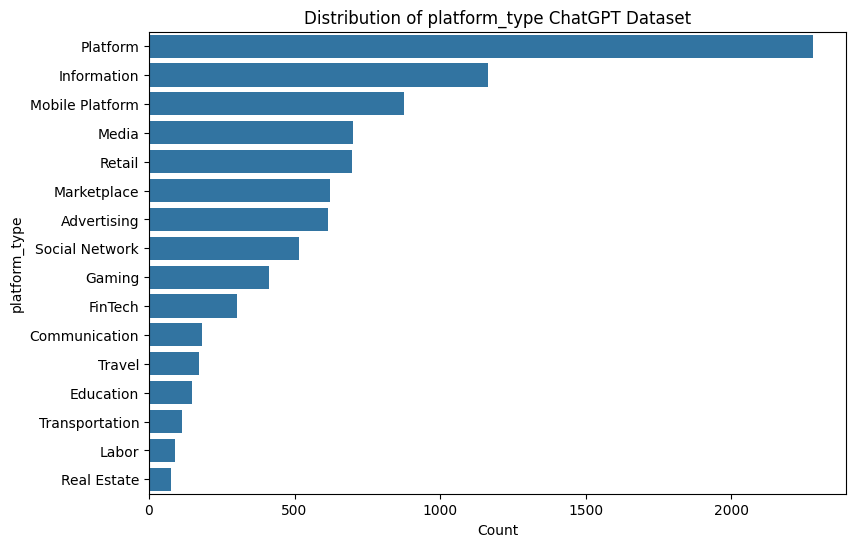

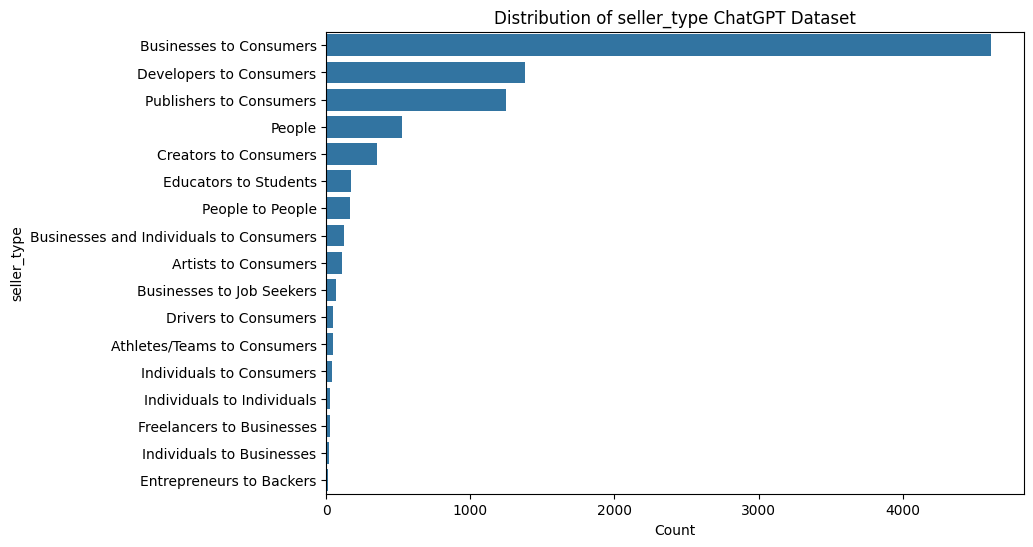

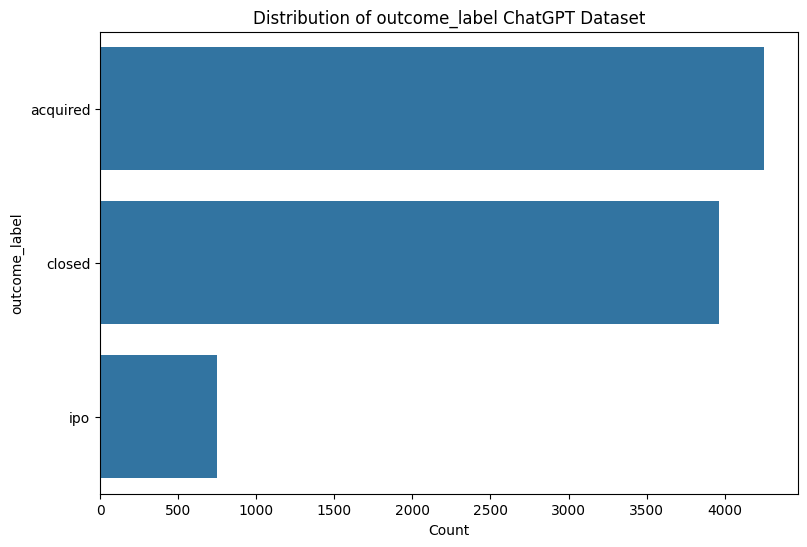

In [ ]:
#Create a list of the categorical columns we want to make bar charts for.
categorical_cols = ['platform_type', 'seller_type', 'outcome_label']

#Initialize a big plt figure for the
#bar charts.
plt.figure(figsize=(18, 15))


#Loop through each cateogircal column and create
#a bar chart showing the distribution of the column.
for col in categorical_cols:

    #Initialize a smaller figure for each visual.
    plt.figure(figsize=(9, 6))

    #Plot the column information.
    sns.countplot(data=chatgpt_startup_df, y=col,
                  order=chatgpt_startup_df[col].value_counts().index)

    #Define the title, labels, and show the plot.
    plt.title(f'Distribution of {col} ChatGPT Dataset')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.show()

The next couple of graphs showcase geograhic distributions of the data. Unsurprisingly, the US has the most number of startups, possibly due to the entrepreneurship culture and more opportunities. Suprisingly, most of the startup's cities are unkown which could be due to the limitations in the data collection process, but from the known ones San Francisco California has the most number of platform startups.

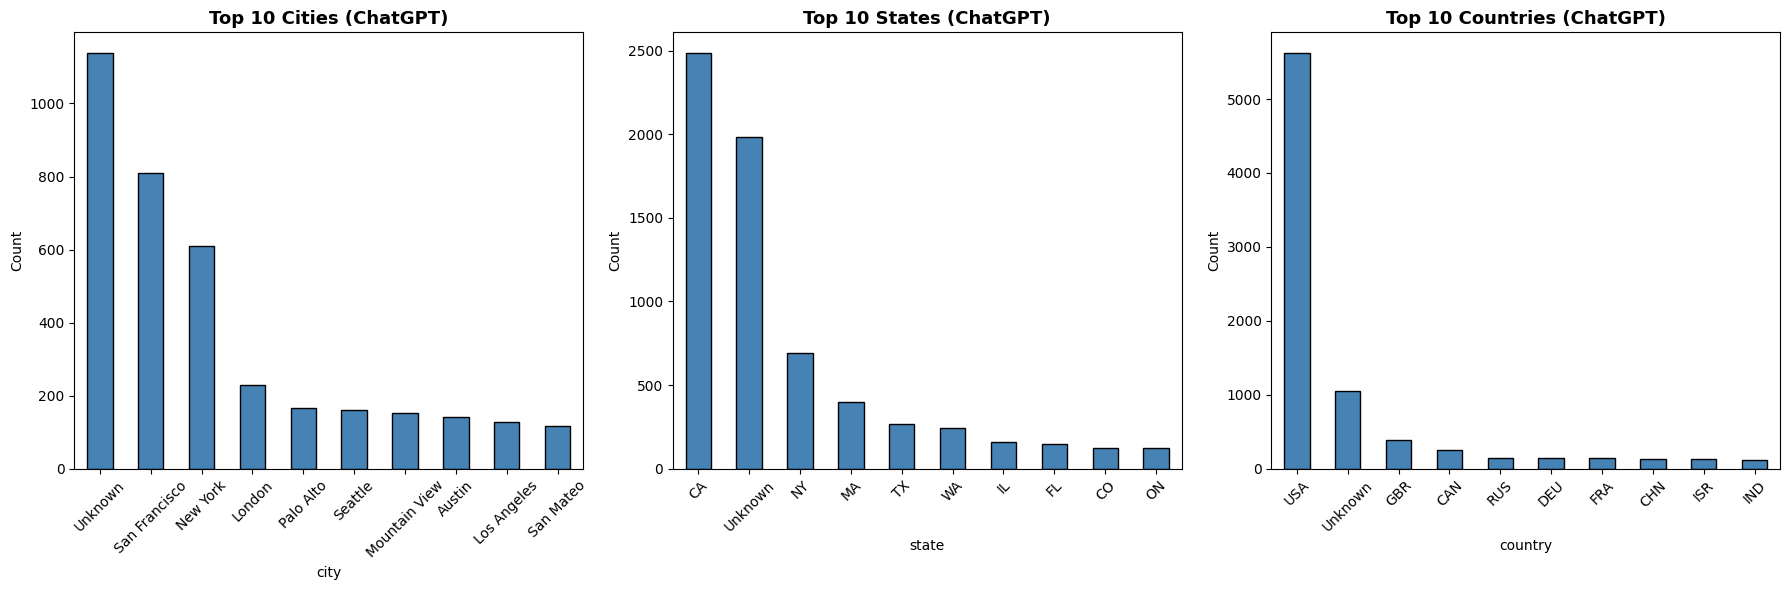

In [ ]:
#Creating visuals to represent the geographic columns of
#the dataset.

#Define a function which we could reause to plot our
#georgaphic categorical columns onto a plot.
def plot_top10_bar(df, col, ax, title):

    #Take the top 10 most frequent values in the
    #column.
    top10 = df[col].value_counts().nlargest(10).index

    #Define a variable to store the values.
    series = df[col].where(df[col].isin(top10))

    #Count the vlaues.
    counts = series.value_counts()

    #Plot the bar chart.
    counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')

    #Set the title, labels, and tick the x axis for readability.
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

#Create subplots so we can see all the plot side by side.
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

#Call our function to plot all of our cateogircal columns.
plot_top10_bar(chatgpt_startup_df, 'city', axes[0], 'Top 10 Cities (ChatGPT)')
plot_top10_bar(chatgpt_startup_df, 'state', axes[1], 'Top 10 States (ChatGPT)')
plot_top10_bar(chatgpt_startup_df, 'country', axes[2], 'Top 10 Countries (ChatGPT)')

#Tight layout to prevent overflow between the visuals and
#show the plots.
plt.tight_layout()
plt.show()

In [ ]:
#Create a choropleth map to show the startups in each country.

#Variable to count how many startups are in each country.
country_counts = chatgpt_startup_df['country'].value_counts().reset_index()

#Display the resulting table
display(country_counts.head())

#Filter only for companies that have known countries.
country_counts_filtered = country_counts[country_counts['country'] != 'Unknown']

#Create the choropleth map.
fig = px.choropleth(
    country_counts_filtered,
    locations='country',
    color='count',
    title='Global Distribution of Platform Startups (ChatGPT Dataset)',
    color_continuous_scale='Viridis',
    labels={'count': 'Number of Startups'}
)

#Show the figure.
fig.show()

,country,count
0,USA,5621
1,Unknown,1045
2,GBR,388
3,CAN,248
4,RUS,146


In [ ]:
#Create a choropleth map showing how many startups are in each US state.

#Filter for only us startups and known states.
us_startups = chatgpt_startup_df[(chatgpt_startup_df['country'] == 'USA')  \
                  & (chatgpt_startup_df['state'] != 'Unknown')]


#Count how many startups were for each state.
state_counts = us_startups['state'].value_counts().reset_index()

#Display the table.
display(state_counts.head())

#Create the chropleth map.
fig_us = px.choropleth(
    state_counts,
    locations='state',
    locationmode='USA-states',
    color='count',
    scope='usa',
    title='Distribution of Platform Startups Across US States (ChatGPT Dataset)',
    color_continuous_scale='Viridis',
    labels={'count': 'Number of Startups'}
)

#Show the figure.
fig_us.show()

,state,count
0,CA,2486
1,NY,693
2,MA,396
3,TX,267
4,WA,242


In [ ]:
#Create a choropleth map for startups in California.

#Filter for startups that are specifically in California.
ca_startups = us_startups[us_startups['state'] == 'CA']


#Create a counts dataframe for keeping track
#of each city and their corresponding
#number of startups.
ca_city_counts = ca_startups['city'] \
                      .value_counts() \
                      .reset_index()

#Define the columns of the dataset, and
#show the output.
ca_city_counts.columns = ['city', 'count']
display(ca_city_counts.head())

#Make some space for the other outputs.
print('\n')



#Convert the city names into lattitude and longitude
#coordinates so we can visualize them.


# Initialize Nominatim geolocator
geolocator = Nominatim(user_agent='startup_mapper')

# Helper function to geocode cities
def geocode_city(city_name):
    try:
        #Forces the search query to be only in California.
        query = f"{city_name}, California, USA"

        #Send the request to geolocator, to get latitude,
        #and longitude.
        location = geolocator.geocode(query, timeout=10)

        # Add delay to avoid rate limiting
        time.sleep(1)

        #If the location is found, we return
        #the latitude and longitude.
        if location:
            return location.latitude, location.longitude

        #If it does not find anything, return none.
        else:
            return None, None

    #Prevent the script from crashing if an exception
    #is thrown.
    except Exception as e:
        print(f"Error geocoding {city_name}: {e}")
        return None, None


# Create new latitude and longitude columns by using
#the newly created function.
ca_city_counts['latitude'], ca_city_counts['longitude'] =  \
              zip(*ca_city_counts['city'] \
              .apply(geocode_city))


# Display the first few rows to verify.
display(ca_city_counts.head())
print('\n')




# Drop rows with missing coordinates just in case
ca_city_counts_mapped = ca_city_counts.dropna(
                          subset=['latitude', 'longitude'])

#Makes each city in CA a dot on the map.
fig_ca = px.scatter_mapbox(
    #Input our dataset.
    ca_city_counts_mapped,

    #Where to place each point.
    lat='latitude',
    lon='longitude',

    #Adjust bubble size.
    size='count',
    color='count',

    #Information to show when
    #hovering over a point on the
    #map.
    hover_name='city',
    hover_data={'latitude': False,
                'longitude': False,
                'count': True},

    #Set the color-gradient,based on
    #number of startups.
    color_continuous_scale='Viridis',

    #Maximum size for hte dots.
    size_max=30,

    #Zoom in the map.
    zoom=5,

    #Center the map on California.
    center={'lat': 36.7783,
            'lon': -119.4179},

    #Adjust the style of the map.
    mapbox_style='carto-positron',

    #Add the title of the dataset.
    title='Distribution of Startups Across California Cities'
)

#Show the figure.
fig_ca.show()

,city,count
0,San Francisco,809
1,Palo Alto,165
2,Mountain View,153
3,Los Angeles,128
4,San Mateo,117


,city,count,latitude,longitude
0,San Francisco,809,37.787936,-122.407520
1,Palo Alto,165,37.444329,-122.159847
2,Mountain View,153,37.389389,-122.083210
3,Los Angeles,128,34.053691,-118.242766
4,San Mateo,117,37.496904,-122.333057


As expected even the Chatgpt dataset has a lot more successful companies that not successful ones due to them being more well-known and their information being easier to retrieve.

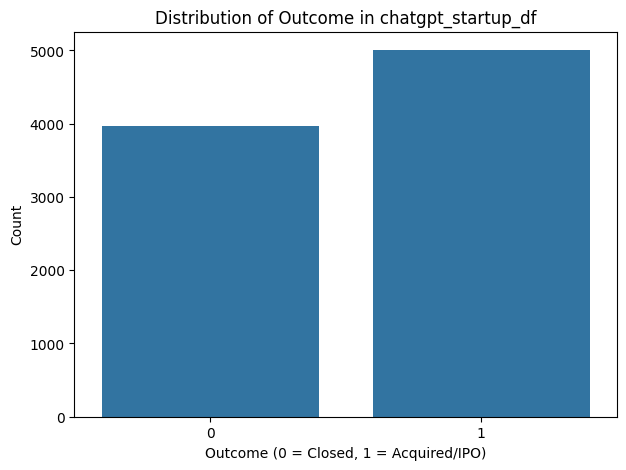

In [ ]:
plt.figure(figsize=(7, 5))
sns.countplot(data=chatgpt_startup_df, x='outcome')
plt.title('Distribution of Outcome in chatgpt_startup_df')
plt.xlabel('Outcome (0 = Closed, 1 = Acquired/IPO)')
plt.ylabel('Count')
plt.show()

###Data Cleaning

For the Data cleaning, I first tried to drop any null values in my textual columns that ChatGPT may have failed to fill out. I then feature engineered a years without vc column, to capture how long the company survived iwthout funding, and dropped the null values in the associated columns. Then for the dummies, I only kept the top 10 most frequent classes in each categorical column and labeled everything else as other.

In [ ]:
#Drop rows with no about_text. Note we define it in a different
#dataframe because we are going to manipulate chatgpt_df and
#do not want it to affect the original dataframe.
chatgpt_df = chatgpt_startup_df.dropna(
    subset=['about_text','founder_background'])


# Feature engineer years_without_vc
chatgpt_df['years_without_vc'] = chatgpt_df['first_funding_year'] - chatgpt_df['founded_year']
chatgpt_df = chatgpt_df.dropna(subset=['years_without_vc', 'founded_year', 'first_funding_year'])


#Show the shape of the dataset, after we drop the null values.
print(f"ChatGPT dataset shape after cleaning: {chatgpt_df.shape}")

ChatGPT dataset shape after cleaning: (6877, 20)


In [ ]:
#Do One hot encoding for categorical columns, leaving the top 10 as
#dummy columns while categorizing the rest as Other.

#Define a list of categorical columns.
cols_to_process_cg = ['platform_type', 'seller_type', 'state', 'country', 'city']



#Loop through each column in the list.
for col in cols_to_process_cg:

    #Store the top 10 largest values in each categorical
    #column.
    top_10 = chatgpt_df[col].value_counts().nlargest(10).index

    #Change the respective chatgpt_df column to either feature
    #the top value or the other value.
    chatgpt_df[col] = chatgpt_df[col].apply(
        lambda x: x if x in top_10 else 'Other'
    )

#Create a new dataframe with dumies genegrated,
#after we have transformed the dataset.
chatgpt_df_w_dummies = pd.get_dummies(
    chatgpt_df.drop(columns=['company_name', 'id',
                                     'source', 'text_source'],
                            errors='ignore'),
    columns=cols_to_process_cg,
    drop_first=True
)

#Show the shape of the dataset with dummies.
print(f"Shape with dummies: {chatgpt_df_w_dummies.shape}")

Shape with dummies: (6877, 61)


## Binary

This seciton shows the best binary model from Phase 1, so that the reader does not have to go through that entire document to find it. Note: For the cross-validation, a function will be defined to do the same architecture, and the code below is to just show what was used in Phase 1.

###Splitting the Dataset

Here, I first shuffled the data to avoid any ordering patterns that ChatGPT may have caused, then split my dataset into X_cg and y_cg(note the _cg is to represent that these are the chatgpt splits). I then proceeded to split the data into train, validation, and test. Finally, I extracted my textual columns(about text and founder information) into separate variables because they will be used as separate branch inputs in my nueral network models.

In [ ]:
#Splitting the data into train/val/and test.
from sklearn.model_selection import train_test_split

#The code below shuffles the dataset.
chatgpt_df_w_dummies = chatgpt_df_w_dummies \
                         .sample(frac=1, random_state=42) \
                         .reset_index(drop=True)

#Define X y with the _cg representing that they are using the chatpgt,
#dataset.
X_cg = chatgpt_df_w_dummies.drop(['outcome', 'outcome_label'], axis=1)
y_cg = chatgpt_df_w_dummies['outcome']

#Split it to  temprorary x and y(which will beused to further
#split to train and validation) and test x and y.
X_cg_temp, X_cg_test, y_cg_temp, y_cg_test = train_test_split(
    X_cg, y_cg, test_size=0.2, random_state=42, stratify=y_cg
)

#Split the dataset to train and validation from the temporary
#x and y.
X_cg_train, X_cg_val, y_cg_train, y_cg_val = train_test_split(
    X_cg_temp, y_cg_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_cg_temp
)

#Separate about text from the structured columns.
X_cg_train_about = X_cg_train['about_text']
X_cg_val_about  = X_cg_val['about_text']
X_cg_test_about = X_cg_test['about_text']

#Separate the founder text from the structured columns.
X_cg_train_founder = X_cg_train['founder_background']
X_cg_val_founder  = X_cg_val['founder_background']
X_cg_test_founder = X_cg_test['founder_background']

#Remove the about text and founder_background columns from the datasets.
X_cg_train_structured = X_cg_train.drop(['about_text','founder_background'], axis=1).astype(float)
X_cg_val_structured   = X_cg_val.drop(['about_text','founder_background'], axis=1).astype(float)
X_cg_test_structured  = X_cg_test.drop(['about_text','founder_background'], axis=1).astype(float)

#Show how many observations are in each dataset.
print(f"Train: {len(y_cg_train)} | Val: {len(y_cg_val)} | Test: {len(y_cg_test)}")

Train: 4125 | Val: 1376 | Test: 1376


### Dummy Classifier Binary

In this section, I checked how well the majority rule would apply to the ChatGPT dataset, and it yielded an accuracy of 56.76%.

In [ ]:
#Determine the most common class in y_cg_train
majority_class_cg = y_cg_train.value_counts().idxmax()
print(f"Majority Class in y_cg_train: {majority_class_cg}")

#Predict all classes in y_cg_test as that most common class
y_pred_dummy_cg = np.full(shape=y_cg_test.shape, fill_value=majority_class_cg)

#Calculate its accuracy
majority_class_proportion_cg = accuracy_score(y_cg_test, y_pred_dummy_cg)
print(f"Dummy Classifier (ChatGPT) Accuracy: {majority_class_proportion_cg:.4f}")

Majority Class in y_cg_train: 1
Dummy Classifier (ChatGPT) Accuracy: 0.5676


### QKV Attention-Binary Model
Three-branch model (about text, founder background, structured)
using self-attention (QKV) for the two text branches.
This was the best-performing binary model on the ChatGPT dataset.

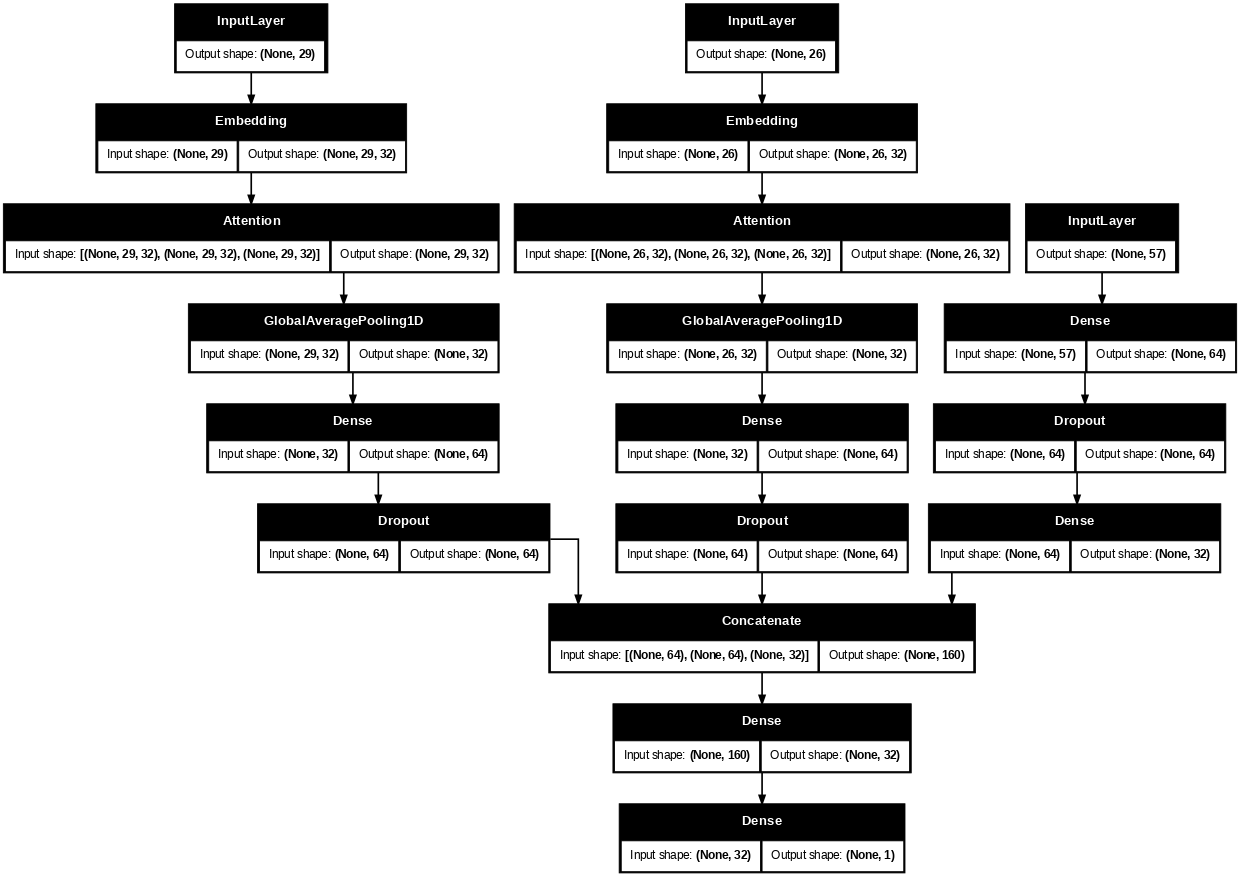

In [ ]:
#Get the text length, and define the maximum length to be used by our network.
about_lengths   = X_cg_train_about.str.split().str.len()
founder_lengths = X_cg_train_founder.str.split().str.len()
max_len_about   = int(about_lengths.quantile(0.95))
max_len_founder = int(founder_lengths.quantile(0.95))

#Define the structured columns input size to be used.
n_structured_cg = X_cg_train_structured.shape[1]

# Separate vectorizers for each text column
text_vec_about_qkv = keras.layers.TextVectorization(
    output_mode="int",
    max_tokens=20_000,
    output_sequence_length=max_len_about
)
text_vec_about_qkv.adapt(X_cg_train_about.values)

text_vec_founder_qkv = keras.layers.TextVectorization(
    output_mode="int",
    max_tokens=20_000,
    output_sequence_length=max_len_founder
)
text_vec_founder_qkv.adapt(X_cg_train_founder.values)

#Vectorize all splits
X_cg_train_about_qkv   = text_vec_about_qkv(X_cg_train_about.values)
X_cg_val_about_qkv     = text_vec_about_qkv(X_cg_val_about.values)
X_cg_test_about_qkv    = text_vec_about_qkv(X_cg_test_about.values)

X_cg_train_founder_qkv = text_vec_founder_qkv(X_cg_train_founder.values)
X_cg_val_founder_qkv   = text_vec_founder_qkv(X_cg_val_founder.values)
X_cg_test_founder_qkv  = text_vec_founder_qkv(X_cg_test_founder.values)

VOCAB_SIZE_CG = 20_001
EMBED_DIM_CG  = 32

#About text branch
about_input_qkv = keras.Input(shape=(max_len_about,), name="about_input")
about_emb       = layers.Embedding(VOCAB_SIZE_CG, EMBED_DIM_CG,
                                   name="emb_about")(about_input_qkv)
attended_a      = layers.Attention()([about_emb, about_emb, about_emb])
x_a             = layers.GlobalAveragePooling1D()(attended_a)
x_a             = layers.Dense(64, activation="relu")(x_a)
x_a             = layers.Dropout(0.3)(x_a)

#Founder background branch
founder_input_qkv = keras.Input(shape=(max_len_founder,), name="founder_input")
founder_emb       = layers.Embedding(VOCAB_SIZE_CG, EMBED_DIM_CG,
                                     name="emb_founder")(founder_input_qkv)
attended_f        = layers.Attention()([founder_emb, founder_emb, founder_emb])
x_f               = layers.GlobalAveragePooling1D()(attended_f)
x_f               = layers.Dense(64, activation="relu")(x_f)
x_f               = layers.Dropout(0.3)(x_f)

#Structured branch
struct_input_qkv = keras.Input(shape=(n_structured_cg,), name="struct_input")
x_s              = layers.Dense(64, activation="relu")(struct_input_qkv)
x_s              = layers.Dropout(0.3)(x_s)
x_s              = layers.Dense(32, activation="relu")(x_s)

# Merge all three branches
merged_qkv = layers.Concatenate()([x_a, x_f, x_s])
merged_qkv = layers.Dense(32, activation="relu")(merged_qkv)
output_qkv = layers.Dense(1, activation="sigmoid")(merged_qkv)




#Create the model and compile it.
simple_qkv_model_cg = keras.Model(
    inputs=[about_input_qkv, founder_input_qkv, struct_input_qkv],
    outputs=output_qkv
)
simple_qkv_model_cg.compile(optimizer="rmsprop",
                              loss="binary_crossentropy",
                              metrics=["accuracy"])

#Visualize the Model.
keras.utils.plot_model(simple_qkv_model_cg, show_shapes=True, dpi=60)

In [ ]:
#Fit the simple QKV model
history_qkv_cg = simple_qkv_model_cg.fit(
    x=[X_cg_train_about_qkv.numpy(),
       X_cg_train_founder_qkv.numpy(),
       X_cg_train_structured.values.astype("float32")],
    y=y_cg_train.values,
    validation_data=(
        [X_cg_val_about_qkv.numpy(),
         X_cg_val_founder_qkv.numpy(),
         X_cg_val_structured.values.astype("float32")],
        y_cg_val.values
    ),
    epochs=20,
    batch_size=16,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_accuracy",
                                      patience=3,
                                      restore_best_weights=True)
    ]
)


#Evaluate the model's performance on the test set.
test_loss_qkv_cg, test_acc_qkv_cg = simple_qkv_model_cg.evaluate(
    [X_cg_test_about_qkv.numpy(),
     X_cg_test_founder_qkv.numpy(),
     X_cg_test_structured.values.astype("float32")],
    y_cg_test.values
)
print(f"Test Loss:     {test_loss_qkv_cg:.4f}")
print(f"Test Accuracy: {test_acc_qkv_cg:.4f}")

Epoch 1/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 15s 28ms/step - accuracy: 0.5055 - loss: 7.9422 - val_accuracy: 0.4324 - val_loss: 3.2805
Epoch 2/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5001 - loss: 1.9026 - val_accuracy: 0.4564 - val_loss: 0.6979
Epoch 3/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5365 - loss: 0.8546 - val_accuracy: 0.6279 - val_loss: 0.6389
Epoch 4/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6267 - loss: 0.6571 - val_accuracy: 0.6606 - val_loss: 0.6187
Epoch 5/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6645 - loss: 0.6195 - val_accuracy: 0.6882 - val_loss: 0.6057
Epoch 6/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6977 - loss: 0.5861 - val_accuracy: 0.6948 - val_loss: 0.5873
Epoch 7/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7195 - loss: 0.5680 - val_accuracy: 0.6940 - val_loss: 0.5837
Epoch 8/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7215 - loss: 0.5509 - val_accuracy: 

##Multiclass


This seciton shows the best multiclass model from Phase 1, so that the reader does not have to go through that entire document to find it. Note: For the cross-validation, a function will be defined to do the same architecture, and the code below is to just show what was used in Phase 1.

###Splitting the Dataset

We re-split the same ChatGPT dataset using the three-class
outcome label (closed / acquired / IPO) instead of the binary one.
Class weights are computed here to handle IPO class imbalance.

In [ ]:
#Map string labels to integers.
label_map_cg = {'closed': 0, 'acquired': 1, 'ipo': 2}


#Use multiclass labels.
y_cm= chatgpt_df_w_dummies['outcome_label'].map(label_map_cg)

X_cg_temp_cm, X_cg_test_cm, y_cg_temp_cm, y_cg_test_cm = train_test_split(
    X_cg, y_cm, test_size=0.2, random_state=42, stratify=y_cm
)
X_cg_train_cm, X_cg_val_cm, y_cg_train_cm, y_cg_val_cm = train_test_split(
    X_cg_temp_cm, y_cg_temp_cm,
    test_size=0.25, random_state=42, stratify=y_cg_temp_cm
)

#Separate text columns from structured.
X_cg_train_about_cm    = X_cg_train_cm['about_text']
X_cg_val_about_cm      = X_cg_val_cm['about_text']
X_cg_test_about_cm     = X_cg_test_cm['about_text']

X_cg_train_founder_cm  = X_cg_train_cm['founder_background']
X_cg_val_founder_cm    = X_cg_val_cm['founder_background']
X_cg_test_founder_cm   = X_cg_test_cm['founder_background']

X_cg_train_struct_cm   = X_cg_train_cm.drop(['about_text','founder_background'], axis=1).astype(float)
X_cg_val_struct_cm     = X_cg_val_cm.drop(['about_text','founder_background'], axis=1).astype(float)
X_cg_test_struct_cm    = X_cg_test_cm.drop(['about_text','founder_background'], axis=1).astype(float)



#Intialize the weights so that the model is discouraged from just predicting the most
#frequent one and would actually try to predict if it is on eof hte rarer ones.
class_weights_cm     = compute_class_weight('balanced',
                                             classes=np.unique(y_cg_train_cm),
                                             y=y_cg_train_cm)
class_weight_dict_cm = dict(enumerate(class_weights_cm))
print("Class weights (ChatGPT Multiclass):", class_weight_dict_cm)

Class weights (ChatGPT Multiclass): {0: np.float64(0.7711721817162086), 1: np.float64(0.6820436507936508), 2: np.float64(4.217791411042945)}


### Dummy Classifier Multiclass

As before, I applied a majority and random guess dummy clasisfier to set up a benchmark. The Dummy Classifier yielded an accuracy of 48.84%.

In [ ]:
#Check the class distribution in the ChatGPT dataset.
label_counts_cm = y_cm.value_counts().sort_index()
label_names_cm  = {0: 'closed', 1: 'acquired', 2: 'ipo'}


#Fancy output of the class distributions.
print("=== Class Distribution (ChatGPT Multiclass) ===")
for label, count in label_counts_cm.items():
    print(f"  {label_names_cm[label]:>10}: {count:>4} ({count/len(y_cm):.1%})")

#Benchmark 1: Always predict the majority class.
#Determine the most common class in y_cg_train_cm
majority_class_cm = y_cg_train_cm.value_counts().idxmax()
print(f"Majority Class in y_cg_train_cm: {majority_class_cm} ({label_names_cm[majority_class_cm]})")

#Predict all classes in y_cg_test_cm as that most common class
y_pred_dummy_cm = np.full(shape=y_cg_test_cm.shape, fill_value=majority_class_cm)

#Calculate its accuracy
majority_class_acc_cm = accuracy_score(y_cg_test_cm, y_pred_dummy_cm)
print(f"Dummy Classifier (ChatGPT Multiclass) Test Accuracy: {majority_class_acc_cm:.4f}")


#Benchmark 2: Random guessing (1/3 since there are 3 classes).
print(f"Random Guess Benchmark:   {1/3:.4f} ({1/3:.1%})")

=== Class Distribution (ChatGPT Multiclass) ===
      closed: 2973 (43.2%)
    acquired: 3360 (48.9%)
         ipo:  544 (7.9%)
Majority Class in y_cg_train_cm: 1 (acquired)
Dummy Classifier (ChatGPT Multiclass) Test Accuracy: 0.4884
Random Guess Benchmark:   0.3333 (33.3%)


###Bi-LSTM — Multiclass

Three-branch RNN model using a Bidirectional LSTM for both
text branches. This was the best-performing multiclass model
on the ChatGPT dataset.

Note in Phase 1, I used `build_rnn_model_cm()` builder to help cycle through many different RNN architectures. To maintain, the same architecture, I used Bi-LSTM still with this funciton to maintain the same architecture.

In [ ]:
#Define the aggreagte model to be
#used so that we can test out a variety
#RNN architectures.
def build_rnn_model_cm(rnn_layer):
    '''Multiclass three-branch RNN for the ChatGPT dataset.'''


    #Split the text columns to get their length and define
    #the maximum length for the input layers.
    about_lengths_cm   = X_cg_train_about_cm.str.split().str.len()
    founder_lengths_cm = X_cg_train_founder_cm.str.split().str.len()
    max_len_about_cm   = int(about_lengths_cm.quantile(0.95))
    max_len_founder_cm = int(founder_lengths_cm.quantile(0.95))

    #Define the size of the input for the structured branch.
    n_struct_cm = X_cg_train_struct_cm.shape[1]

    #Define the vectorizers for both of our text columns.
    text_vec_about_rnn_cm = keras.layers.TextVectorization(
        max_tokens=20_000, output_mode='int',
        output_sequence_length=max_len_about_cm)
    text_vec_about_rnn_cm.adapt(X_cg_train_about_cm.values)

    text_vec_founder_rnn_cm = keras.layers.TextVectorization(
        max_tokens=20_000, output_mode='int',
        output_sequence_length=max_len_founder_cm)
    text_vec_founder_rnn_cm.adapt(X_cg_train_founder_cm.values)

    #Create a renamed copy of the RNN layer for the founder branch.
    base_name = rnn_layer.name.split("_")[0]
    config = rnn_layer.get_config()
    config['name'] = f"{base_name}_founder_cm"
    founder_rnn_cm = type(rnn_layer).from_config(config)

    if isinstance(rnn_layer, keras.layers.Bidirectional):
        inner_layer  = rnn_layer.forward_layer
        inner_config = inner_layer.get_config()
        inner_config['name'] = f"{inner_layer.name.split('_')[0]}_founder_cm_inner"
        new_inner    = type(inner_layer).from_config(inner_config)
        founder_rnn_cm = keras.layers.Bidirectional(new_inner, name="bidirectional_founder_cm")

    #About text branch.
    about_input_cm = keras.Input(shape=(1,), dtype=tf.string, name="about_input")
    x_a_cm         = text_vec_about_rnn_cm(about_input_cm)
    x_a_cm         = keras.layers.Embedding(20_000, 64, name="emb_about")(x_a_cm)
    x_a_cm         = rnn_layer(x_a_cm)
    x_a_cm         = keras.layers.Dropout(0.3)(x_a_cm)

    #Founder background branch.
    founder_input_cm = keras.Input(shape=(1,), dtype=tf.string, name="founder_input")
    x_f_cm           = text_vec_founder_rnn_cm(founder_input_cm)
    x_f_cm           = keras.layers.Embedding(20_000, 64, name="emb_founder")(x_f_cm)
    x_f_cm           = founder_rnn_cm(x_f_cm)
    x_f_cm           = keras.layers.Dropout(0.3)(x_f_cm)

    #Structured branch.
    struct_input_cm = keras.Input(shape=(n_struct_cm,), name="struct_input")
    x_s_cm          = keras.layers.Dense(32, activation='relu')(struct_input_cm)
    x_s_cm          = keras.layers.Dropout(0.3)(x_s_cm)

    #Merge all three.
    combined_cm = keras.layers.Concatenate()([x_a_cm, x_f_cm, x_s_cm])
    x_cm        = keras.layers.Dense(32, activation='relu')(combined_cm)
    output_cm   = keras.layers.Dense(3, activation='softmax')(x_cm)  # 3 classes


    #Create the RNN model and compile it.
    rnn_model_cm = keras.Model(
        inputs=[about_input_cm, founder_input_cm, struct_input_cm],
        outputs=output_cm
    )
    rnn_model_cm.compile(optimizer='rmsprop',
                          loss='sparse_categorical_crossentropy',
                          metrics=['accuracy'])


    #Return the specific RNN model.
    return rnn_model_cm

In [ ]:
#We only need the Bi-LSTM variant, so we define
#the single layer and training call directly
#rather than looping through all six RNN types.

#Define the Bi-LSTM layer that will be passed
#into the builder function.
bilstm_layer_cm = keras.layers.Bidirectional(
    keras.layers.LSTM(64),
    name='bidirectional'
)

#Build the Bi-LSTM multiclass model using
#the builder function defined above.
model_bilstm_cm = build_rnn_model_cm(bilstm_layer_cm)

#Fit the Bi-LSTM model on the multiclass
#ChatGPT training data. class_weight_dict_cm
#handles IPO class imbalance.
history_bilstm_cm = model_bilstm_cm.fit(
    (X_cg_train_about_cm.values,
     X_cg_train_founder_cm.values,
     X_cg_train_struct_cm.values.astype('float32')),
    y_cg_train_cm.values,
    validation_data=(
        (X_cg_val_about_cm.values,
         X_cg_val_founder_cm.values,
         X_cg_val_struct_cm.values.astype('float32')),
        y_cg_val_cm.values
    ),
    epochs=10,
    batch_size=32,
    class_weight=class_weight_dict_cm
)

#Evaluate the Bi-LSTM on the held-out test set.
test_loss_bilstm_cm, test_acc_bilstm_cm = model_bilstm_cm.evaluate(
    (X_cg_test_about_cm.values,
     X_cg_test_founder_cm.values,
     X_cg_test_struct_cm.values.astype('float32')),
    y_cg_test_cm.values,
    verbose=0
)
print(f'Bi-LSTM Multiclass — Test Accuracy: {test_acc_bilstm_cm:.4f}')
print(f'Bi-LSTM Multiclass — Test Loss:     {test_loss_bilstm_cm:.4f}')

Epoch 1/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.3399 - loss: 17.0369 - val_accuracy: 0.4884 - val_loss: 2.0615
Epoch 2/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.3554 - loss: 4.1217 - val_accuracy: 0.0792 - val_loss: 3.9712
Epoch 3/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.3670 - loss: 2.2537 - val_accuracy: 0.1606 - val_loss: 1.8689
Epoch 4/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.4269 - loss: 1.5171 - val_accuracy: 0.6039 - val_loss: 0.8170
Epoch 5/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4785 - loss: 1.2443 - val_accuracy: 0.5029 - val_loss: 0.9628
Epoch 6/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5025 - loss: 1.1238 - val_accuracy: 0.3815 - val_loss: 1.4330
Epoch 7/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5428 - loss: 0.9344 - val_accuracy: 0.4128 - val_loss: 1.2291
Epoch 8/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.6204 - loss: 0.7811 - val_acc

## Cross Validation Experimentation

This section defines the common function for running cross validatoin, plotting and printing the results for easier readability.


The Cross Validation will search through the follwing Grid:

| Parameter | Values tried |
|---|---|
| Dense hidden units | 32, 64, 128 |
| Number of hidden layers | 1, 2 |
| Dropout rate | 0.2, 0.4 |
| Learning rate | 1e-3, 3e-4 |
| Batch size | 16, 32 |
| Max epochs (with early stopping) | 15 |
| Activation (dense layers) | relu, elu |
| Optimizer | adam, rmsprop, adamw, nadam |



For each configuration we use **5-fold cross-validation** on the combined
train+val data and report mean val accuracy ± std.

Coomon functions/parameters used throughout:

| Name | Purpose |
|---|---|
| `ALL_RESULTS` |  Every model's results stored here, as pair(i.e. ALL_RESULTS['Random Init'] would have both the binary and multiclass results inside.) |
| `run_cv(name, ...)` | Function to run the cross validation |
| `plot_results(name)` | Draw all charts for one model |
| `print_all_results()` | Summary table of all models run so far |







###Cross Validation Common Code

In [ ]:
# Global seed for reproducibility
SEED = 42

# Cross-validation setup
N_FOLDS = 5
MAX_EPOCHS = 15

# Define the hyperparameter search space for random search CV.
# (dense_units, num_layers, dropout_rate, learning_rate, batch_size, activation_function, optimizer_name)
SAMPLED_CONFIGS = [
    (32, 1, 0.2, 0.001, 16, 'relu',  'rmsprop'),
    (64, 1, 0.4, 0.0003, 32, 'elu',  'adam'),
    (32, 2, 0.2, 0.0003, 16, 'elu',  'rmsprop'),
    (64, 2, 0.4, 0.001,  32, 'relu', 'adam'),
    (128, 1, 0.2, 0.001, 16, 'relu', 'adamw'),
    (64,  2, 0.2, 0.0003, 16, 'elu', 'adamw'),
    (32,  1, 0.4, 0.001,  32, 'relu', 'nadam'),
    (128, 2, 0.4, 0.0003, 32, 'elu', 'nadam'),
    (64,  1, 0.2, 0.001,  32, 'elu', 'adamw'),
    (128, 1, 0.4, 0.0003, 16, 'relu', 'adam'),
]

# Helper function to get Keras optimizer instance
def get_optimizer(optimizer_name, learning_rate):

    if optimizer_name == 'rmsprop':
        return keras.optimizers.RMSprop(learning_rate=learning_rate)

    elif optimizer_name == 'adam':
        return keras.optimizers.Adam(learning_rate=learning_rate)

    elif optimizer_name == 'adamw':
        return keras.optimizers.AdamW(
        learning_rate=learning_rate, weight_decay=1e-4)

    elif optimizer_name == 'nadam':
      return keras.optimizers.Nadam(learning_rate=learning_rate)

    else:
        raise ValueError(f"Unknown optimizer: {optimizer_name}")

# Initialize StratifiedKFold for binary and multiclass tasks.

#The Stratified K-Fold for binary.
skf_b = StratifiedKFold(n_splits=N_FOLDS,
                        shuffle=True,
                        random_state=SEED)


#The stratified K-Fold for multiclass.
skf_m = StratifiedKFold(n_splits=N_FOLDS,
                        shuffle=True,
                        random_state=SEED)



#ALL_RESULTS stores every model's CV results
#as a nested dictionary.
#Examppes:
#  ALL_RESULTS['RoBERTa']['binary']['test_acc']
#  ALL_RESULTS['Word2Vec']['multiclass']['cv_df']
#  ALL_RESULTS['FinBERT']['binary']['history']
ALL_RESULTS = {}
print('ALL_RESULTS initialised.')




#The below function automates the cross validation
#process. Note we define the encodings before passing them
#into the function for efficiency(we would be needless
#encoding the model multiple times), and so that
#the only thing that differs is the hyperparameter
#combination and fold rather than the specific emebdings.
def run_cv(name,
           build_fn_b, pool_a_b, pool_f_b, pool_s_b,
                       test_a_b, test_f_b, test_s_b,
                       y_pool_b, y_test_b,
           build_fn_m, pool_a_m, pool_f_m, pool_s_m,
                       test_a_m, test_f_m, test_s_m,
                       y_pool_m, y_test_m,
           cw_dict,
           builder_kwargs_b=None,
           builder_kwargs_m=None):


    '''
    Binary task inputs:
        build_fn_b  : callable — builder that returns
                      a compiled binary Keras model.

        Note:pool means inclduing both train+validation
        splits.

        pool_a_b    : embeddings for about text in
                      binary.
        pool_f_b    : embeddings for founder background
                      in binary.
        pool_s_b    : structured features(N x F)
        y_pool_b    : binary labels



        test_a_b    : embedded about, test set
        test_f_b    : embedded founder, test set
        test_s_b    : structured, test set
        y_test_b    :  binary labels, test

        Multiclass task inputs have the same pattern
        but with _m suffix at the end instead of _b:

        build_fn_m,
        pool_a_m,
        pool_f_m,
        pool_s_m,
        test_a_m,
        test_f_m,
        test_s_m,
        y_pool_m,
        y_test_m

        cw_dict       : dict — class weights for multiclass
                      (compute_class_weight on pool).


        Note: Extra arguments in the below
        are for Word2Vec:

        builder_kwargs_b / builder_kwargs_m : dict


    '''



    #If statemetns to deal with
    #the Wor2Vect specifically.
    if builder_kwargs_b is None:
        builder_kwargs_b = {}
    if builder_kwargs_m is None:
        builder_kwargs_m = {}

    print(f'\n{"="*60}')
    print(f'  run_cv: {name}')
    print(f'{"="*60}')

    #══════════════════════════════════════════
    # BINARY  cross-validation
    #══════════════════════════════════════════


    #Print statement as a diagnostic to make sure
    #that the function is working properly.
    print(f'\n[{name}] Binary CV '
          f'({N_FOLDS} folds x {len(SAMPLED_CONFIGS)} configs)...')

    #Define a list to store the results for the
    #cross validation results for the
    #binary model.
    cv_b = []

    #Loop through each of the hyperparameters defined in sampled configs.
    for cfg_idx, (num_hidden_units, num_layers, drop_out_rate, learning_rate, batch_size, activation_function, optimizer) \
            in enumerate(SAMPLED_CONFIGS):


        #Intialize a list to store our fold accuracies.
        fold_accs = []

        #Enumerate returns an index and a value,
        #so _, skips the index so that we could
        #look at the value(i.e. the training and
        #validation splits). the tr_idx retrieves
        #the index for the training split,
        #and the va_idx retrieves the value for our
        #validation set.
        for _, (tr_idx, va_idx) in enumerate(
                skf_b.split(pool_a_b, y_pool_b)):

            #Build a fresh model for each fold
            #so weights never carry over.
            model = build_fn_b(
                num_hidden_units, num_layers, drop_out_rate, learning_rate, activation_function, optimizer,
                **builder_kwargs_b)

            #Fit the model to the dataset.
            model.fit(
                [pool_a_b[tr_idx],
                 pool_f_b[tr_idx],
                 pool_s_b[tr_idx]],
                y_pool_b[tr_idx],
                validation_data=(
                    [pool_a_b[va_idx],
                     pool_f_b[va_idx],
                     pool_s_b[va_idx]],
                    y_pool_b[va_idx]
                ),
                epochs=MAX_EPOCHS,
                batch_size=batch_size,
                callbacks=[keras.callbacks.EarlyStopping(
                    monitor='val_accuracy',
                    patience=3,
                    restore_best_weights=True)],
                verbose=0
            )

            #Extract the validation accuracy.
            _, va = model.evaluate(
                [pool_a_b[va_idx],
                 pool_f_b[va_idx],
                 pool_s_b[va_idx]],
                y_pool_b[va_idx], verbose=0)

            #Add the validation accuacy to our list.
            fold_accs.append(va)

        #Retrive the meain accuracy and standard
        #devation of accuracy across all the folds.
        mean_acc = float(np.mean(fold_accs))
        std_acc  = float(np.std(fold_accs))

        #Add the respective cross validtaion
        #configuration and accuracy metrics
        #to our binary list.
        cv_b.append({
            'dense_units': num_hidden_units, 'num_layers': num_layers,
            'drop_out_rate': drop_out_rate,    'learning_rate': learning_rate,
            'batch': batch_size,      'activation_function': activation_function,
            'optimizer': optimizer,
            'mean_val_acc': round(mean_acc, 4),
            'std_val_acc':  round(std_acc,  4),
        })


        #Fancy print statement for diagnostics.
        print(f'  [{name}] Config {cfg_idx+1:02d} binary '
              f'-> {mean_acc:.4f} ± {std_acc:.4f}')

    #Turn our list into a DataFrame and
    #sort it by the best mean validation accuracy.
    cv_df_b = (pd.DataFrame(cv_b)
               .sort_values('mean_val_acc', ascending=False)
               .reset_index(drop=True))


    #Retrieve the best model index(because we
    #sorted by descending order, it is the first one
    #in the dataframe).
    best_b  = cv_df_b.iloc[0]

    #Retrain best binary config on full pool.

    #Fancy print statement for diagnositcs.
    print(f'\n[{name}] Retraining best binary config...')

    best_model_b = build_fn_b(
        int(best_b['dense_units']),
        int(best_b['num_layers']),
        float(best_b['drop_out_rate']),
        float(best_b['learning_rate']),
        best_b['activation_function'],
        best_b['optimizer'],
        **builder_kwargs_b)

    #Fit the best model on our full pool.
    hist_b = best_model_b.fit(
        [pool_a_b, pool_f_b, pool_s_b],
        y_pool_b,
        validation_data=(
            [test_a_b, test_f_b, test_s_b],
            y_test_b),
        epochs=MAX_EPOCHS,
        batch_size=int(best_b['batch']),
        callbacks=[keras.callbacks.EarlyStopping(
            monitor='val_accuracy', patience=3,
            restore_best_weights=True)],
        verbose=1
    )

    #Evaluate the model on our
    #test set(note this only
    #gets the accuracy).
    loss_b, acc_b = best_model_b.evaluate(
        [test_a_b, test_f_b, test_s_b],
        y_test_b, verbose=0)

    #Retrieve the model's predictions
    #on the test set so that
    #we could get the confusion
    #matrix later.
    y_pred_b = (
        best_model_b.predict(
            [test_a_b, test_f_b, test_s_b],
            verbose=0) >= 0.5
    ).astype(int).flatten()


    #Fancy print statemetn for diagnositcs.
    print(f'[{name}] Binary Test Acc: {acc_b:.4f}')

    #══════════════════════════════════════════
    # MULTICLASS  cross-validation
    #══════════════════════════════════════════

    #Fancy print statement for diagnostics.
    print(f'\n[{name}] Multiclass CV '
          f'({N_FOLDS} folds x {len(SAMPLED_CONFIGS)} configs)...')

    #Initialize the list that woudl store our
    #multiclass cross validation results.
    cv_m = []

    #Loop through each hyper parameter in our
    #sampled_configs.
    for cfg_idx, (num_hidden_units, num_layers, drop_out_rate, learning_rate, batch_size, activation_function, optimizer) \
            in enumerate(SAMPLED_CONFIGS):

        #Define a list to store our particular
        #hyperparameter combination's
        #accuracy across folds.
        fold_accs = []


        #_, skips the index that comes
        #from the enumerate function.
        #tr_idx and va_idx are training folds
        #and validation folds indcieis respectively.
        for _, (tr_idx, va_idx) in enumerate(
                skf_m.split(pool_a_m, y_pool_m)):

            #Recompute class weights per fold so
            #IPO minority class is handled correctly
            #within each train slice specifically
            #(again to motivate the model
            #to try to predict rarer classes).
            fold_cw = dict(enumerate(
                compute_class_weight(
                    'balanced',
                    classes=np.unique(y_pool_m[tr_idx]),
                    y=y_pool_m[tr_idx])))

            #Build the model with the particular
            #hyper-parameter combination.
            model = build_fn_m(
                num_hidden_units, num_layers, drop_out_rate, learning_rate, activation_function, optimizer,
                **builder_kwargs_m)

            #Fit the model on our particular
            #train and validation splitl.
            model.fit(
                [pool_a_m[tr_idx],
                 pool_f_m[tr_idx],
                 pool_s_m[tr_idx]],
                y_pool_m[tr_idx],
                validation_data=(
                    [pool_a_m[va_idx],
                     pool_f_m[va_idx],
                     pool_s_m[va_idx]],
                    y_pool_m[va_idx]
                ),
                epochs=MAX_EPOCHS,
                batch_size=batch_size,
                class_weight=fold_cw,
                callbacks=[keras.callbacks.EarlyStopping(
                    monitor='val_accuracy',
                    patience=3,
                    restore_best_weights=True)],
                verbose=0
            )

            #Extract the validation accuracy.
            _, va = model.evaluate(
                [pool_a_m[va_idx],
                 pool_f_m[va_idx],
                 pool_s_m[va_idx]],
                y_pool_m[va_idx], verbose=0)
            fold_accs.append(va)

        #Calculate the mean validation accuracy
        #across folds.
        mean_acc = float(np.mean(fold_accs))

        #Calculate the standard deviation across
        #folds.
        std_acc  = float(np.std(fold_accs))

        #Append the specific model
        #configuratoin results to our
        #cv_m.
        cv_m.append({
            'dense_units': num_hidden_units, 'num_layers': num_layers,
            'drop_out_rate': drop_out_rate,    'learning_rate': learning_rate,
            'batch': batch_size,      'activation_function': activation_function,
            'optimizer': optimizer,
            'mean_val_acc': round(mean_acc, 4),
            'std_val_acc':  round(std_acc,  4),
        })


        #Fancy print statement for diagnostics.
        print(f'  [{name}] Config {cfg_idx+1:02d} multiclass '
              f'-> {mean_acc:.4f} ± {std_acc:.4f}')

    #Convert our cv_m to a pandas DataFrame, and
    #sort it by the mean_val_acc in descending order.
    cv_df_m = (pd.DataFrame(cv_m)
               .sort_values('mean_val_acc', ascending=False)
               .reset_index(drop=True))

    #Retrieve the best model configuation
    #(because it is descending, it is the
    #first one in the dataframe).
    best_m  = cv_df_m.iloc[0]

    #Retrain best multiclass config on full pool.
    print(f'\n[{name}] Retraining best multiclass config...')
    best_model_m = build_fn_m(
        int(best_m['dense_units']),
        int(best_m['num_layers']),
        float(best_m['drop_out_rate']),
        float(best_m['learning_rate']),
        best_m['activation_function'],
        best_m['optimizer'],
        **builder_kwargs_m)

    #Fit the model on the full pool.
    hist_m = best_model_m.fit(
        [pool_a_m, pool_f_m, pool_s_m],
        y_pool_m,
        validation_data=(
            [test_a_m, test_f_m, test_s_m],
            y_test_m),
        epochs=MAX_EPOCHS,
        batch_size=int(best_m['batch']),
        class_weight=cw_dict,
        callbacks=[keras.callbacks.EarlyStopping(
            monitor='val_accuracy', patience=3,
            restore_best_weights=True)],
        verbose=1
    )

    #Retrieve the test accuracy of the
    #best model.
    loss_m, acc_m = best_model_m.evaluate(
        [test_a_m, test_f_m, test_s_m],
        y_test_m, verbose=0)

    #Retrieve the predictions to build
    #the confusion matrix.
    y_pred_m = np.argmax(
        best_model_m.predict(
            [test_a_m, test_f_m, test_s_m],
            verbose=0),
        axis=1)


    #Fancy print statement for diagnostics.
    print(f'[{name}] Multiclass Test Acc: {acc_m:.4f}')

    #══════════════════════════════════════════
    # STORE in ALL_RESULTS
    #══════════════════════════════════════════




    #Store all of the results
    #into one big dictionary.
    #Note we do [name] so that
    #we retrieve a particular model pari's
    #resutls.
    ALL_RESULTS[name] = {
        'binary': {
            'test_acc'   : round(acc_b,  4),
            'test_loss'  : round(loss_b, 4),
            'best_config': best_b.to_dict(),
            'cv_df'      : cv_df_b,
            'history'    : hist_b,
            'y_pred'     : y_pred_b,
            'model'      : best_model_b,
        },
        'multiclass': {
            'test_acc'   : round(acc_m,  4),
            'test_loss'  : round(loss_m, 4),
            'best_config': best_m.to_dict(),
            'cv_df'      : cv_df_m,
            'history'    : hist_m,
            'y_pred'     : y_pred_m,
            'model'      : best_model_m,
        },
    }


    #Fancy print statements for diagnostics.
    print(f'\n[{name}] Stored in ALL_RESULTS["{name}"].')
    print(f'  Binary   Test Acc : {acc_b:.4f}')
    print(f'  Multiclass Test Acc: {acc_m:.4f}')

    #Return the specific model pair(one binary
    #and another multiclass) results.
    return ALL_RESULTS[name]

#Diagnostic print statement.
print('run_cv() defined.')
print('ALL_RESULTS dict initialised.')

ALL_RESULTS initialised.
run_cv() defined.
ALL_RESULTS dict initialised.


In [ ]:
#Plot_results(name) draws all charts for one
#model stored in ALL_RESULTS. Call it at any
#time after run_cv() has finished for that model.
def plot_results(name):

    #If statement to deal with an edge case.
    if name not in ALL_RESULTS:
        print(f'No results for "{name}".')
        print(f'Available: {list(ALL_RESULTS.keys())}')
        return


    #Retrieve the results for a particular model pairs.
    res = ALL_RESULTS[name]

    #Loop through each model pair in ALL_RESULTS.
    for task in ['binary', 'multiclass']:

        #Retrieve the specific model's
        #information in ALL_RESULTS
        r      = res[task]
        cv_df  = r['cv_df']
        hist   = r['history']
        y_pred = r['y_pred']


        #We define our dummy classifier(majority rule).
        #If the if statement checks if it is binary
        #or multi-class in order to apply the
        #appropriate dummy classifier.
        dummy  = (float(majority_class_proportion_cg)
                  if task == 'binary'
                  else float(majority_class_acc_cm))


        #Retrieve the labels needed for the
        #confusion matrix. Binary
        #only has 0s and 1s while Multi-class
        #has 0s, 1s, and 2s, so we have
        #the if statement here again.
        y_true = (y_cg_test.values
                  if task == 'binary'
                  else y_cg_test_cm.values)


        #The axis labels on the confusion matrix.
        #Again we do a loop because for binary we
        #only want Failure and Sucess
        #while for multiclass we want to see Closed
        #Acquired, and IPO.
        cm_labels = (['Failure','Success']
                     if task=='binary'
                     else ['Closed','Acquired','IPO'])

        #Define colors to use for the visuals.
        cmap  = 'Blues' if task=='binary' else 'Greens'
        col   = '#2166AC' if task=='binary' else '#1A9850'
        col_l = '#92C5DE' if task=='binary' else '#A6D96A'


        #Create subplots for each of our visuals,
        #fig is the containter, while axes has
        #each of the 3 panels that we are going
        #to apply our visals on.
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))


        #Code to set the appropriate title for the
        #visuals.
        fig.suptitle(
            f'{name} — {task.capitalize()} CV Results',
            fontsize=13, fontweight='bold')



        #Panel 1: show the mean validation accuracy
        #per cross validation configuration.
        ax = axes[0]
        ax.bar([f'C{i+1}' for i in range(len(cv_df))],
               cv_df['mean_val_acc'],
               yerr=cv_df['std_val_acc'],
               color=col, edgecolor='white',
               capsize=4, zorder=3)
        ax.axhline(dummy, color='crimson',
                   linestyle='--', linewidth=1.8,
                   label=f'Dummy ({dummy:.1%})')
        ax.set_title('CV Mean Val Accuracy by Config (± std)')
        ax.set_xlabel('Config (sorted best → worst)')
        ax.set_ylabel('Val Accuracy')
        ax.legend(fontsize=8)
        ax.yaxis.grid(True, alpha=0.4)
        ax.set_axisbelow(True)
        ax.spines[['top','right']].set_visible(False)

        #Panel 2: Show the train vs Validation accuracy
        #on the best model over Epochs.
        ax = axes[1]
        ax.plot(hist.history['accuracy'],
                label='Train Acc', color=col, linewidth=2)
        ax.plot(hist.history['val_accuracy'],
                label='Val Acc', color=col_l,
                linewidth=2, linestyle='--')
        ax.set_title('Best Config — Accuracy over Epochs')
        ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
        ax.legend(fontsize=8)
        ax.yaxis.grid(True, alpha=0.4)
        ax.spines[['top','right']].set_visible(False)

        #Panel 3: Same as panel 2, but instead tracks
        #the training and validation loss on the best
        #model over epochs.
        ax = axes[2]
        ax.plot(hist.history['loss'],
                label='Train Loss', color=col, linewidth=2)
        ax.plot(hist.history['val_loss'],
                label='Val Loss', color=col_l,
                linewidth=2, linestyle='--')
        ax.set_title('Best Config — Loss over Epochs')
        ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
        ax.legend(fontsize=8)
        ax.yaxis.grid(True, alpha=0.4)
        ax.spines[['top','right']].set_visible(False)

        #Makes sure that the figures do not
        #overlap each other.
        plt.tight_layout()

        #Fixes problems that would happen
        #when saving the figure as a png.
        safe = name.replace(' ','_').replace('/','_')

        #Saves the figure as a png.
        plt.savefig(f'{safe}_{task}_cv.png',
                    dpi=150, bbox_inches='tight')

        #Show the figure.
        plt.show()




        #Confusion matrix.

        #Create the plot, note: binary
        #is only 2x2, while multi-class is
        #3x3 so we need to adjust the figure
        #sizes, which is why the if statement
        #is there.
        fig_cm, ax_cm = plt.subplots(
            figsize=(5,4) if task=='binary' else (6,5))

        #Create the confusion matrix,
        #by comparing the predicted y with the
        #actual y. The dispolay labels
        #shows appropriate labels for
        #more readability then it
        #plots the figure, removing the color
        #scale legend with colorbar=False.
        ConfusionMatrixDisplay(
            confusion_matrix(y_true, y_pred),
            display_labels=cm_labels
        ).plot(ax=ax_cm, colorbar=False, cmap=cmap)


        #Set the appropriate title for the
        #confusion matrix.
        ax_cm.set_title(
            f'{name} {task.capitalize()}\n'
            f'Confusion Matrix (Test Set)',
            fontweight='bold')

        #Tight layout just in case,
        #and save teh figure.
        plt.tight_layout()
        plt.savefig(f'{safe}_{task}_cm.png',
                    dpi=150, bbox_inches='tight')


        #Show the figure as well as print out
        #the classification report.
        plt.show()
        print(classification_report(
            y_true, y_pred, target_names=cm_labels))

#Diagnostic print statement.
print('plot_results() defined.')

plot_results() defined.


In [ ]:
#Print_all_results() prints a summary table of
#every model stored in ALL_RESULTS so far.
def print_all_results():

    #If statement for diagnostics.
    if not ALL_RESULTS:
        print('ALL_RESULTS is empty.')
        return

    #Define the dummy classifiers for binary
    #and multiclass.
    bin_d = float(majority_class_proportion_cg)
    mul_d = float(majority_class_acc_cm)

    #Print statements for fancy formatting.
    print('\n' + '='*70)
    print('  ALL_RESULTS SUMMARY')
    print('='*70)
    print(f'  {"Model":<26} {"Bin Acc":>9} {"Bin Δ":>7}'
          f' {"Mul Acc":>9} {"Mul Δ":>7}  Best Optimizer')
    print(f'  {"-"*66}')


    #Loop thruogh the name and results
    #of each model.
    for n, res in ALL_RESULTS.items():

        #Retrieve test results for both
        #binary and multiclass.
        ba  = res['binary']['test_acc']
        ma  = res['multiclass']['test_acc']

        #Retrieve the optimizer results(note
        #it is only binary in the below
        #because having both binary and
        #multiclass would be hard to read).)
        opt = res['binary']['best_config'] \
                      .get('optimizer','n/a')
        print(f'  {n:<26} {ba:>9.4f} {ba-bin_d:>+7.4f}'
              f' {ma:>9.4f} {ma-mul_d:>+7.4f}  {opt}')

    #Fancy print statemetns for formatting.
    print(f'  {"-"*66}')
    print(f'  {"Dummy Baseline":<26}'
          f' {bin_d:>9.4f} {"":>7} {mul_d:>9.4f}')
    print('='*70)



#Diagnostic print statements.
print('print_all_results() defined.')
print('\nUtilities ready:')
print('  ALL_RESULTS         — global results dict')
print('  run_cv(name, ...)   — unified CV loop')
print('  plot_results(name)  — charts for one model')
print('  print_all_results() — summary table')


print_all_results() defined.

Utilities ready:
  ALL_RESULTS         — global results dict
  run_cv(name, ...)   — unified CV loop
  plot_results(name)  — charts for one model
  print_all_results() — summary table


---
## Random Init Embeddings (i.e What we did in Phase 1)

Here we are taking the same architecture as we had in the best models of phase 1, and simply applying cross validation nto them.

###Binary: QKV Attention

Here we define builders and pools for our best Binary model from Phase 1.

In [ ]:
#Combine train and val back into a single pool
#for cross-validation. The test set is NEVER
#touched during this search.
X_pool_about_b   = pd.concat(
    [X_cg_train_about,      X_cg_val_about],      ignore_index=True)
X_pool_founder_b = pd.concat(
    [X_cg_train_founder,    X_cg_val_founder],    ignore_index=True)
X_pool_struct_b  = pd.concat(
    [X_cg_train_structured, X_cg_val_structured], ignore_index=True)
y_pool_b         = pd.concat(
    [y_cg_train, y_cg_val], ignore_index=True)

#Compute sequence lengths from the pool so the
#vectorizers cover the full vocabulary.
about_lengths   = X_pool_about_b.str.split().str.len()
founder_lengths = X_pool_founder_b.str.split().str.len()
max_len_about   = int(about_lengths.quantile(0.95))
max_len_founder = int(founder_lengths.quantile(0.95))
n_structured_cg = X_pool_struct_b.shape[1]

#Build and adapt vectorizers on the full pool
#(train+val). Running on CPU avoids the
#CUDA_ERROR_INVALID_HANDLE error that occurs
#when the GPU context is in a broken state.
with tf.device('/CPU:0'):
    tv_about_b = keras.layers.TextVectorization(
        output_mode='int', max_tokens=20_000,
        output_sequence_length=max_len_about)
    tv_about_b.adapt(X_pool_about_b.tolist())

    tv_founder_b = keras.layers.TextVectorization(
        output_mode='int', max_tokens=20_000,
        output_sequence_length=max_len_founder)
    tv_founder_b.adapt(X_pool_founder_b.tolist())

    #Vectorize the full pool once and cache as
    #numpy arrays. Each CV fold then slices into
    #these arrays — no re-vectorizing per fold.
    X_pool_about_vec   = tv_about_b(
        X_pool_about_b.tolist()).numpy()
    X_pool_founder_vec = tv_founder_b(
        X_pool_founder_b.tolist()).numpy()

    #Also vectorize the test set now so it is
    #ready for final evaluation later.
    X_test_about_vec_b   = tv_about_b(
        X_cg_test_about.tolist()).numpy()
    X_test_founder_vec_b = tv_founder_b(
        X_cg_test_founder.tolist()).numpy()

#Convert each of our pools into numpy arrays so that
#it is easier for keras can work with them.
X_pool_struct_np = X_pool_struct_b.values.astype('float32')
X_test_struct_b  = X_cg_test_structured.values.astype('float32')
y_pool_b_np      = y_pool_b.values

#Diagnostic Print statements
print(f'Binary pool size     : {len(y_pool_b_np)} samples')
print(f'About seq length     : {max_len_about}')
print(f'Founder seq length   : {max_len_founder}')
print(f'Structured features  : {n_structured_cg}')


Binary pool size     : 5501 samples
About seq length     : 29
Founder seq length   : 26
Structured features  : 57


In [ ]:
#Builder function for the QKV Attention binary
#model. Accepts all six hyperparameters so the
#CV loop can swap them out cleanly.


def build_qkv_binary(dense_units, num_layers,
                      dropout_rate, learning_rate,
                      activation, optimizer_name):

    '''
    num_layers controls how many Dense + Dropout
        pairs are stacked inside each branch. More
        layers = deeper network = can learn more
        abstract patterns but risks overfitting.

    dense_units controls how many nodes are in
        each of those Dense layers. More nodes = wider
        network = more capacity per layer.


    '''

    #Input layers for each of our branches.
    about_inp = keras.Input(
        shape=(max_len_about,),   name='about_input')
    found_inp = keras.Input(
        shape=(max_len_founder,), name='founder_input')
    strct_inp = keras.Input(
        shape=(n_structured_cg,), name='struct_input')

    #About text branch: embed → QKV self-attention
    #→ pool → num_layers Dense+Dropout pairs.

    #Note the for loop in the end is so that
    #cross validation can manipulate the number of
    #layers in its grid search.
    a = layers.Embedding(
        20_001, 32, name='emb_about')(about_inp)
    a = layers.Attention()([a, a, a])
    a = layers.GlobalAveragePooling1D()(a)
    for _ in range(num_layers):
        a = layers.Dense(
            dense_units, activation=activation)(a)
        a = layers.Dropout(dropout_rate)(a)




    #Founder text branch: same structure as the
    #about branch but with its own weights.


    #Note the for loop in the end is so that
    #cross validation can manipulate the number of
    #layers in its grid search.
    f = layers.Embedding(
        20_001, 32, name='emb_founder')(found_inp)
    f = layers.Attention()([f, f, f])
    f = layers.GlobalAveragePooling1D()(f)
    for _ in range(num_layers):
        f = layers.Dense(
            dense_units, activation=activation)(f)
        f = layers.Dropout(dropout_rate)(f)



    #Structured features branch: num_layers Dense
    #+Dropout pairs on the tabular predictors.

    #Note the for loop in the end is so that
    #cross validation can manipulate the number of
    #layers in its grid search.
    s = strct_inp
    for _ in range(num_layers):
        s = layers.Dense(
            dense_units, activation=activation)(s)
        s = layers.Dropout(dropout_rate)(s)

    #Merge all three branches and add output.
    m = layers.Concatenate()([a, f, s])
    m = layers.Dense(
        dense_units // 2, activation=activation)(m)
    out = layers.Dense(1, activation='sigmoid')(m)

    #Create and compile the model.
    model = keras.Model(
        inputs=[about_inp, found_inp, strct_inp],
        outputs=out
    )
    model.compile(
        optimizer=get_optimizer(optimizer_name, learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

#Diagnositc Print statement.
print('build_qkv_binary() defined.')

build_qkv_binary() defined.


###Multiclass: Bi-LSTM

Here we define builders and pools for our best Multiclass model from Phase 1.

In [ ]:
#Combine train + val pools for multiclass CV.
X_pool_about_m   = pd.concat(
    [X_cg_train_about_cm,  X_cg_val_about_cm],  ignore_index=True)
X_pool_founder_m = pd.concat(
    [X_cg_train_founder_cm,X_cg_val_founder_cm],ignore_index=True)
X_pool_struct_m  = pd.concat(
    [X_cg_train_struct_cm, X_cg_val_struct_cm], ignore_index=True)
y_pool_m         = pd.concat(
    [y_cg_train_cm, y_cg_val_cm], ignore_index=True)

#Compute sequence lengths for the multiclass pool.
about_lens_m   = X_pool_about_m.str.split().str.len()
founder_lens_m = X_pool_founder_m.str.split().str.len()
max_len_a_m    = int(about_lens_m.quantile(0.95))
max_len_f_m    = int(founder_lens_m.quantile(0.95))
n_struct_m     = X_pool_struct_m.shape[1]

#Adapt vectorizers and cache all splits.
with tf.device('/CPU:0'):

    #Initialize the vectorizers.
    tv_about_m = keras.layers.TextVectorization(
        output_mode='int', max_tokens=20_000,
        output_sequence_length=max_len_a_m)
    tv_about_m.adapt(X_pool_about_m.tolist())

    tv_founder_m = keras.layers.TextVectorization(
        output_mode='int', max_tokens=20_000,
        output_sequence_length=max_len_f_m)
    tv_founder_m.adapt(X_pool_founder_m.tolist())

    #Apply the vectorizers.
    X_pool_about_vec_m   = tv_about_m(
        X_pool_about_m.tolist()).numpy()
    X_pool_founder_vec_m = tv_founder_m(
        X_pool_founder_m.tolist()).numpy()

    X_test_about_vec_m   = tv_about_m(
        X_cg_test_about_cm.tolist()).numpy()
    X_test_founder_vec_m = tv_founder_m(
        X_cg_test_founder_cm.tolist()).numpy()

X_pool_struct_m_np = X_pool_struct_m.values.astype('float32')
X_test_struct_m    = X_cg_test_struct_cm.values.astype('float32')
y_pool_m_np        = y_pool_m.values

#Compute class weights on the full pool so the
#model is penalized more for missing rare classes
#(especially IPO which is very underrepresented).
cw_pool = compute_class_weight(
    'balanced',
    classes=np.unique(y_pool_m_np),
    y=y_pool_m_np)
cw_dict_pool = dict(enumerate(cw_pool))


#Diagnositc print statements.
print(f'Multiclass pool size : {len(y_pool_m_np)} samples')
print(f'Class weights        : {cw_dict_pool}')

Multiclass pool size : 5501 samples
Class weights        : {0: np.float64(0.7710961592374544), 1: np.float64(0.6821676587301587), 2: np.float64(4.215325670498085)}


In [ ]:
#Builder for the Bi-LSTM multiclass model.
#Accepts all seven hyperparameters so the CV
#loop can sweep across all combinations.
def build_bilstm_multiclass(dense_units, num_layers,
                             dropout_rate, learning_rate,
                             activation, optimizer_name,
                             lstm_units=64):

    about_inp = keras.Input(
        shape=(max_len_a_m,), name='about_input')
    found_inp = keras.Input(
        shape=(max_len_f_m,), name='founder_input')
    strct_inp = keras.Input(
        shape=(n_struct_m,),  name='struct_input')

    #About text branch: embed → Bidirectional LSTM
    #→ num_layers Dense+Dropout pairs.


    #Note the for loop in the end is so that
    #cross validation can manipulate the number of
    #layers in its grid search.
    a = layers.Embedding(
        20_001, 64, name='emb_about')(about_inp)
    a = layers.Bidirectional(
        layers.LSTM(lstm_units),
        name='bilstm_about')(a)
    for _ in range(num_layers):
        a = layers.Dense(
            dense_units, activation=activation)(a)
        a = layers.Dropout(dropout_rate)(a)

    #Founder text branch: same Bi-LSTM structure
    #but with its own independent weights.

    #Note the for loop in the end is so that
    #cross validation can manipulate the number of
    #layers in its grid search.
    f = layers.Embedding(
        20_001, 64, name='emb_founder')(found_inp)
    f = layers.Bidirectional(
        layers.LSTM(lstm_units),
        name='bilstm_founder')(f)
    for _ in range(num_layers):
        f = layers.Dense(
            dense_units, activation=activation)(f)
        f = layers.Dropout(dropout_rate)(f)

    #Structured features branch.

    #Note the for loop in the end is so that
    #cross validation can manipulate the number of
    #layers in its grid search.
    s = strct_inp
    for _ in range(num_layers):
        s = layers.Dense(
            dense_units, activation=activation)(s)
        s = layers.Dropout(dropout_rate)(s)

    #Merge and classify into 3 outcome classes.
    m = layers.Concatenate()([a, f, s])
    m = layers.Dense(
        dense_units, activation=activation)(m)
    out = layers.Dense(3, activation='softmax')(m)

    #Create and compile the model.
    model = keras.Model(
        inputs=[about_inp, found_inp, strct_inp],
        outputs=out
    )
    model.compile(
        optimizer=get_optimizer(optimizer_name, learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    #Return the model.
    return model

#Diagnostic Print statement.
print('build_bilstm_multiclass() defined.')

build_bilstm_multiclass() defined.


### Run CV — Random Init

Run our Cross-Validation on our Random Init models.

In [ ]:
#Run CV for Random Init embeddings.
#Builders: build_qkv_binary (binary)
#          build_bilstm_multiclass (multiclass)
#Arrays: integer token sequences from TextVectorization.
#No extra builder_kwargs needed.
run_cv(
    name       = 'Random Init',
    build_fn_b = build_qkv_binary,
    pool_a_b   = X_pool_about_vec,
    pool_f_b   = X_pool_founder_vec,
    pool_s_b   = X_pool_struct_np,
    test_a_b   = X_test_about_vec_b,
    test_f_b   = X_test_founder_vec_b,
    test_s_b   = X_test_struct_b,
    y_pool_b   = y_pool_b_np,
    y_test_b   = y_cg_test.values,
    build_fn_m = build_bilstm_multiclass,
    pool_a_m   = X_pool_about_vec_m,
    pool_f_m   = X_pool_founder_vec_m,
    pool_s_m   = X_pool_struct_m_np,
    test_a_m   = X_test_about_vec_m,
    test_f_m   = X_test_founder_vec_m,
    test_s_m   = X_test_struct_m,
    y_pool_m   = y_pool_m_np,
    y_test_m   = y_cg_test_cm.values,
    cw_dict    = cw_dict_pool,
)



  run_cv: Random Init

[Random Init] Binary CV (5 folds x 10 configs)...
  [Random Init] Config 01 binary -> 0.6272 ± 0.0727
  [Random Init] Config 02 binary -> 0.6724 ± 0.0540
  [Random Init] Config 03 binary -> 0.5921 ± 0.0982
  [Random Init] Config 04 binary -> 0.6702 ± 0.0517
  [Random Init] Config 05 binary -> 0.6904 ± 0.0126
  [Random Init] Config 06 binary -> 0.6875 ± 0.0206
  [Random Init] Config 07 binary -> 0.6795 ± 0.0564
  [Random Init] Config 08 binary -> 0.6713 ± 0.0518
  [Random Init] Config 09 binary -> 0.6953 ± 0.0099
  [Random Init] Config 10 binary -> 0.6857 ± 0.0100

[Random Init] Retraining best binary config...
Epoch 1/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.5126 - loss: 14.6487 - val_accuracy: 0.5676 - val_loss: 1.0126
Epoch 2/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5515 - loss: 3.6275 - val_accuracy: 0.4397 - val_loss: 1.8590
Epoch 3/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6057 - loss: 1.6847 - val_accuracy

{'binary': {'test_acc': 0.6904,
  'test_loss': 0.6696,
  'best_config': {'dense_units': 64,
   'num_layers': 1,
   'drop_out_rate': 0.2,
   'learning_rate': 0.001,
   'batch': 32,
   'activation_function': 'elu',
   'optimizer': 'adamw',
   'mean_val_acc': 0.6953,
   'std_val_acc': 0.0099},
  'cv_df':    dense_units  num_layers  drop_out_rate  learning_rate  batch  \
  0           64           1            0.2         0.0010     32   
  1          128           1            0.2         0.0010     16   
  2           64           2            0.2         0.0003     16   
  3          128           1            0.4         0.0003     16   
  4           32           1            0.4         0.0010     32   
  5           64           1            0.4         0.0003     32   
  6          128           2            0.4         0.0003     32   
  7           64           2            0.4         0.0010     32   
  8           32           1            0.2         0.0010     16   
  9      

###Plot the Results

In this section, I plot the results.

<br>

Starting with the best Binary Model from the cross validation, it achieved a 69% test accuracy which beats the 56.8% dummy classifier by a nottable margin. However, in the Phase 1, it's performance was also around there at 68.8%, meaning that the adjustments from the cross validatoin did not give a huge boost in this metric. In terms of Recall(The True Positive Rate), this model got a 75% in predicting Success and only a 61% in predicting a failure. For VC companies, having one success can outweigh thousands of failures, so this is a favorable result. When it comes to the Accuracy over epochs, it shows signs of overfitting, with the traiing accuracy increasing substantially while the validation acuracy plateaus at around the high at around hte high-mid 60%-s.



<br>

Moving onto the best multiclass model from the cross validation, it achieved a test accuracy of 59% which is better than the 48.8% dummy baseline. However, this is sligthly lower than what model was getting in Phase 1(59.8% Accuracy), indicating that this model sacrificied some performance on this particular test set to possibly gain more generalizability. In terms of Recall the model is able to deterimine Acquired companies quite well at 75%, and IPOs not as much at around 22%. This could be due to the fact that in the dataset, not as many companies IPO-d so the Neural Network did not have as many examples to learn the patterns of IPOs. If VCs goals are to predict Acquisitions this is favorable but in the case they want IPOs the model is disappoitning. When looking at the accuracy over epochs, we see overfitting again, with the training accuracy reaching around 98%, and the validation accuracy plateauing at around the high to mid 50%-s.



<br>

Both these models indicate that the embeddings created from scracth do pick on some signal, but the small dataset and no pre-trained weihgts may be huge bottlenecks affecting the performance.

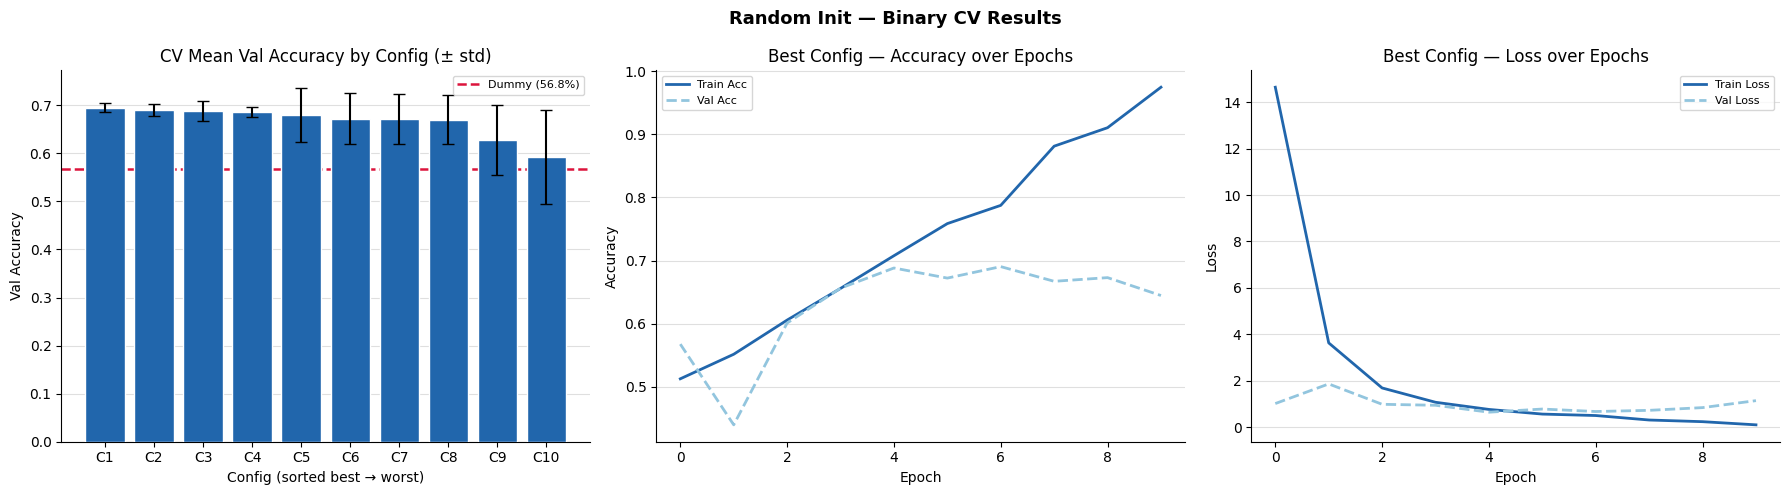

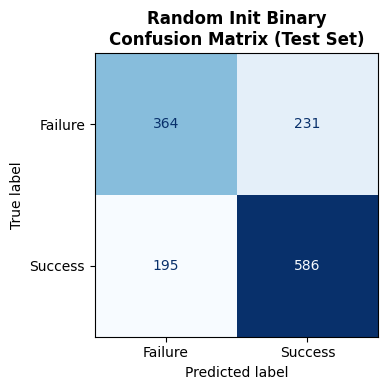

              precision    recall  f1-score   support

     Failure       0.65      0.61      0.63       595
     Success       0.72      0.75      0.73       781

    accuracy                           0.69      1376
   macro avg       0.68      0.68      0.68      1376
weighted avg       0.69      0.69      0.69      1376



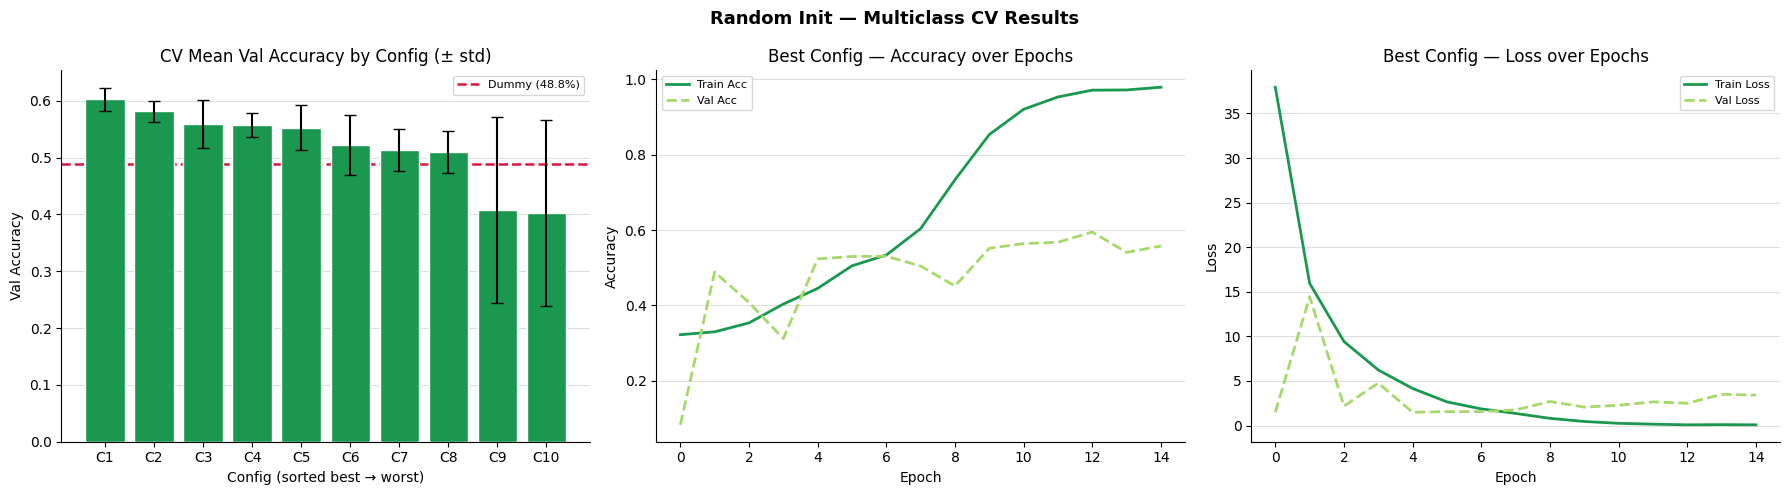

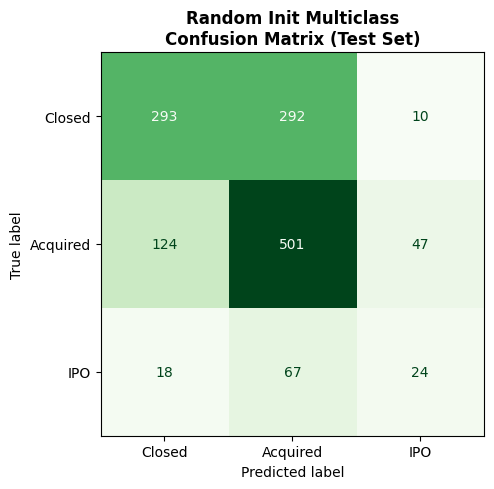

              precision    recall  f1-score   support

      Closed       0.67      0.49      0.57       595
    Acquired       0.58      0.75      0.65       672
         IPO       0.30      0.22      0.25       109

    accuracy                           0.59      1376
   macro avg       0.52      0.49      0.49      1376
weighted avg       0.60      0.59      0.59      1376



In [ ]:
#Plot the CV results for the Random Init model.
#This calls the predefined plot_results() function
#which reads from ALL_RESULTS['Random Init'] and
#draws the three-panel figure and confusion matrix
#for both binary and multiclass tasks.
plot_results('Random Init')

---
##Word2Vec Embeddings


In this section, I try out Word2Vect embeddings to see if they imporve the performance. In the code block below, I created the Word2Vec vocabulary, and build the matrix to be passed into our neural entwork.  Note: I had trouble importing Word2Vec onto Colab, and after some debugging the code below is able to bring Word2Vec onto the notebook.

In [ ]:
#Word2Vec was having a problem running
#so the code below shoudl fix it.
import subprocess, sys
subprocess.check_call(
    [sys.executable, '-m', 'pip', 'install',
     '-q', 'gensim'])

#Train Word2Vec on the full combined corpus
#(pool + test text, labels never used) so the
#model sees as much vocabulary as possible.
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess


#Set the Dimensionality of the Word2Vec
#vectos.
W2V_DIM = 100


#Conatenate all the textual columns
#in the cross validation pool(Note
#we do not include the test set
#to prevent leekage).
all_text = pd.concat([
    X_pool_about_b,
    X_pool_founder_b,
], ignore_index=True)


#Tokenize into list of words.
sentences = [simple_preprocess(str(t)) for t in all_text]

#Apply Word2Vec.
w2v_model = Word2Vec(
    sentences, vector_size=W2V_DIM,
    window=5, min_count=2,
    workers=4, seed=SEED)


#Check the vocabulary size of Word2Vec.
print(f'Word2Vec vocab size: {len(w2v_model.wv):,}')

#Helper function to help Keras read the vocabulary
#from Word 2 vec.
def build_w2v_matrix(tv_layer, w2v, dim):

    #Retrieve the Word2Vec voabulary.
    vocab  = tv_layer.get_vocabulary()

    #Create an empty matrix.
    matrix = np.zeros((len(vocab), dim), dtype='float32')

    #Initialize a counted to check how many
    #words were found in the as a diagnostic
    #to determine how much of the vocabulary
    #Word 2 vec was able to learn.
    hits   = 0

    #Loop to help build out the matrix.
    for idx, word in enumerate(vocab):

        #If the word is in Word2Vec,
        #add the word to our matrix.
        if word in w2v.wv:
            matrix[idx] = w2v.wv[word]
            hits += 1

    #Diagnostic print statement.
    print(f'  {hits}/{len(vocab)} vocab hits '
          f'({hits/len(vocab):.1%})')

    #Return the matrix.
    return matrix


#Diagnostic print statements.
print('Binary about   :'); w2v_mat_about_b   = build_w2v_matrix(tv_about_b,   w2v_model, W2V_DIM)
print('Binary founder :'); w2v_mat_founder_b = build_w2v_matrix(tv_founder_b, w2v_model, W2V_DIM)
print('Multi  about   :'); w2v_mat_about_m   = build_w2v_matrix(tv_about_m,   w2v_model, W2V_DIM)
print('Multi  founder :'); w2v_mat_founder_m = build_w2v_matrix(tv_founder_m, w2v_model, W2V_DIM)

Word2Vec vocab size: 1,577
Binary about   :
  1510/7141 vocab hits (21.1%)
Binary founder :
  1090/1115 vocab hits (97.8%)
Multi  about   :
  1463/7157 vocab hits (20.4%)
Multi  founder :
  1045/1119 vocab hits (93.4%)


###Word2Vec Binary Builder & CV

In this section, I create the builder function for the binary Word2Vec model to pass into the run_cv.

In [ ]:
#Builder for QKV binary with Word2Vec init.
#trainable=True lets embeddings fine-tune
#while starting from meaningful Word2Vec vectors.
def build_qkv_binary_w2v(dense_units, num_layers,
                          dropout_rate, learning_rate,
                          activation, optimizer_name,
                          emb_mat_about, emb_mat_founder):

    #Input layers for each of the
    #branches.
    about_inp = keras.Input(
        shape=(max_len_about,),   name='about_input')
    found_inp = keras.Input(
        shape=(max_len_founder,), name='founder_input')
    strct_inp = keras.Input(
        shape=(n_structured_cg,), name='struct_input')


    #About text branch.


    #Note the for loop in the end is so that
    #cross validation can manipulate the number of
    #layers in its grid search.
    a = layers.Embedding(
        emb_mat_about.shape[0], W2V_DIM,
        embeddings_initializer=keras.initializers.Constant(
            emb_mat_about),
        trainable=True, name='emb_about')(about_inp)
    a = layers.Attention()([a, a, a])
    a = layers.GlobalAveragePooling1D()(a)
    for _ in range(num_layers):
        a = layers.Dense(dense_units, activation=activation)(a)
        a = layers.Dropout(dropout_rate)(a)

    #About founder branch.


    #Note the for loop in the end is so that
    #cross validation can manipulate the number of
    #layers in its grid search.
    f = layers.Embedding(
        emb_mat_founder.shape[0], W2V_DIM,
        embeddings_initializer=keras.initializers.Constant(
            emb_mat_founder),
        trainable=True, name='emb_founder')(found_inp)
    f = layers.Attention()([f, f, f])
    f = layers.GlobalAveragePooling1D()(f)
    for _ in range(num_layers):
        f = layers.Dense(dense_units, activation=activation)(f)
        f = layers.Dropout(dropout_rate)(f)

    #Structured Inputs branch.


    #Note the for loop in the end is so that
    #cross validation can manipulate the number of
    #layers in its grid search.
    s = strct_inp
    for _ in range(num_layers):
        s = layers.Dense(dense_units, activation=activation)(s)
        s = layers.Dropout(dropout_rate)(s)

    #Concatenate all the 3 functions and
    #do the output.
    m = layers.Concatenate()([a, f, s])
    m = layers.Dense(dense_units // 2, activation=activation)(m)
    out = layers.Dense(1, activation='sigmoid')(m)

    #Build the Model and compile it.
    model = keras.Model(
        inputs=[about_inp, found_inp, strct_inp], outputs=out)
    model.compile(
        optimizer=get_optimizer(optimizer_name, learning_rate),
        loss='binary_crossentropy', metrics=['accuracy'])

    #Return the model.
    return model

###Word2Vec Multiclass Builder & CV

In this section, I create the builder function for the multiclass Word2Vec model to pass into the run_cv.

In [ ]:
#Builder for Bi-LSTM multiclass with Word2Vec init.
def build_bilstm_multi_w2v(dense_units, num_layers,
                            dropout_rate, learning_rate,
                            activation, optimizer_name,
                            emb_mat_about, emb_mat_founder,
                            lstm_units=64):

    #Define the inputs for each of the 3 branches.
    about_inp = keras.Input(
        shape=(max_len_a_m,), name='about_input')
    found_inp = keras.Input(
        shape=(max_len_f_m,), name='founder_input')
    strct_inp = keras.Input(
        shape=(n_struct_m,),  name='struct_input')

    #The about text branch.

    #Note the for loop in the end is so that
    #cross validation can manipulate the number of
    #layers in its grid search.
    a = layers.Embedding(
        emb_mat_about.shape[0], W2V_DIM,
        embeddings_initializer=keras.initializers.Constant(
            emb_mat_about),
        trainable=True, name='emb_about')(about_inp)
    a = layers.Bidirectional(
        layers.LSTM(lstm_units), name='bilstm_about')(a)
    for _ in range(num_layers):
        a = layers.Dense(dense_units, activation=activation)(a)
        a = layers.Dropout(dropout_rate)(a)



    #The fouders text branch.


    #Note the for loop in the end is so that
    #cross validation can manipulate the number of
    #layers in its grid search.
    f = layers.Embedding(
        emb_mat_founder.shape[0], W2V_DIM,
        embeddings_initializer=keras.initializers.Constant(
            emb_mat_founder),
        trainable=True, name='emb_founder')(found_inp)
    f = layers.Bidirectional(
        layers.LSTM(lstm_units), name='bilstm_founder')(f)
    for _ in range(num_layers):
        f = layers.Dense(dense_units, activation=activation)(f)
        f = layers.Dropout(dropout_rate)(f)

    #The structured inputs branch.


    #Note the for loop in the end is so that
    #cross validation can manipulate the number of
    #layers in its grid search.
    s = strct_inp
    for _ in range(num_layers):
        s = layers.Dense(dense_units, activation=activation)(s)
        s = layers.Dropout(dropout_rate)(s)

    #Concatenate all the 3 branches and output.
    m = layers.Concatenate()([a, f, s])
    m = layers.Dense(dense_units, activation=activation)(m)
    out = layers.Dense(3, activation='softmax')(m)

    #Create the model and compile it.
    model = keras.Model(
        inputs=[about_inp, found_inp, strct_inp], outputs=out)
    model.compile(
        optimizer=get_optimizer(optimizer_name, learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'])

    #Return the model.
    return model


### Run CV — Word2Vec

In the code below, I run the run_cv function to get the cross validation results for Word2Vec. Note: because of Word2Vec specific nature, I needed to input the vocabulary matricies directly as builder_kwards_b/m(binary/multiclass).

In [ ]:
#Run CV for Word2Vec embeddings.
#Builders: build_qkv_binary_w2v (binary)
#          build_bilstm_multi_w2v (multiclass)
#Arrays: same integer token sequences as Random Init
#        (the embedding matrix is passed via
#         builder_kwargs, not via the data arrays).
#builder_kwargs pass the W2V embedding matrices
#so the builder can initialise its Embedding layers.
run_cv(
    name       = 'Word2Vec',
    build_fn_b = build_qkv_binary_w2v,
    pool_a_b   = X_pool_about_vec,
    pool_f_b   = X_pool_founder_vec,
    pool_s_b   = X_pool_struct_np,
    test_a_b   = X_test_about_vec_b,
    test_f_b   = X_test_founder_vec_b,
    test_s_b   = X_test_struct_b,
    y_pool_b   = y_pool_b_np,
    y_test_b   = y_cg_test.values,
    build_fn_m = build_bilstm_multi_w2v,
    pool_a_m   = X_pool_about_vec_m,
    pool_f_m   = X_pool_founder_vec_m,
    pool_s_m   = X_pool_struct_m_np,
    test_a_m   = X_test_about_vec_m,
    test_f_m   = X_test_founder_vec_m,
    test_s_m   = X_test_struct_m,
    y_pool_m   = y_pool_m_np,
    y_test_m   = y_cg_test_cm.values,
    cw_dict    = cw_dict_pool,
    builder_kwargs_b = {
        'emb_mat_about'  : w2v_mat_about_b,  #Specific to Word2Vec.
        'emb_mat_founder': w2v_mat_founder_b,
    },
    builder_kwargs_m = {
        'emb_mat_about'  : w2v_mat_about_m,  #Specific to Word2Vec.
        'emb_mat_founder': w2v_mat_founder_m,
    },
)



  run_cv: Word2Vec

[Word2Vec] Binary CV (5 folds x 10 configs)...
  [Word2Vec] Config 01 binary -> 0.6586 ± 0.0370
  [Word2Vec] Config 02 binary -> 0.5141 ± 0.0664
  [Word2Vec] Config 03 binary -> 0.6201 ± 0.0518
  [Word2Vec] Config 04 binary -> 0.6324 ± 0.0536
  [Word2Vec] Config 05 binary -> 0.6584 ± 0.0169
  [Word2Vec] Config 06 binary -> 0.6590 ± 0.0460
  [Word2Vec] Config 07 binary -> 0.6535 ± 0.0446
  [Word2Vec] Config 08 binary -> 0.6317 ± 0.1003
  [Word2Vec] Config 09 binary -> 0.6615 ± 0.0248
  [Word2Vec] Config 10 binary -> 0.6003 ± 0.0928

[Word2Vec] Retraining best binary config...
Epoch 1/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.5145 - loss: 10.6886 - val_accuracy: 0.4462 - val_loss: 1.0383
Epoch 2/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5268 - loss: 2.5889 - val_accuracy: 0.6359 - val_loss: 0.6661
Epoch 3/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5835 - loss: 1.2610 - val_accuracy: 0.6163 - val_loss: 0.8861
Epoch 4/15


{'binary': {'test_acc': 0.6693,
  'test_loss': 0.8066,
  'best_config': {'dense_units': 64,
   'num_layers': 1,
   'drop_out_rate': 0.2,
   'learning_rate': 0.001,
   'batch': 32,
   'activation_function': 'elu',
   'optimizer': 'adamw',
   'mean_val_acc': 0.6615,
   'std_val_acc': 0.0248},
  'cv_df':    dense_units  num_layers  drop_out_rate  learning_rate  batch  \
  0           64           1            0.2         0.0010     32   
  1           64           2            0.2         0.0003     16   
  2           32           1            0.2         0.0010     16   
  3          128           1            0.2         0.0010     16   
  4           32           1            0.4         0.0010     32   
  5           64           2            0.4         0.0010     32   
  6          128           2            0.4         0.0003     32   
  7           32           2            0.2         0.0003     16   
  8          128           1            0.4         0.0003     16   
  9      

###Plot the Results

In this section, I plotted the cross validation results for Word2Vec.


<br>

Starting with the binary model, it achieved a test accuracy of 67%, slightly below the Random Init's 69%, which is interesting considering pre-trained embeddings should help in cases like mine. When it comes to recall, it is able to predict Success better, at around 80%, when compared to Random Init's 75%. However, its recall on failure is only 50% compared to Random init's 61%. VC firms use successes to compensate for the losses incurred in failures, which would make this model slightly more favorable in some cases, especially where the fund may have excess cash and is willing to have more losses. Like the Random init model, this one also overfits, with training accuracy increasing substantially, while validation accuracy is the same across epochs.


<br>

Moving on the the multiclass model, it achieved a 58% accuracy, 1% less than the Random Init model. However, this mdoel does have notable improvement in IPO recall, going from 22% in Random Init, to 43% in this model. The other recalls remained relatively the same, meaning that for VCs looking for IPOs, this model would be more suited. Unfortunately, overfitting is also present here, with the training accuray capping at around 95%, while the validation accuracy is capped at the high 50%.


<br>

Word2Vec gains in the multiclass setting, specifically with IPO predictions. However, its models still suffer from overfitting. When lookign at the Loss graph here and the Random Init section, this could be due to the validation loss not increasing or decreasing dramatically over epochs, while the model learns the training patterns instantly. This could be a consequence of my small data size.

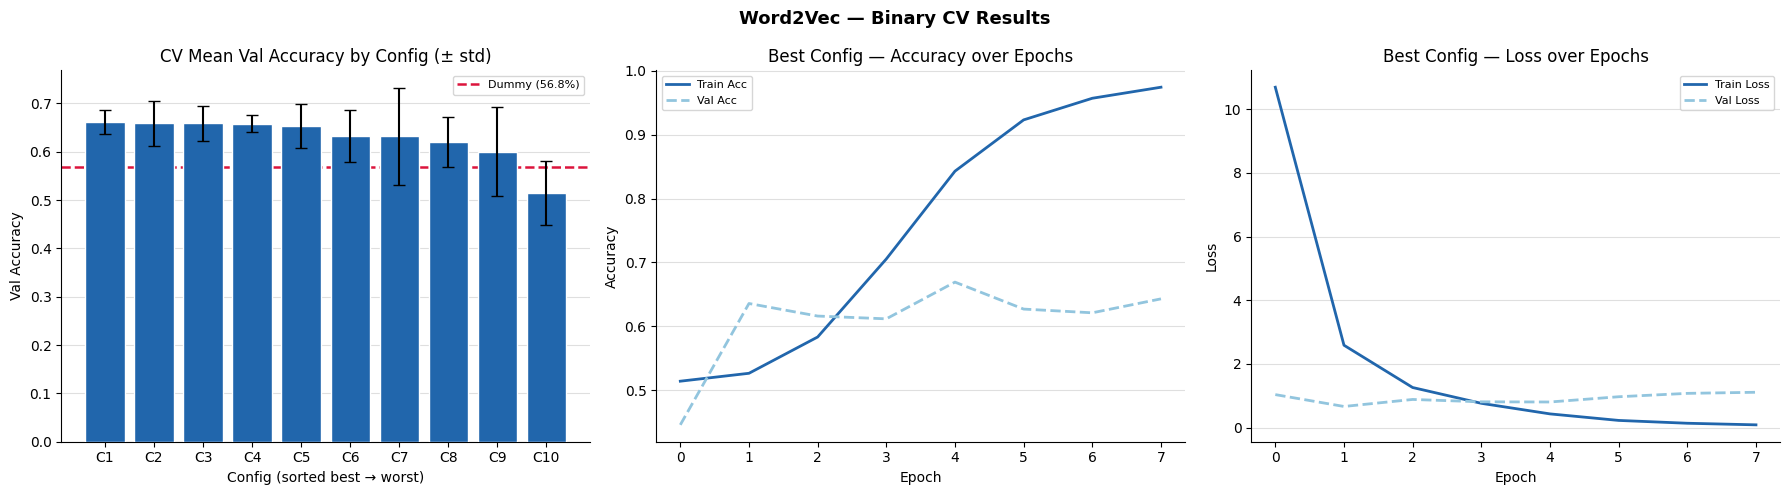

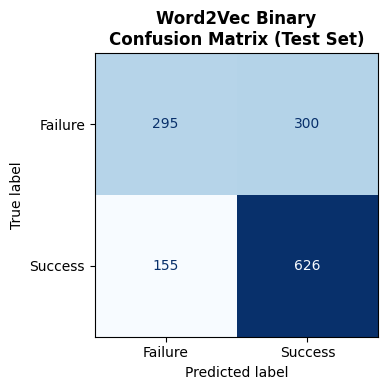

              precision    recall  f1-score   support

     Failure       0.66      0.50      0.56       595
     Success       0.68      0.80      0.73       781

    accuracy                           0.67      1376
   macro avg       0.67      0.65      0.65      1376
weighted avg       0.67      0.67      0.66      1376



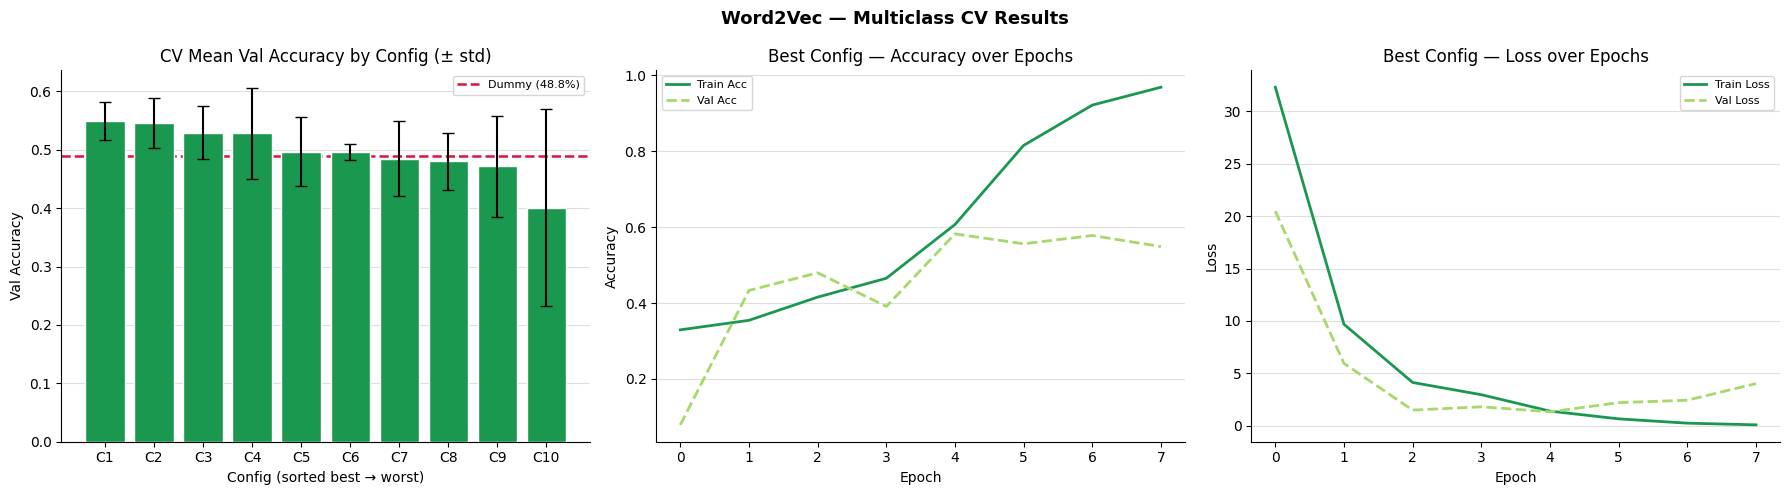

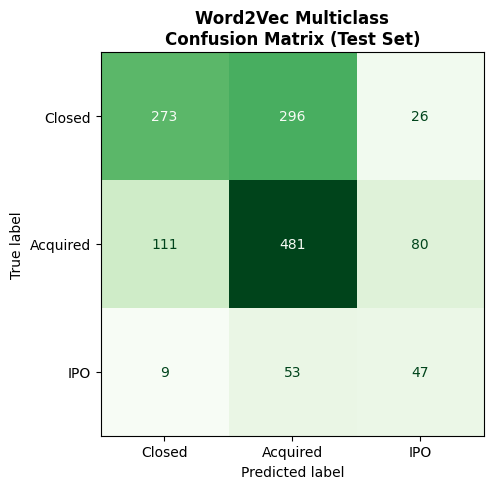

              precision    recall  f1-score   support

      Closed       0.69      0.46      0.55       595
    Acquired       0.58      0.72      0.64       672
         IPO       0.31      0.43      0.36       109

    accuracy                           0.58      1376
   macro avg       0.53      0.54      0.52      1376
weighted avg       0.61      0.58      0.58      1376



In [ ]:
#Plot the cross validation results.
plot_results('Word2Vec')

---
##BERT Embeddings (keras_hub RoBERTa)


In this section, I test out the BERT embeddings(using RoBERTa from one of the class notebooks) to see if they improve the performance.


To set it up, a couple of steps are needed:
1. Load RoBERTa. This gives us a tokenizer and a backbone(the embedding part).

2. Tokenize each text column into a column of integers and add 3 special RoBERTa tokens for input:
    * CLS-The special summary token at position 0, that absorbs the information from every other token in the sequence.

    * EOS- The stop token, to tell RoBERTa to stop.

    * PAD- The token added after the EOS, to make sure all the sequences in a batch are the same length.
3. Pass through the backbone, and retrieve the CLS token.
4. Store the CLS vectors as numpy arrays.
5. Feed the list of CLS vectors into the model.

In [ ]:
#Install keras_hub so we can load the RoBERTa
#backbone exactly as done in the course notebook.
#Note the subprocess thing is here because without it,
#colab was having trouble implementing keras hub.
import subprocess, sys
subprocess.check_call([
    sys.executable, '-m', 'pip', 'install',
    '-q', 'keras-hub'
])

import keras_hub
import keras
import tensorflow as tf
import numpy as np

#Load the RoBERTa tokenizer and backbone.
print('Loading RoBERTa tokenizer and backbone...')
rob_tokenizer = keras_hub.models.Tokenizer.from_preset(
    'roberta_base_en')
rob_backbone  = keras_hub.models.Backbone.from_preset(
    'roberta_base_en')

#Freeze all backbone weights so only the Dense
#head layers train.
rob_backbone.trainable = False
print(f'Backbone loaded. Trainable: {rob_backbone.trainable}')
rob_backbone.summary()

Loading RoBERTa tokenizer and backbone...
Backbone loaded. Trainable: False


Model: "roberta_backbone"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ token_ids           │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embeddings          │ (None, None, 768) │ 38,996,736 │ token_ids[0][0]   │
│ (TokenAndPositionE… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embeddings_layer_n… │ (None, None, 768) │      1,536 │ embeddings[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embeddings_dropout  │ (None, None, 768) │          0 │ embeddings_layer… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ padding_mask        │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_layer_0 │ (None, None, 768) │  7,087,872 │ embeddings_dropo… │
│ (TransformerEncode… │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_layer_1 │ (None, None, 768) │  7,087,872 │ transformer_laye… │
│ (TransformerEncode… │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_layer_2 │ (None, None, 768) │  7,087,872 │ transformer_laye… │
│ (TransformerEncode… │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_layer_3 │ (None, None, 768) │  7,087,872 │ transformer_laye… │
│ (TransformerEncode… │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_layer_4 │ (None, None, 768) │  7,087,872 │ transformer_laye… │
│ (TransformerEncode… │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_layer_5 │ (None, None, 768) │  7,087,872 │ transformer_laye… │
│ (TransformerEncode… │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_layer_6 │ (None, None, 768) │  7,087,872 │ transformer_laye… │
│ (TransformerEncode… │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_layer_7 │ (None, None, 768) │  7,087,872 │ transformer_laye… │
│ (TransformerEncode… │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_layer_8 │ (None, None, 768) │  7,087,872 │ transformer_laye… │
│ (TransformerEncode… │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_layer_9 │ (None, None, 768) │  7,087,872 │ transformer_laye… │
│ (TransformerEncode… │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_layer_… │ (None, None, 768) │  7,087,872 │ transformer_laye… │
│ (TransformerEncode… │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_layer_… │ (None, None, 768) │  7,087,872 │ transformer_laye

 Total params: 124,052,736 (473.22 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 124,052,736 (473.22 MB)

In [ ]:
#Set a cap of 128 tokens because our textual columns
#are relatively short.
SEQ_LEN = 128



def tokenize_texts(texts):
    #Build the packer that will add our
    #CLS, EOS and PAD tokens to every sequnce
    #and enforce that they are all of length 128
    #(as defined by the seq_len)
    packer = keras_hub.layers.StartEndPacker(

        #Define the maximum sequence length
        #to be 128.
        sequence_length=SEQ_LEN,


        #Input the CLS, EOD, and PAD token
        #Ids into the packer.
        start_value=rob_tokenizer.start_token_id,

        end_value=rob_tokenizer.end_token_id,

        pad_value=rob_tokenizer.pad_token_id,


        #Add a mask to say whether a token
        #is 'real' or just a pad token.
        return_padding_mask=True,
    )



    #Intialize empty lists to collect
    #the results batch by batch.
    token_ids_list   = []
    padding_mask_list = []


    #Process in batches for efficiency.
    batch_size = 64

    #Loop through, processing each batch.
    for start in range(0, len(texts), batch_size):

        #Extract the specific portion of text
        #in the batch.
        batch = texts[start:start + batch_size]

        #Tokenize the text in the batch.
        tok   = rob_tokenizer(batch)

        #Apply our packer to add the CLS, EOD,
        #and PAD tokens.

        #Get the specific token ids, as well
        #as the padding mask.
        ids, mask = packer(tok)

        #Add the token_ids and padding mask to our
        #our lists.
        token_ids_list.append(ids.numpy())
        padding_mask_list.append(mask.numpy())

    #Combine all of the batches into a 2 dimensioal matrix.
    return (np.concatenate(token_ids_list,   axis=0),
            np.concatenate(padding_mask_list, axis=0))



#Takes the token IDs and padding mask from
#tokenize_texts(), runs them through the
#frozen RoBERTa Backbone to extract the CLS vector
#for each.
def get_cls_embeddings(token_ids, padding_mask,
                        batch_size=32):

    #Initialize an empty list to store
    #the embeddigns.
    embeddings = []

    #Loop through in batches of 32.
    for start in range(0, len(token_ids), batch_size):

        #Store the ids and the padding mask.
        ids  = token_ids[start:start + batch_size]
        mask = padding_mask[start:start + batch_size]



        #Pass through the backbone, to get
        #the embeddings.
        out = rob_backbone(
            {'token_ids': ids,
             'padding_mask': mask},
            training=False
        )


        #The out variables is 3 dimensional,
        #with the second dimension representing
        #the token positions. Since, the CLS
        #token is at the first token position,
        #we slice with 0 in the middle to get it.
        cls_vec = out[:, 0, :].numpy()

        #Add the cls vector to our embeddings
        #list.
        embeddings.append(cls_vec)

    #Concatenate into a 2 dimensional matrix.
    return np.concatenate(embeddings, axis=0)



#A helper to call both of the fucntions
#above in one go.
def encode_texts(texts):

    #Diagnostic print statement.
    print(f'  Tokenizing {len(texts)} texts...')

    #Call the tokenize_texts function.
    ids, mask = tokenize_texts(texts)

    #Diagnostic print statement.
    print(f'  Extracting CLS embeddings...')

    #Call the get_cls embeddings and return it.
    return get_cls_embeddings(ids, mask)

#Encode all binary task splits.
print('=== Encoding Binary Task Splits ===')
bert_pool_ab = encode_texts(X_pool_about_b.tolist())
bert_pool_fb = encode_texts(X_pool_founder_b.tolist())
bert_test_ab = encode_texts(X_cg_test_about.tolist())
bert_test_fb = encode_texts(X_cg_test_founder.tolist())

#Encode all multiclass task splits.
print('=== Encoding Multiclass Task Splits ===')
bert_pool_am = encode_texts(X_pool_about_m.tolist())
bert_pool_fm = encode_texts(X_pool_founder_m.tolist())
bert_test_am = encode_texts(X_cg_test_about_cm.tolist())
bert_test_fm = encode_texts(X_cg_test_founder_cm.tolist())

#Store the embedding dimension. RoBERTa base
#produces 768-d vectors — same as full BERT.
BERT_DIM = bert_pool_ab.shape[1]
print(f'Done.')
print(f'Embedding dim        : {BERT_DIM}')
print(f'Binary pool shape    : {bert_pool_ab.shape}')
print(f'Multiclass pool shape: {bert_pool_am.shape}')

=== Encoding Binary Task Splits ===
  Tokenizing 5501 texts...
  Extracting CLS embeddings...
  Tokenizing 5501 texts...
  Extracting CLS embeddings...
  Tokenizing 1376 texts...
  Extracting CLS embeddings...
  Tokenizing 1376 texts...
  Extracting CLS embeddings...
=== Encoding Multiclass Task Splits ===
  Tokenizing 5501 texts...
  Extracting CLS embeddings...
  Tokenizing 5501 texts...
  Extracting CLS embeddings...
  Tokenizing 1376 texts...
  Extracting CLS embeddings...
  Tokenizing 1376 texts...
  Extracting CLS embeddings...
Done.
Embedding dim        : 768
Binary pool shape    : (5501, 768)
Multiclass pool shape: (5501, 768)


###BERT Binary Builder & CV

In this section, I create the builder function for the binary BERT model to pass into the run_cv.

In [ ]:
#For BERT we skip the Embedding layer because
#text is already encoded as 768-d CLS vectors.
#We replace embed+attention with Dense projection
#layers. num_layers still controls depth here.
def build_binary_bert(dense_units, num_layers,
                       dropout_rate, learning_rate,
                       activation, optimizer_name):


    #Define the input layers for each branch.
    about_inp = keras.Input(
        shape=(BERT_DIM,),      name='about_bert')
    found_inp = keras.Input(
        shape=(BERT_DIM,),      name='founder_bert')
    strct_inp = keras.Input(
        shape=(n_structured_cg,),name='struct_input')

    #The about text branch.

    #Note: the for loop is so that the cross validaiton
    #can add layers.
    a = about_inp
    for _ in range(num_layers):
        a = layers.Dense(dense_units, activation=activation)(a)
        a = layers.Dropout(dropout_rate)(a)



    #The founder background branch.

    #Note: the for loop is so that the cross validaiton
    #can add layers.
    f = found_inp
    for _ in range(num_layers):
        f = layers.Dense(dense_units, activation=activation)(f)
        f = layers.Dropout(dropout_rate)(f)


    #The structured branch.

    #Note: the for loop is so that the cross validaiton
    #can add layers.
    s = strct_inp
    for _ in range(num_layers):
        s = layers.Dense(dense_units, activation=activation)(s)
        s = layers.Dropout(dropout_rate)(s)

    #Concatenate all 3 branches and ouput it with a Sigmoid
    #activation.
    m = layers.Concatenate()([a, f, s])
    m = layers.Dense(dense_units // 2, activation=activation)(m)
    out = layers.Dense(1, activation='sigmoid')(m)

    #Create the model and compile it.
    model = keras.Model(
        inputs=[about_inp, found_inp, strct_inp], outputs=out)

    model.compile(
        optimizer=get_optimizer(optimizer_name, learning_rate),
        loss='binary_crossentropy', metrics=['accuracy'])

    #Return the model.
    return model



###BERT Multiclass Builder & CV

In this section, I create the builder function for the multiclass BERT model to pass into the run_cv.

In [ ]:
#Multiclass BERT model: same Dense-projection
#pattern, output is softmax over 3 classes.
def build_multi_bert(dense_units, num_layers,
                     dropout_rate, learning_rate,
                     activation, optimizer_name):

    #Define the input layers for each branch.
    about_inp = keras.Input(
        shape=(BERT_DIM,),  name='about_bert')
    found_inp = keras.Input(
        shape=(BERT_DIM,),  name='founder_bert')
    strct_inp = keras.Input(
        shape=(n_struct_m,),name='struct_input')


    #The about text branch.

    #Note: the for loop is so that the cross validaiton
    #can add layers.
    a = about_inp
    for _ in range(num_layers):
        a = layers.Dense(dense_units, activation=activation)(a)
        a = layers.Dropout(dropout_rate)(a)


    #The founder background branch.

    #Note: the for loop is so that the cross validaiton
    #can add layers.
    f = found_inp
    for _ in range(num_layers):
        f = layers.Dense(dense_units, activation=activation)(f)
        f = layers.Dropout(dropout_rate)(f)


    #Note: the for loop is so that the cross validaiton
    #can add layers.
    s = strct_inp
    for _ in range(num_layers):
        s = layers.Dense(dense_units, activation=activation)(s)
        s = layers.Dropout(dropout_rate)(s)

    #Concatenate all the 3 branches, apply an activation,
    #and output using softmax.
    m = layers.Concatenate()([a, f, s])
    m = layers.Dense(dense_units, activation=activation)(m)
    out = layers.Dense(3, activation='softmax')(m)

    #Create the model and compile it.
    model = keras.Model(
        inputs=[about_inp, found_inp, strct_inp], outputs=out)

    model.compile(
        optimizer=get_optimizer(optimizer_name, learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'])

    #Return the model.
    return model


### Run CV — RoBERTa

In the code below, I run the run_cv function to get the cross validation results for RoBERTa.

In [ ]:
#Run CV for RoBERTa embeddings.
#Builders: build_binary_bert (binary)
#          build_multi_bert (multiclass)
#Arrays: 768-d CLS numpy arrays from the
#        keras_hub encoding cell above.
#No extra builder_kwargs needed.
run_cv(
    name       = 'RoBERTa',
    build_fn_b = build_binary_bert,
    pool_a_b   = bert_pool_ab,
    pool_f_b   = bert_pool_fb,
    pool_s_b   = X_pool_struct_np,
    test_a_b   = bert_test_ab,
    test_f_b   = bert_test_fb,
    test_s_b   = X_test_struct_b,
    y_pool_b   = y_pool_b_np,
    y_test_b   = y_cg_test.values,
    build_fn_m = build_multi_bert,
    pool_a_m   = bert_pool_am,
    pool_f_m   = bert_pool_fm,
    pool_s_m   = X_pool_struct_m_np,
    test_a_m   = bert_test_am,
    test_f_m   = bert_test_fm,
    test_s_m   = X_test_struct_m,
    y_pool_m   = y_pool_m_np,
    y_test_m   = y_cg_test_cm.values,
    cw_dict    = cw_dict_pool,
)



  run_cv: RoBERTa

[RoBERTa] Binary CV (5 folds x 10 configs)...
  [RoBERTa] Config 01 binary -> 0.6330 ± 0.0545
  [RoBERTa] Config 02 binary -> 0.5855 ± 0.0512
  [RoBERTa] Config 03 binary -> 0.5992 ± 0.0383
  [RoBERTa] Config 04 binary -> 0.6253 ± 0.0479
  [RoBERTa] Config 05 binary -> 0.6604 ± 0.0496
  [RoBERTa] Config 06 binary -> 0.5875 ± 0.0399
  [RoBERTa] Config 07 binary -> 0.6350 ± 0.0401
  [RoBERTa] Config 08 binary -> 0.5783 ± 0.0206
  [RoBERTa] Config 09 binary -> 0.6681 ± 0.0244
  [RoBERTa] Config 10 binary -> 0.5654 ± 0.0788

[RoBERTa] Retraining best binary config...
Epoch 1/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.5121 - loss: 9.3496 - val_accuracy: 0.6010 - val_loss: 0.6565
Epoch 2/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5372 - loss: 1.8313 - val_accuracy: 0.4782 - val_loss: 0.7161
Epoch 3/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5639 - loss: 1.0390 - val_accuracy: 0.5298 - val_loss: 0.7200
Epoch 4/15
172/172 ━━━━━━

{'binary': {'test_acc': 0.6882,
  'test_loss': 0.6351,
  'best_config': {'dense_units': 64,
   'num_layers': 1,
   'drop_out_rate': 0.2,
   'learning_rate': 0.001,
   'batch': 32,
   'activation_function': 'elu',
   'optimizer': 'adamw',
   'mean_val_acc': 0.6681,
   'std_val_acc': 0.0244},
  'cv_df':    dense_units  num_layers  drop_out_rate  learning_rate  batch  \
  0           64           1            0.2         0.0010     32   
  1          128           1            0.2         0.0010     16   
  2           32           1            0.4         0.0010     32   
  3           32           1            0.2         0.0010     16   
  4           64           2            0.4         0.0010     32   
  5           32           2            0.2         0.0003     16   
  6           64           2            0.2         0.0003     16   
  7           64           1            0.4         0.0003     32   
  8          128           2            0.4         0.0003     32   
  9      

###Plot the Results

In this section, I plotted the resutls for the RoBERTa model.

<br>

For its best binary model, RoBERTa achieved an accuracy of 69%, matching Random Init and beating Word2Vec slightly. When it comes to recall, the model shows a significant improvement in detecting failures, at around 69% when compared to Random Init's 61% and Word2Vec's 50%. Unfortunately, its ability to predict success dropped to 69%, from Word2Vec's high of 80%. This would make the RoBERTa model more ideal for VCs when they are feeling pessimistic about the market and want to be more cautious. Another good thing to note is that the model does nto overfit as much as the previous ones, with validation accuracy sometimes being higher than the train accuracy. However, considering the Validation Accuracy's instability, it is unlikely that more training epochs would lead to a huge increase in performance.

<br>

Moving to the multiclass model, it hit 62% accuracy, the best result for multiclass category so far. However, it does have some drawbacks when it comes to recall, wiht IPOs having the lowest result yet at 11%. Moreover, the Acquisition category dropped to 65%, lower than that of the previous models'. However, there is an improvement at detecting closed companies, further solidifying RoBERTa as a good embedding for pessimistic scenarios. The over epochs results showcase a healthy training pattern, with training and validation loss decreasing more gradualy and together.

<br>

The richer language in RoBERTa gives it a better ability to detecting failures in Recall which can be useful in some scenarios to VCs. To add on, the model exhibits less overfitting than the previous ones.

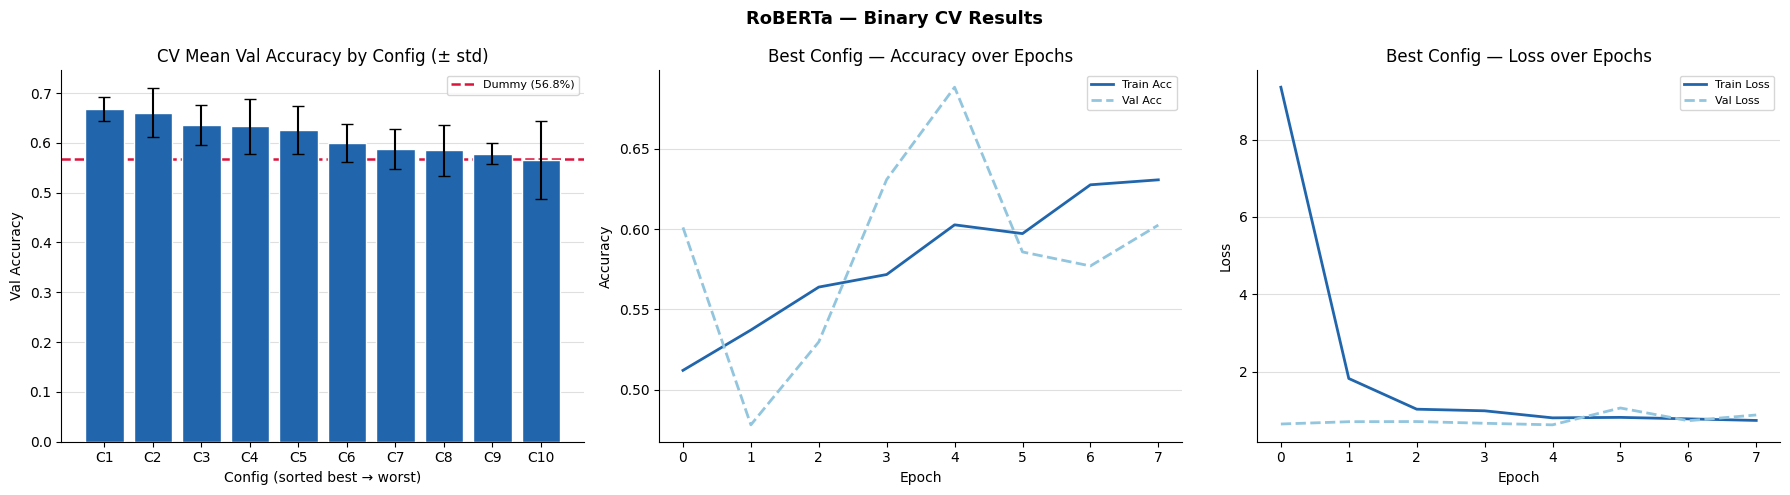

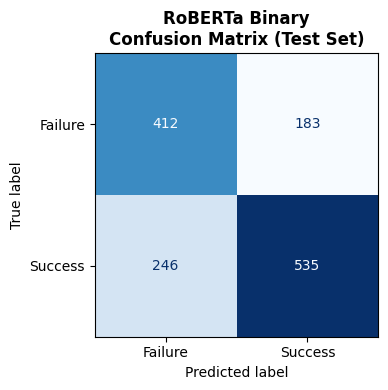

              precision    recall  f1-score   support

     Failure       0.63      0.69      0.66       595
     Success       0.75      0.69      0.71       781

    accuracy                           0.69      1376
   macro avg       0.69      0.69      0.69      1376
weighted avg       0.69      0.69      0.69      1376



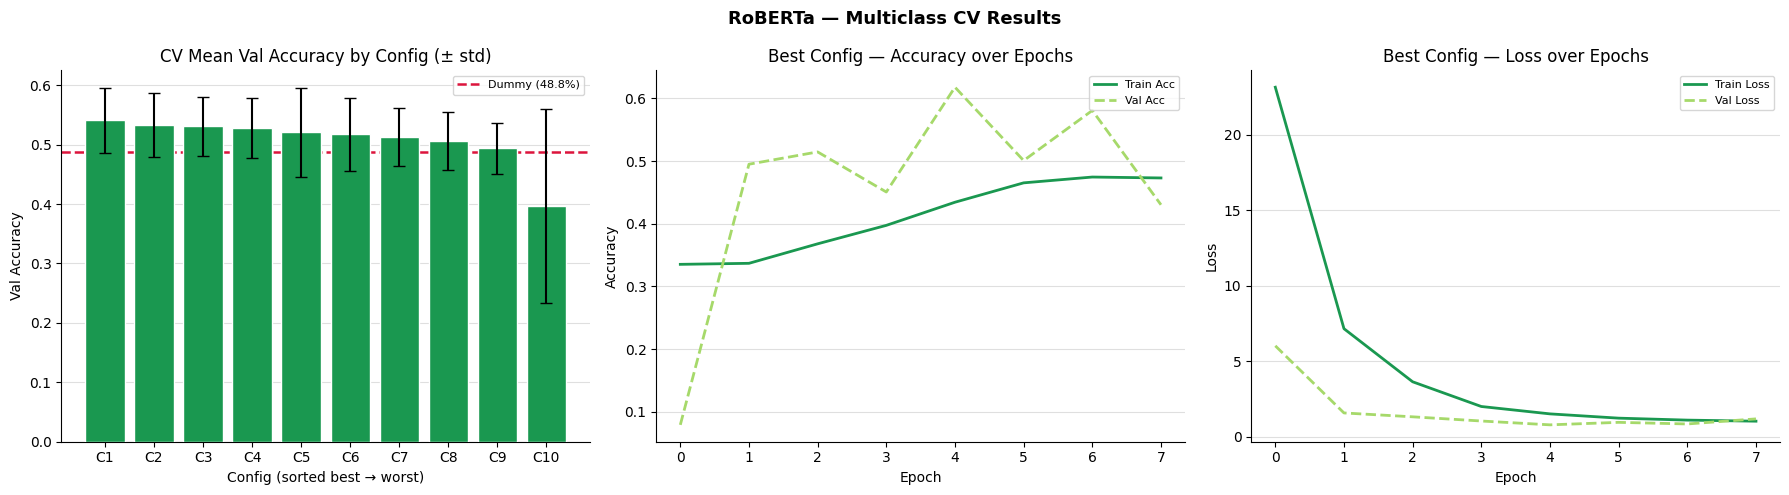

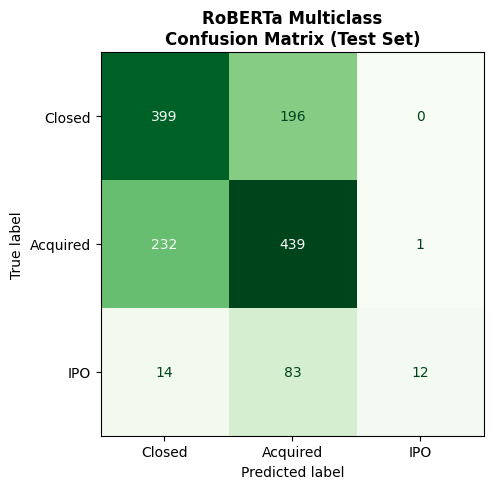

              precision    recall  f1-score   support

      Closed       0.62      0.67      0.64       595
    Acquired       0.61      0.65      0.63       672
         IPO       0.92      0.11      0.20       109

    accuracy                           0.62      1376
   macro avg       0.72      0.48      0.49      1376
weighted avg       0.64      0.62      0.60      1376



In [ ]:
plot_results('RoBERTa')

---
##Finance-Specific Pre-Trained Models


In this section, I try out some embeddings designed specifically for financial contexts. Model like, Word2Vec and RoBERTa were trained on the general internet data and may not be specialized to determining financial success. Considering my project deals with the financial success of startups, I thought these deserved a test to check if domain specific embeddings can actually help in predicting startup success.

<br>

The 3 models used for this are the following:

* FinBERT - trained on financial new and sentiment data.

* SEC-BERT - trained on actual SEC filings which describe what companies do, their business model, and their risks(similar to my about text column).
* FinancialBERT - trained on financial sentiment(more short-term focused than FinBERT).

###FinBert

In this section, I try out the FinBert Embeddings.

In [ ]:
#Import sentence transformers.
from sentence_transformers import SentenceTransformer

#SentenceTransformers instead of keras_hub because the FinBERT
#is stored in PyTorch format and Sentence Transformer
#helps us to use it in keras.
finbert_model = SentenceTransformer('ProsusAI/finbert')
print('FinBERT loaded successfully!')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning:


The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.



config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

BertModel LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 
classifier.bias              | UNEXPECTED |  | 
classifier.weight            | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

FinBERT loaded successfully!


In [ ]:

#Load FinBERT.
print('Loading FinBERT...')
finbert_model = SentenceTransformer('ProsusAI/finbert')
print('Model loaded. Encoding splits...')

#Binary encoding.

#Encode the binary about_text pool.
print('  Binary pool about...')
finbert_pool_ab = finbert_model.encode(
    X_pool_about_b.tolist(),
    show_progress_bar=True, batch_size=32)

#Encode the binary founder pool.
print('  Binary pool founder...')
finbert_pool_fb = finbert_model.encode(
    X_pool_founder_b.tolist(),
    show_progress_bar=True, batch_size=32)

#Encode the binary about_text test set.
print('  Binary test about...')
finbert_test_ab = finbert_model.encode(
    X_cg_test_about.tolist(),
    show_progress_bar=True, batch_size=32)

#Encode the binary founder test set.
print('  Binary test founder...')
finbert_test_fb = finbert_model.encode(
    X_cg_test_founder.tolist(),
    show_progress_bar=True, batch_size=32)



#Multiclass encoding.

#Encode the multiclass about_text pool.
print('  Multiclass pool about...')
finbert_pool_am = finbert_model.encode(
    X_pool_about_m.tolist(),
    show_progress_bar=True, batch_size=32)

#Encode the multiclass founder pool.
print('  Multiclass pool founder...')
finbert_pool_fm = finbert_model.encode(
    X_pool_founder_m.tolist(),
    show_progress_bar=True, batch_size=32)

#Encode the multiclass about_text test set.
print('  Multiclass test about...')
finbert_test_am = finbert_model.encode(
    X_cg_test_about_cm.tolist(),
    show_progress_bar=True, batch_size=32)

#Encode the multiclass founder test set.
print('  Multiclass test founder...')
finbert_test_fm = finbert_model.encode(
    X_cg_test_founder_cm.tolist(),
    show_progress_bar=True, batch_size=32)

#Retrieve the FinBERT Dimension for keras.
FINBERT_DIM = finbert_pool_ab.shape[1]
print(f'Done. Dim: {FINBERT_DIM}, '
      f'pool shape: {finbert_pool_ab.shape}')

Loading FinBERT...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 
classifier.bias              | UNEXPECTED |  | 
classifier.weight            | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded. Encoding splits...
  Binary pool about...


Batches:   0%|          | 0/172 [00:00<?, ?it/s]

...

  Multiclass test about...


Batches:   0%|          | 0/43 [00:00<?, ?it/s]

  Multiclass test founder...


Batches:   0%|          | 0/43 [00:00<?, ?it/s]

Done. Dim: 768, pool shape: (5501, 768)


####FinBERT Model Builders & CV

In this section, I create the builder function for the binary and multiclass FinBERT models to pass into the run_cv.

In [ ]:
#Builder functions for FinBERT.
#Architecture is identical to the RoBERTa
#section: Dense projection layers operating
#on fixed-length sentence embeddings.
#The only difference is the input dimension
#which is read from FINBERT_DIM.

def build_binary_finbert(dense_units, num_layers,
                              dropout_rate, learning_rate,
                              activation, optimizer_name):


    #Define the input layers for each of the branches.
    about_inp = keras.Input(
        shape=(FINBERT_DIM,), name='about_inp')
    found_inp = keras.Input(
        shape=(FINBERT_DIM,), name='founder_inp')
    strct_inp = keras.Input(
        shape=(n_structured_cg,), name='struct_inp')

    #About text branch.
    a = about_inp
    for _ in range(num_layers):
        a = layers.Dense(dense_units, activation=activation)(a)
        a = layers.Dropout(dropout_rate)(a)


    #Founder text branch.
    f = found_inp
    for _ in range(num_layers):
        f = layers.Dense(dense_units, activation=activation)(f)
        f = layers.Dropout(dropout_rate)(f)

    #Structured branch.
    s = strct_inp
    for _ in range(num_layers):
        s = layers.Dense(dense_units, activation=activation)(s)
        s = layers.Dropout(dropout_rate)(s)

    #Concatenate all 3 branhces, apply an activation
    #and then output using Sigmoid activation.
    m = layers.Concatenate()([a, f, s])
    m = layers.Dense(dense_units // 2, activation=activation)(m)
    out = layers.Dense(1, activation='sigmoid')(m)

    #Create the keras model and compile it.
    model = keras.Model(
        inputs=[about_inp, found_inp, strct_inp], outputs=out)

    model.compile(
        optimizer=get_optimizer(optimizer_name, learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy'])

    #Return the model.
    return model



def build_multi_finbert(dense_units, num_layers,
                             dropout_rate, learning_rate,
                             activation, optimizer_name):

    #Define the input layers for each of the branches.
    about_inp = keras.Input(
        shape=(FINBERT_DIM,), name='about_inp')
    found_inp = keras.Input(
        shape=(FINBERT_DIM,), name='founder_inp')
    strct_inp = keras.Input(
        shape=(n_struct_m,), name='struct_inp')

    #About text branch.
    a = about_inp
    for _ in range(num_layers):
        a = layers.Dense(dense_units, activation=activation)(a)
        a = layers.Dropout(dropout_rate)(a)


    #Founder text branch.
    f = found_inp
    for _ in range(num_layers):
        f = layers.Dense(dense_units, activation=activation)(f)
        f = layers.Dropout(dropout_rate)(f)

    #Structured branch.
    s = strct_inp
    for _ in range(num_layers):
        s = layers.Dense(dense_units, activation=activation)(s)
        s = layers.Dropout(dropout_rate)(s)

    #Concatenate all the branchesm apply an activation
    #function, then output using softmax.
    m = layers.Concatenate()([a, f, s])
    m = layers.Dense(dense_units, activation=activation)(m)
    out = layers.Dense(3, activation='softmax')(m)

    #Create the model and compile it.
    model = keras.Model(
        inputs=[about_inp, found_inp, strct_inp], outputs=out)
    model.compile(
        optimizer=get_optimizer(optimizer_name, learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'])

    #Return the model.
    return model

print('Builders defined for FinBERT.')

Builders defined for FinBERT.


#### Run CV — FinBERT

In this section, I run_cv using the FinBERT embeddings.

In [ ]:
#Run CV for FinBERT.
#Builders: build_binary_finbert (binary)
#          build_multi_finbert (multiclass)
#Arrays: sentence-transformers CLS numpy
#        arrays encoded in the cell above.
#No extra builder_kwargs needed.
run_cv(
    name       = 'FinBERT',
    build_fn_b = build_binary_finbert,
    pool_a_b   = finbert_pool_ab,
    pool_f_b   = finbert_pool_fb,
    pool_s_b   = X_pool_struct_np,
    test_a_b   = finbert_test_ab,
    test_f_b   = finbert_test_fb,
    test_s_b   = X_test_struct_b,
    y_pool_b   = y_pool_b_np,
    y_test_b   = y_cg_test.values,
    build_fn_m = build_multi_finbert,
    pool_a_m   = finbert_pool_am,
    pool_f_m   = finbert_pool_fm,
    pool_s_m   = X_pool_struct_m_np,
    test_a_m   = finbert_test_am,
    test_f_m   = finbert_test_fm,
    test_s_m   = X_test_struct_m,
    y_pool_m   = y_pool_m_np,
    y_test_m   = y_cg_test_cm.values,
    cw_dict    = cw_dict_pool,
)



  run_cv: FinBERT

[FinBERT] Binary CV (5 folds x 10 configs)...
  [FinBERT] Config 01 binary -> 0.6357 ± 0.0561
  [FinBERT] Config 02 binary -> 0.5372 ± 0.0958
  [FinBERT] Config 03 binary -> 0.6322 ± 0.0542
  [FinBERT] Config 04 binary -> 0.5679 ± 0.0004
  [FinBERT] Config 05 binary -> 0.6415 ± 0.0420
  [FinBERT] Config 06 binary -> 0.6152 ± 0.0295
  [FinBERT] Config 07 binary -> 0.6502 ± 0.0460
  [FinBERT] Config 08 binary -> 0.6313 ± 0.0333
  [FinBERT] Config 09 binary -> 0.6728 ± 0.0110
  [FinBERT] Config 10 binary -> 0.6421 ± 0.0418

[FinBERT] Retraining best binary config...
Epoch 1/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.5128 - loss: 6.6568 - val_accuracy: 0.5334 - val_loss: 0.7860
Epoch 2/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5612 - loss: 1.6247 - val_accuracy: 0.4339 - val_loss: 1.2064
Epoch 3/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5932 - loss: 1.0697 - val_accuracy: 0.6555 - val_loss: 0.6242
Epoch 4/15
172/172 ━━━━━━

{'binary': {'test_acc': 0.6555,
  'test_loss': 0.6242,
  'best_config': {'dense_units': 64,
   'num_layers': 1,
   'drop_out_rate': 0.2,
   'learning_rate': 0.001,
   'batch': 32,
   'activation_function': 'elu',
   'optimizer': 'adamw',
   'mean_val_acc': 0.6728,
   'std_val_acc': 0.011},
  'cv_df':    dense_units  num_layers  drop_out_rate  learning_rate  batch  \
  0           64           1            0.2         0.0010     32   
  1           32           1            0.4         0.0010     32   
  2          128           1            0.4         0.0003     16   
  3          128           1            0.2         0.0010     16   
  4           32           1            0.2         0.0010     16   
  5           32           2            0.2         0.0003     16   
  6          128           2            0.4         0.0003     32   
  7           64           2            0.2         0.0003     16   
  8           64           2            0.4         0.0010     32   
  9       

####Plot the Results

In this section, I plotted the results for the best binary and multiclass FinBERT models.

<br>

For the Binary Model, it achieved an accuracy of 66%, the lowest so far, and has the most  success bias, with 84% on Success and only 42% on failuer, meaning it msises more than half of all actual failures. The confusion matrix makes this more vivid, with 347 out of 595 failures being wrongly predicted as successes. The training curve is interesting, with validation accuracy starting above the training accuracy but they both converge later on. This suggests that the model's pre-trained financial knowledge initialy helps, but the small dataste limits to how much it can learn.

<br>

The multiclass model is even more disappointing, with it achieving an accuracy of 49%, barely above the 48.8% dummy baseline, suggesting that FinBERT multiclass learned basically nothing useful. The confusion matrix is also a complete breakdown, with it predicting nearly everything as Acquired, with only some IPOs and zero on Closed. The training graph confirms this, with the validation accuracy completely going down after the first epoch, and starting to converge later. This indicates that FinBERT's financial domain pre-training appeares to actaully hurt here more than help.

<br>
These results show that this model is completely unreliable and does not take into account failures at all. Previous models at least had some measure of the failures, but this model would pose too much liability for VC firms.

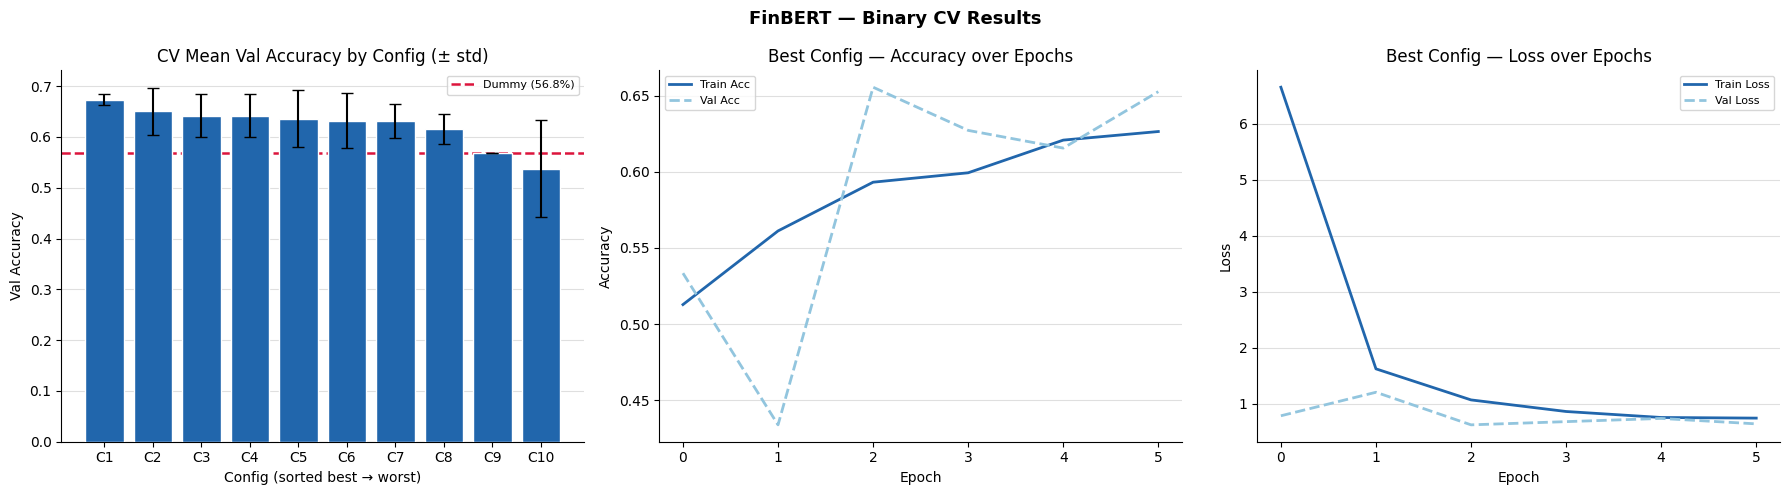

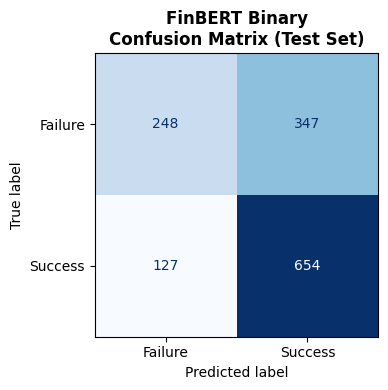

              precision    recall  f1-score   support

     Failure       0.66      0.42      0.51       595
     Success       0.65      0.84      0.73       781

    accuracy                           0.66      1376
   macro avg       0.66      0.63      0.62      1376
weighted avg       0.66      0.66      0.64      1376



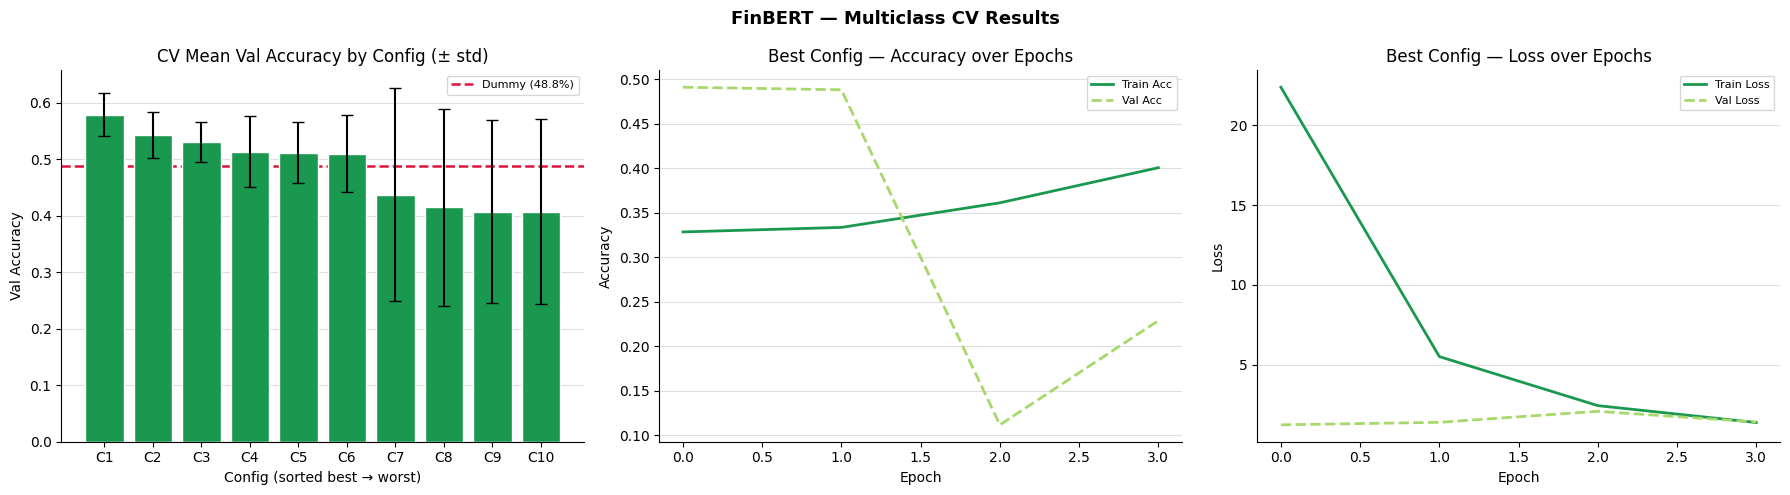

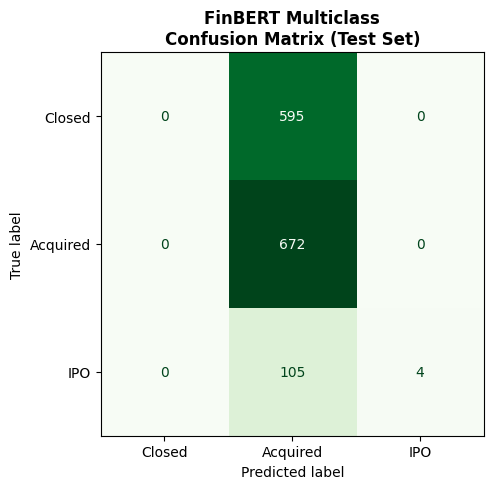

              precision    recall  f1-score   support

      Closed       0.00      0.00      0.00       595
    Acquired       0.49      1.00      0.66       672
         IPO       1.00      0.04      0.07       109

    accuracy                           0.49      1376
   macro avg       0.50      0.35      0.24      1376
weighted avg       0.32      0.49      0.33      1376



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



In [ ]:
#Plot the results.
plot_results('FinBERT')

###SEC-BERT (nlpaueb)


In this section, I try out the SEC-BERT embeddings.

In [ ]:
#Load FinBERT.
print('Loading SEC-BERT...')
secbert_model = SentenceTransformer('nlpaueb/sec-bert-base')
print('Model loaded. Encoding splits...')

#Binary encoding.

#Encode the binary about_text pool.
print('  Binary pool about...')
secbert_pool_ab = secbert_model.encode(
    X_pool_about_b.tolist(),
    show_progress_bar=True, batch_size=32)


#Encode the binary founder pool.
print('  Binary pool founder...')
secbert_pool_fb = secbert_model.encode(
    X_pool_founder_b.tolist(),
    show_progress_bar=True, batch_size=32)

#Encode the binary about_text test set.
print('  Binary test about...')
secbert_test_ab = secbert_model.encode(
    X_cg_test_about.tolist(),
    show_progress_bar=True, batch_size=32)

#Encode the binary founder test_set.
print('  Binary test founder...')
secbert_test_fb = secbert_model.encode(
    X_cg_test_founder.tolist(),
    show_progress_bar=True, batch_size=32)



#Multiclass encoding.

#Encode the multiclass about_text pool.
print('  Multiclass pool about...')
secbert_pool_am = secbert_model.encode(
    X_pool_about_m.tolist(),
    show_progress_bar=True, batch_size=32)

#Encode the multiclass founder pool.
print('  Multiclass pool founder...')
secbert_pool_fm = secbert_model.encode(
    X_pool_founder_m.tolist(),
    show_progress_bar=True, batch_size=32)

#Encode the multiclass about_text test set.
print('  Multiclass test about...')
secbert_test_am = secbert_model.encode(
    X_cg_test_about_cm.tolist(),
    show_progress_bar=True, batch_size=32)

#Encode the multiclass founder pool.
print('  Multiclass test founder...')
secbert_test_fm = secbert_model.encode(
    X_cg_test_founder_cm.tolist(),
    show_progress_bar=True, batch_size=32)

#Retrieve the SEC-BERT Dimension for keras
SECBERT_DIM = secbert_pool_ab.shape[1]
print(f'Done. Dim: {SECBERT_DIM}, '
      f'pool shape: {secbert_pool_ab.shape}')

Loading SEC-BERT...


config.json:   0%|          | 0.00/568 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/439M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: nlpaueb/sec-bert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

  Multiclass test about...


Batches:   0%|          | 0/43 [00:00<?, ?it/s]

  Multiclass test founder...


Batches:   0%|          | 0/43 [00:00<?, ?it/s]

Done. Dim: 768, pool shape: (5501, 768)


####SEC-BERT Model Builders & CV

In this section, I create the builder function for the binary and multiclass SEC-BERT models to pass into the run_cv.

In [ ]:
#Builder functions for SEC-BERT.
#Architecture is identical to the RoBERTa
#section: Dense projection layers operating
#on fixed-length sentence embeddings.
#The only difference is the input dimension
#which is read from SECBERT_DIM.

def build_binary_secbert(dense_units, num_layers,
                              dropout_rate, learning_rate,
                              activation, optimizer_name):


    #Define the input layaers for each of the branches.
    about_inp = keras.Input(
        shape=(SECBERT_DIM,), name='about_inp')
    found_inp = keras.Input(
        shape=(SECBERT_DIM,), name='founder_inp')
    strct_inp = keras.Input(
        shape=(n_structured_cg,), name='struct_inp')

    #About text branch.
    a = about_inp
    for _ in range(num_layers):
        a = layers.Dense(dense_units, activation=activation)(a)
        a = layers.Dropout(dropout_rate)(a)

    #Founder text branch.
    f = found_inp
    for _ in range(num_layers):
        f = layers.Dense(dense_units, activation=activation)(f)
        f = layers.Dropout(dropout_rate)(f)

    #Structured branch.
    s = strct_inp
    for _ in range(num_layers):
        s = layers.Dense(dense_units, activation=activation)(s)
        s = layers.Dropout(dropout_rate)(s)

    #Concatenate all 3 branches, apply an activation function
    #and output it with a sigmoid.
    m = layers.Concatenate()([a, f, s])
    m = layers.Dense(dense_units // 2, activation=activation)(m)
    out = layers.Dense(1, activation='sigmoid')(m)

    #Create the model and compile it.
    model = keras.Model(
        inputs=[about_inp, found_inp, strct_inp], outputs=out)

    model.compile(
        optimizer=get_optimizer(optimizer_name, learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy'])

    #Return the model.
    return model


def build_multi_secbert(dense_units, num_layers,
                             dropout_rate, learning_rate,
                             activation, optimizer_name):

    #Define the input layers for each of the branches.
    about_inp = keras.Input(
        shape=(SECBERT_DIM,), name='about_inp')
    found_inp = keras.Input(
        shape=(SECBERT_DIM,), name='founder_inp')
    strct_inp = keras.Input(
        shape=(n_struct_m,), name='struct_inp')

    #About text branch.
    a = about_inp
    for _ in range(num_layers):
        a = layers.Dense(dense_units, activation=activation)(a)
        a = layers.Dropout(dropout_rate)(a)

    #Founder text branch.
    f = found_inp
    for _ in range(num_layers):
        f = layers.Dense(dense_units, activation=activation)(f)
        f = layers.Dropout(dropout_rate)(f)

    #Structured branch.
    s = strct_inp
    for _ in range(num_layers):
        s = layers.Dense(dense_units, activation=activation)(s)
        s = layers.Dropout(dropout_rate)(s)

    #Merge all 3 branches, apply an activation function,
    #then output it using Softmax.
    m = layers.Concatenate()([a, f, s])
    m = layers.Dense(dense_units, activation=activation)(m)
    out = layers.Dense(3, activation='softmax')(m)

    #Create the model and compile it.
    model = keras.Model(
        inputs=[about_inp, found_inp, strct_inp], outputs=out)

    model.compile(
        optimizer=get_optimizer(optimizer_name, learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'])

    #Return the model.
    return model

print('Builders defined for SEC-BERT.')


Builders defined for SEC-BERT.


#### Run CV — SEC-BERT

In this section, I run_cv using the SEC-BERT embeddings.

In [ ]:
#Run CV for SEC-BERT.
#Builders: build_binary_secbert (binary)
#          build_multi_secbert (multiclass)
#Arrays: sentence-transformers CLS numpy
#        arrays encoded in the cell above.
#No extra builder_kwargs needed.
run_cv(
    name       = 'SEC-BERT',
    build_fn_b = build_binary_secbert,
    pool_a_b   = secbert_pool_ab,
    pool_f_b   = secbert_pool_fb,
    pool_s_b   = X_pool_struct_np,
    test_a_b   = secbert_test_ab,
    test_f_b   = secbert_test_fb,
    test_s_b   = X_test_struct_b,
    y_pool_b   = y_pool_b_np,
    y_test_b   = y_cg_test.values,
    build_fn_m = build_multi_secbert,
    pool_a_m   = secbert_pool_am,
    pool_f_m   = secbert_pool_fm,
    pool_s_m   = X_pool_struct_m_np,
    test_a_m   = secbert_test_am,
    test_f_m   = secbert_test_fm,
    test_s_m   = X_test_struct_m,
    y_pool_m   = y_pool_m_np,
    y_test_m   = y_cg_test_cm.values,
    cw_dict    = cw_dict_pool,
)



  run_cv: SEC-BERT

[SEC-BERT] Binary CV (5 folds x 10 configs)...
  [SEC-BERT] Config 01 binary -> 0.6232 ± 0.0681
  [SEC-BERT] Config 02 binary -> 0.6192 ± 0.0605
  [SEC-BERT] Config 03 binary -> 0.6186 ± 0.0629
  [SEC-BERT] Config 04 binary -> 0.6253 ± 0.0583
  [SEC-BERT] Config 05 binary -> 0.6704 ± 0.0338
  [SEC-BERT] Config 06 binary -> 0.6871 ± 0.0084
  [SEC-BERT] Config 07 binary -> 0.6393 ± 0.0593
  [SEC-BERT] Config 08 binary -> 0.5994 ± 0.0901
  [SEC-BERT] Config 09 binary -> 0.6833 ± 0.0131
  [SEC-BERT] Config 10 binary -> 0.6504 ± 0.0448

[SEC-BERT] Retraining best binary config...
Epoch 1/15
344/344 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.4968 - loss: 16.4413 - val_accuracy: 0.5676 - val_loss: 5.7706
Epoch 2/15
344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5128 - loss: 6.1593 - val_accuracy: 0.5523 - val_loss: 0.7922
Epoch 3/15
344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5401 - loss: 3.0588 - val_accuracy: 0.4658 - val_loss: 1.7501
Epoch 4/15

{'binary': {'test_acc': 0.6904,
  'test_loss': 0.5952,
  'best_config': {'dense_units': 64,
   'num_layers': 2,
   'drop_out_rate': 0.2,
   'learning_rate': 0.0003,
   'batch': 16,
   'activation_function': 'elu',
   'optimizer': 'adamw',
   'mean_val_acc': 0.6871,
   'std_val_acc': 0.0084},
  'cv_df':    dense_units  num_layers  drop_out_rate  learning_rate  batch  \
  0           64           2            0.2         0.0003     16   
  1           64           1            0.2         0.0010     32   
  2          128           1            0.2         0.0010     16   
  3          128           1            0.4         0.0003     16   
  4           32           1            0.4         0.0010     32   
  5           64           2            0.4         0.0010     32   
  6           32           1            0.2         0.0010     16   
  7           64           1            0.4         0.0003     32   
  8           32           2            0.2         0.0003     16   
  9     

####Plot the Results

In this section, I plotted the results of the cross validation using SEC-BERT.

<br>

In terms of the binary model, its accuracy is 69% on par with RoBERTa and Rnadom Init as top performers. More importantly, it strikes the best balance on recall, with 67% on Failure and 70% on Success, better balanced than RoBERTa. The training curve is also promising, with both train and validation accuracy steadily increasing all the way to epoch 14. This suggests that SEC-BERT's pre-training on SEC filings translates reasonably well to startup langauge.

<br>

Moving to the Multiclass model, it achived a 61% accuracy, second to RoBERTa's 62%, and shows the best IPO detection of any model with 35% recall, a meaningful improvement over other models.
However, the training curve is the most volatile so far, with validation accuracy reaching 61% around epoch 3 then crashing down dramatcially before recovering, suggesting that the model is sensitive to the specific configurations. The closed class is  at 47% recall with Acquired dominating at 78%.  

Overall, SEC-BERT shows the strongest multiclass performance so far, with its more balanced results, especially with the IPO detection. Moreover, its binary results are quite balanced, making this a suitable option for VC firms.

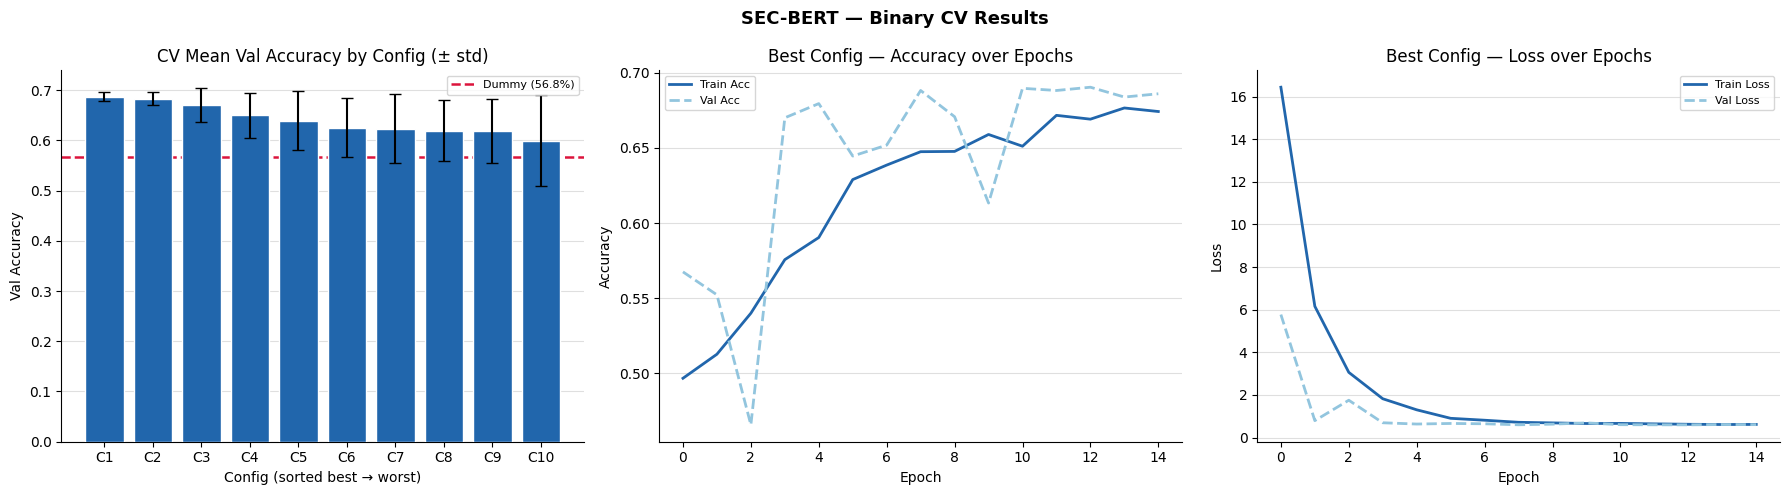

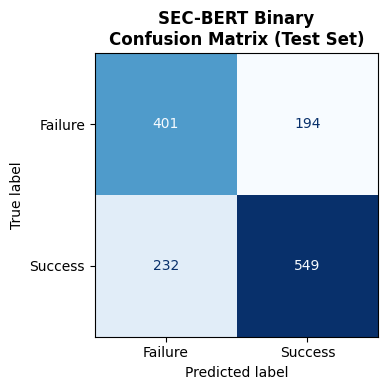

              precision    recall  f1-score   support

     Failure       0.63      0.67      0.65       595
     Success       0.74      0.70      0.72       781

    accuracy                           0.69      1376
   macro avg       0.69      0.69      0.69      1376
weighted avg       0.69      0.69      0.69      1376



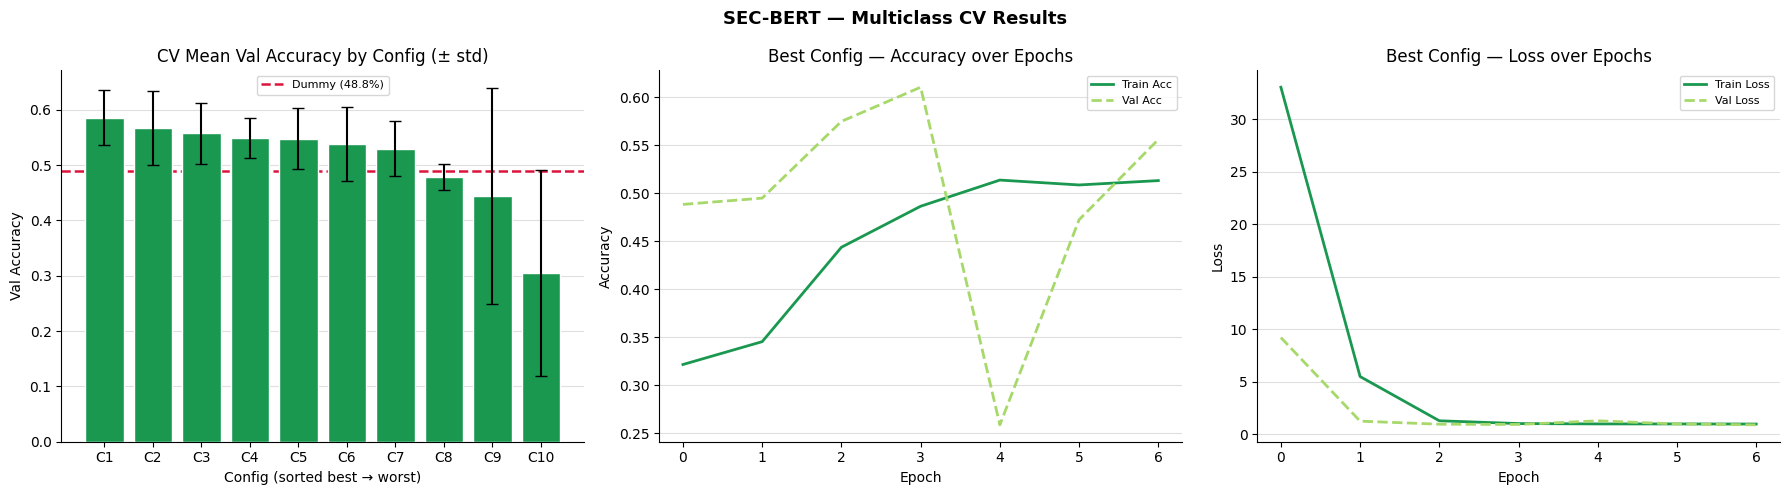

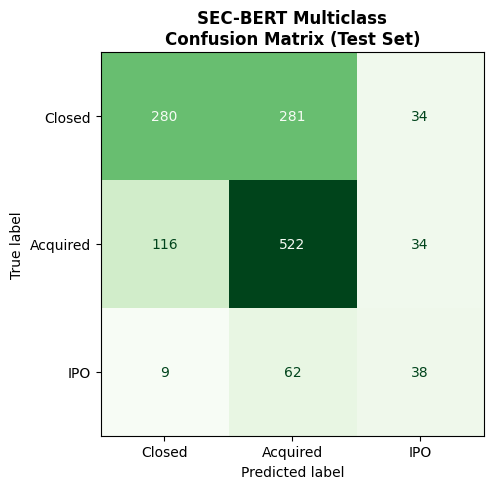

              precision    recall  f1-score   support

      Closed       0.69      0.47      0.56       595
    Acquired       0.60      0.78      0.68       672
         IPO       0.36      0.35      0.35       109

    accuracy                           0.61      1376
   macro avg       0.55      0.53      0.53      1376
weighted avg       0.62      0.61      0.60      1376



In [ ]:
#Plot the results
plot_results('SEC-BERT')

###FinancialBERT (ahmedrachid)


In this section, I try out the FinancialBERT embeddings.

In [ ]:
#Load FinancialBERT
print('Loading FinancialBERT...')
finbert2_model = SentenceTransformer('ahmedrachid/FinancialBERT')
print('Model loaded. Encoding splits...')

#Binary encoding.

#Encode the binary about_text pool.
print('  Binary pool about...')
finbert2_pool_ab = finbert2_model.encode(
    X_pool_about_b.tolist(),
    show_progress_bar=True, batch_size=32)


#Encode the binary founder pool.
print('  Binary pool founder...')
finbert2_pool_fb = finbert2_model.encode(
    X_pool_founder_b.tolist(),
    show_progress_bar=True, batch_size=32)

#Encode the binary founder test set.
print('  Binary test about...')
finbert2_test_ab = finbert2_model.encode(
    X_cg_test_about.tolist(),
    show_progress_bar=True, batch_size=32)

#Encode the binary founder test set.
print('  Binary test founder...')
finbert2_test_fb = finbert2_model.encode(
    X_cg_test_founder.tolist(),
    show_progress_bar=True, batch_size=32)


#Multiclass encoding.

#Encode the multiclass about_text pool.
print('  Multiclass pool about...')
finbert2_pool_am = finbert2_model.encode(
    X_pool_about_m.tolist(),
    show_progress_bar=True, batch_size=32)

#Encode the multiclass founder pool.
print('  Multiclass pool founder...')
finbert2_pool_fm = finbert2_model.encode(
    X_pool_founder_m.tolist(),
    show_progress_bar=True, batch_size=32)

#Encode the multiclass about_text test set.
print('  Multiclass test about...')
finbert2_test_am = finbert2_model.encode(
    X_cg_test_about_cm.tolist(),
    show_progress_bar=True, batch_size=32)

#Encode the multiclass founder test set.
print('  Multiclass test founder...')
finbert2_test_fm = finbert2_model.encode(
    X_cg_test_founder_cm.tolist(),
    show_progress_bar=True, batch_size=32)

##Retrieve the SEC-BERT Dimension for keras.
FINBERT2_DIM = finbert2_pool_ab.shape[1]
print(f'Done. Dim: {FINBERT2_DIM}, '
      f'pool shape: {finbert2_pool_ab.shape}')

Loading FinancialBERT...


config.json:   0%|          | 0.00/589 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/439M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: ahmedrachid/FinancialBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstr

...

  Multiclass test about...


Batches:   0%|          | 0/43 [00:00<?, ?it/s]

  Multiclass test founder...


Batches:   0%|          | 0/43 [00:00<?, ?it/s]

Done. Dim: 768, pool shape: (5501, 768)


####FinancialBERT Model Builders & CV

In this section, I create the builder function for the binary and multiclass FinancialBERT models to pass into the run_cv.

In [ ]:
#Builder functions for FinancialBERT.
#Architecture is identical to the RoBERTa
#section: Dense projection layers operating
#on fixed-length sentence embeddings.
#The only difference is the input dimension
#which is read from FINBERT2_DIM.

def build_binary_finbert2(dense_units, num_layers,
                              dropout_rate, learning_rate,
                              activation, optimizer_name):

    #Define the inptus for each of the branches.
    about_inp = keras.Input(
        shape=(FINBERT2_DIM,), name='about_inp')
    found_inp = keras.Input(
        shape=(FINBERT2_DIM,), name='founder_inp')
    strct_inp = keras.Input(
        shape=(n_structured_cg,), name='struct_inp')

    #About text branch.
    a = about_inp
    for _ in range(num_layers):
        a = layers.Dense(dense_units, activation=activation)(a)
        a = layers.Dropout(dropout_rate)(a)

    #Founder text branch.
    f = found_inp
    for _ in range(num_layers):
        f = layers.Dense(dense_units, activation=activation)(f)
        f = layers.Dropout(dropout_rate)(f)

    #Structured branch.
    s = strct_inp
    for _ in range(num_layers):
        s = layers.Dense(dense_units, activation=activation)(s)
        s = layers.Dropout(dropout_rate)(s)

    #Merge all 3 branhces.
    m = layers.Concatenate()([a, f, s])
    m = layers.Dense(dense_units // 2, activation=activation)(m)
    out = layers.Dense(1, activation='sigmoid')(m)

    #Create the Keras model and compile it.
    model = keras.Model(
        inputs=[about_inp, found_inp, strct_inp], outputs=out)

    model.compile(
        optimizer=get_optimizer(optimizer_name, learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy'])

    #Return the model.
    return model


def build_multi_finbert2(dense_units, num_layers,
                             dropout_rate, learning_rate,
                             activation, optimizer_name):

    #Define the inputs for all 3 branches.
    about_inp = keras.Input(
        shape=(FINBERT2_DIM,), name='about_inp')
    found_inp = keras.Input(
        shape=(FINBERT2_DIM,), name='founder_inp')
    strct_inp = keras.Input(
        shape=(n_struct_m,), name='struct_inp')

    #The About text branch.
    a = about_inp
    for _ in range(num_layers):
        a = layers.Dense(dense_units, activation=activation)(a)
        a = layers.Dropout(dropout_rate)(a)

    #The founder text branch.
    f = found_inp
    for _ in range(num_layers):
        f = layers.Dense(dense_units, activation=activation)(f)
        f = layers.Dropout(dropout_rate)(f)

    #The structured branch.
    s = strct_inp
    for _ in range(num_layers):
        s = layers.Dense(dense_units, activation=activation)(s)
        s = layers.Dropout(dropout_rate)(s)

    #Merge all 3 branches together, apply an activation,
    #then output using softmax.
    m = layers.Concatenate()([a, f, s])
    m = layers.Dense(dense_units, activation=activation)(m)
    out = layers.Dense(3, activation='softmax')(m)

    #Create the Model and compile it.
    model = keras.Model(
        inputs=[about_inp, found_inp, strct_inp], outputs=out)

    model.compile(
        optimizer=get_optimizer(optimizer_name, learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'])

    #Return the model.
    return model

print('Builders defined for FinancialBERT.')

Builders defined for FinancialBERT.


#### Run CV — FinancialBERT

In this section, I run_cv using the FinancialBERT embeddings.

In [ ]:
#Run CV for FinancialBERT.
#Builders: build_binary_finbert2 (binary)
#          build_multi_finbert2 (multiclass)
#Arrays: sentence-transformers CLS numpy
#        arrays encoded in the cell above.
#No extra builder_kwargs needed.
run_cv(
    name       = 'FinancialBERT',
    build_fn_b = build_binary_finbert2,
    pool_a_b   = finbert2_pool_ab,
    pool_f_b   = finbert2_pool_fb,
    pool_s_b   = X_pool_struct_np,
    test_a_b   = finbert2_test_ab,
    test_f_b   = finbert2_test_fb,
    test_s_b   = X_test_struct_b,
    y_pool_b   = y_pool_b_np,
    y_test_b   = y_cg_test.values,
    build_fn_m = build_multi_finbert2,
    pool_a_m   = finbert2_pool_am,
    pool_f_m   = finbert2_pool_fm,
    pool_s_m   = X_pool_struct_m_np,
    test_a_m   = finbert2_test_am,
    test_f_m   = finbert2_test_fm,
    test_s_m   = X_test_struct_m,
    y_pool_m   = y_pool_m_np,
    y_test_m   = y_cg_test_cm.values,
    cw_dict    = cw_dict_pool,
)



  run_cv: FinancialBERT

[FinancialBERT] Binary CV (5 folds x 10 configs)...
  [FinancialBERT] Config 01 binary -> 0.6530 ± 0.0453
  [FinancialBERT] Config 02 binary -> 0.6019 ± 0.0947
  [FinancialBERT] Config 03 binary -> 0.6324 ± 0.0540
  [FinancialBERT] Config 04 binary -> 0.6203 ± 0.0285
  [FinancialBERT] Config 05 binary -> 0.6650 ± 0.0226
  [FinancialBERT] Config 06 binary -> 0.6717 ± 0.0248
  [FinancialBERT] Config 07 binary -> 0.6399 ± 0.0371
  [FinancialBERT] Config 08 binary -> 0.6342 ± 0.0543
  [FinancialBERT] Config 09 binary -> 0.6808 ± 0.0130
  [FinancialBERT] Config 10 binary -> 0.6286 ± 0.0500

[FinancialBERT] Retraining best binary config...
Epoch 1/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.5141 - loss: 22.8677 - val_accuracy: 0.4331 - val_loss: 1.2464
Epoch 2/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5417 - loss: 3.1603 - val_accuracy: 0.4331 - val_loss: 1.6606
Epoch 3/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5775 - l

{'binary': {'test_acc': 0.6635,
  'test_loss': 0.6313,
  'best_config': {'dense_units': 64,
   'num_layers': 1,
   'drop_out_rate': 0.2,
   'learning_rate': 0.001,
   'batch': 32,
   'activation_function': 'elu',
   'optimizer': 'adamw',
   'mean_val_acc': 0.6808,
   'std_val_acc': 0.013},
  'cv_df':    dense_units  num_layers  drop_out_rate  learning_rate  batch  \
  0           64           1            0.2         0.0010     32   
  1           64           2            0.2         0.0003     16   
  2          128           1            0.2         0.0010     16   
  3           32           1            0.2         0.0010     16   
  4           32           1            0.4         0.0010     32   
  5          128           2            0.4         0.0003     32   
  6           32           2            0.2         0.0003     16   
  7          128           1            0.4         0.0003     16   
  8           64           2            0.4         0.0010     32   
  9       

####Plot the Results

In this section, I plot the cross validation results for the FinancialBERT model.


<br>
Beggining with the Binary Model, the accuracy was around 66%. The recall shows a similarity with FinBERT, with 88% recall on Success and only 37% on Failure, the worst Failure recall of any model. The confusion matrix shows this with 373 out of 595 actual failures called successes. Considering that this and FinBERT were both trained on financial text, this bias towards success could be the results of the financial domain pre-training rather than a quirk of a specific model. The training curve also shows a concerning pattern with validation accuracy peaking around epochs 4-5 then staring to decline, indicating that the model is starting to overfit even within its limited epochs.


<br>
When it comes to the multiclass model, it gota n accuracy of 56%, below both RoBERTa and SEC-BERT and shows a dramatic Acquired bias - 93%, but only 23% and 16% on Close and IPO respectively. The training curve here is unstable, with validation accuracy swinging wildly between epochs, which would explain the relatively high variance in the CV bar chart.

<br>
Overall, FinancialBERT performs most inconsistently across both tasks, and alongside regular FinBERT, suggests that financial domain pre-training may actually hurt more than help when the text source is startup About Me pages rather than formal financial documents.

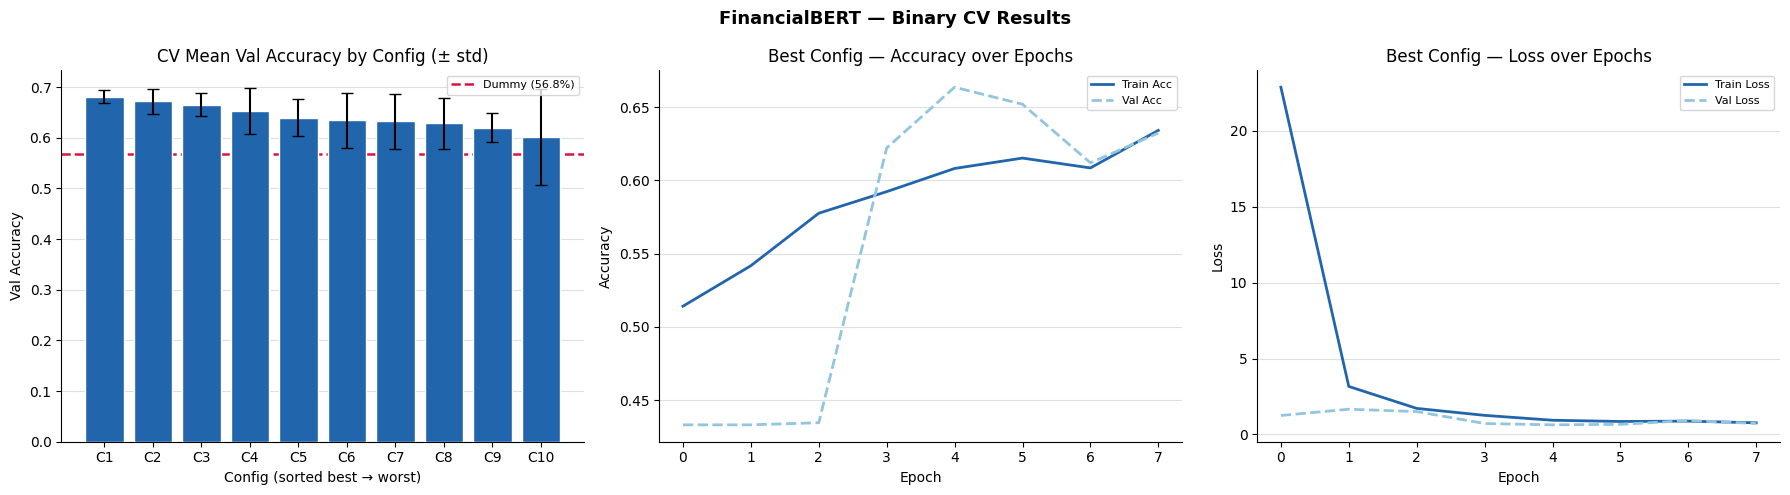

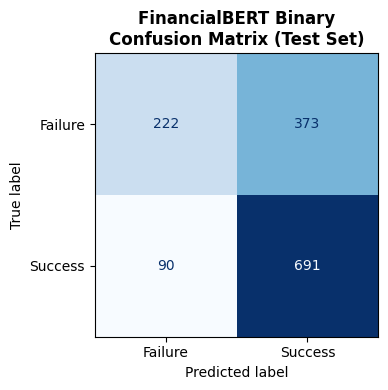

              precision    recall  f1-score   support

     Failure       0.71      0.37      0.49       595
     Success       0.65      0.88      0.75       781

    accuracy                           0.66      1376
   macro avg       0.68      0.63      0.62      1376
weighted avg       0.68      0.66      0.64      1376



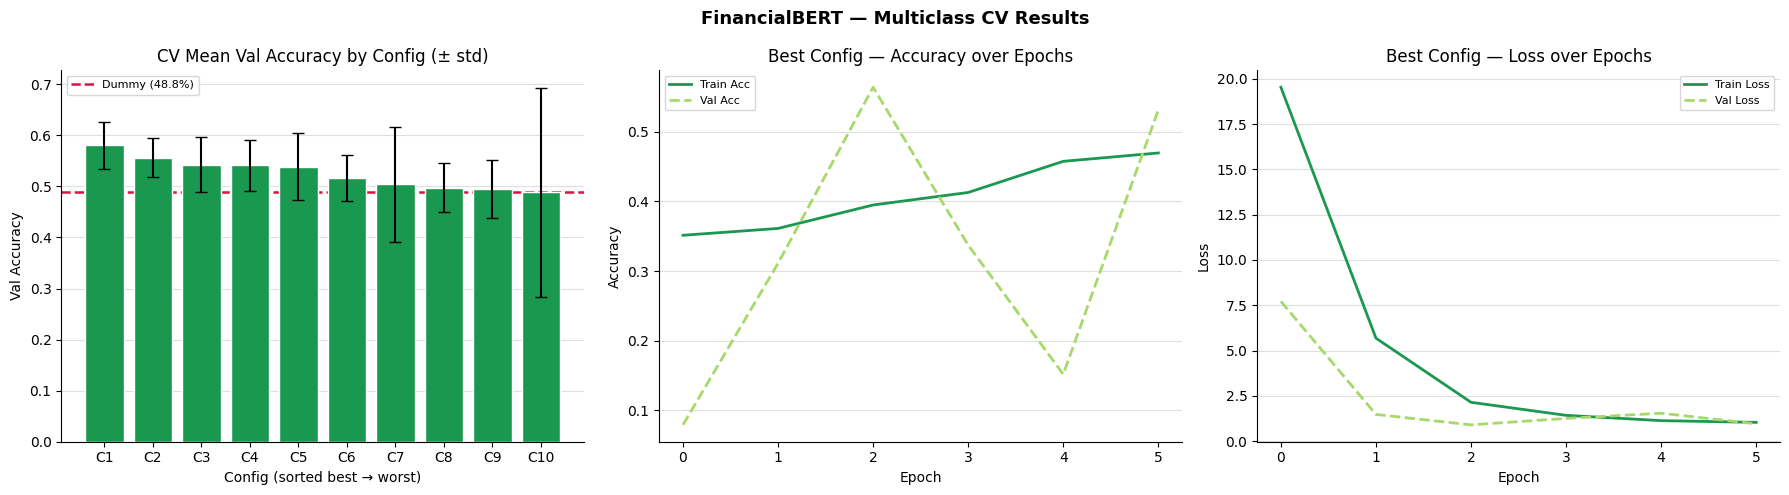

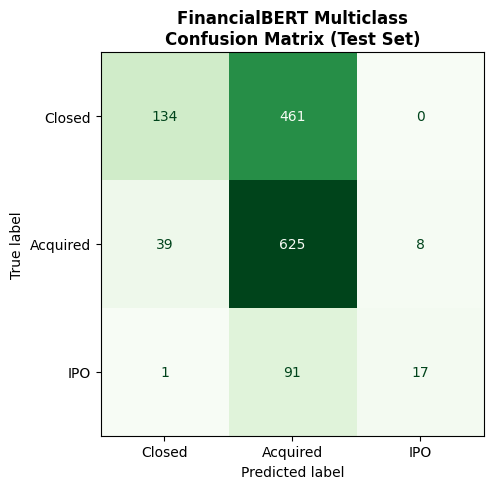

              precision    recall  f1-score   support

      Closed       0.77      0.23      0.35       595
    Acquired       0.53      0.93      0.68       672
         IPO       0.68      0.16      0.25       109

    accuracy                           0.56      1376
   macro avg       0.66      0.44      0.43      1376
weighted avg       0.65      0.56      0.50      1376



In [ ]:
#Plot the results
plot_results('FinancialBERT')

---
## Results


This section serves to summarize all the results across the models in this notebook.

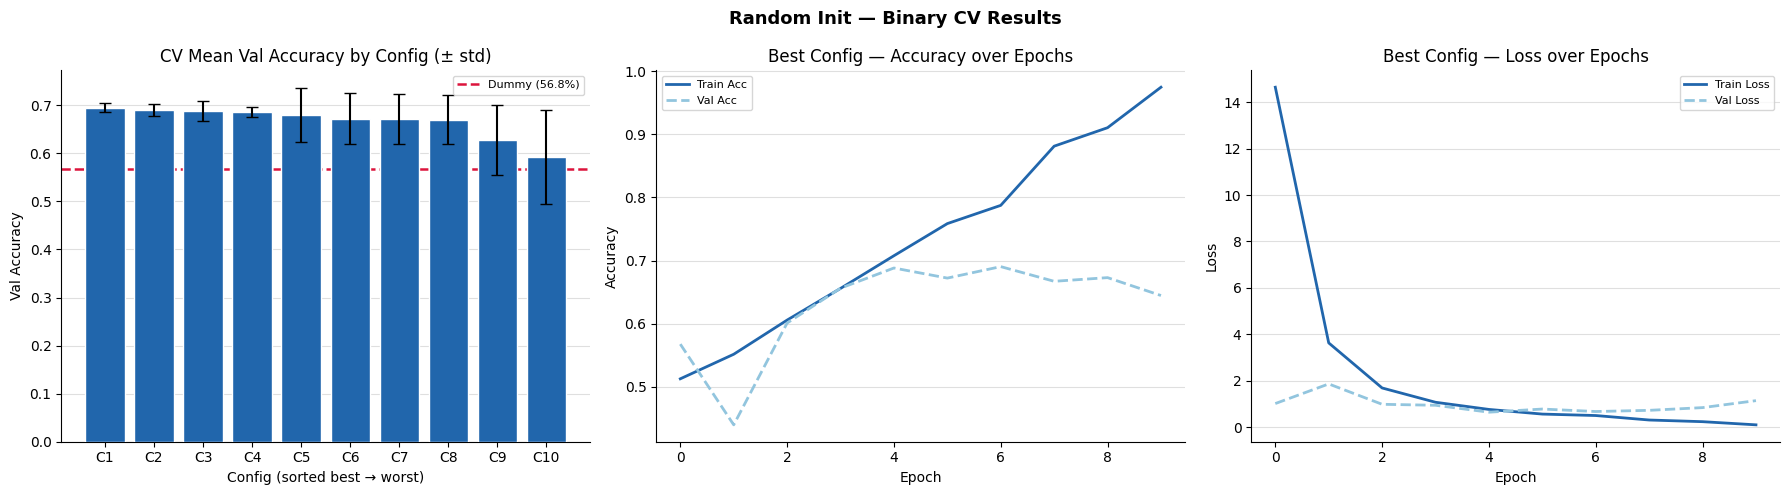

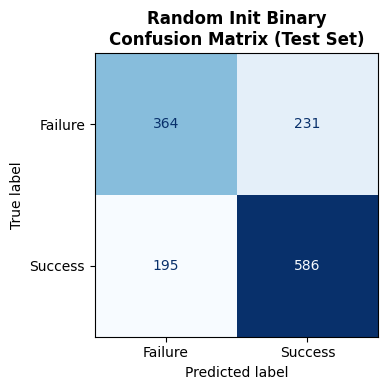

              precision    recall  f1-score   support

     Failure       0.65      0.61      0.63       595
     Success       0.72      0.75      0.73       781

    accuracy                           0.69      1376
   macro avg       0.68      0.68      0.68      1376
weighted avg       0.69      0.69      0.69      1376



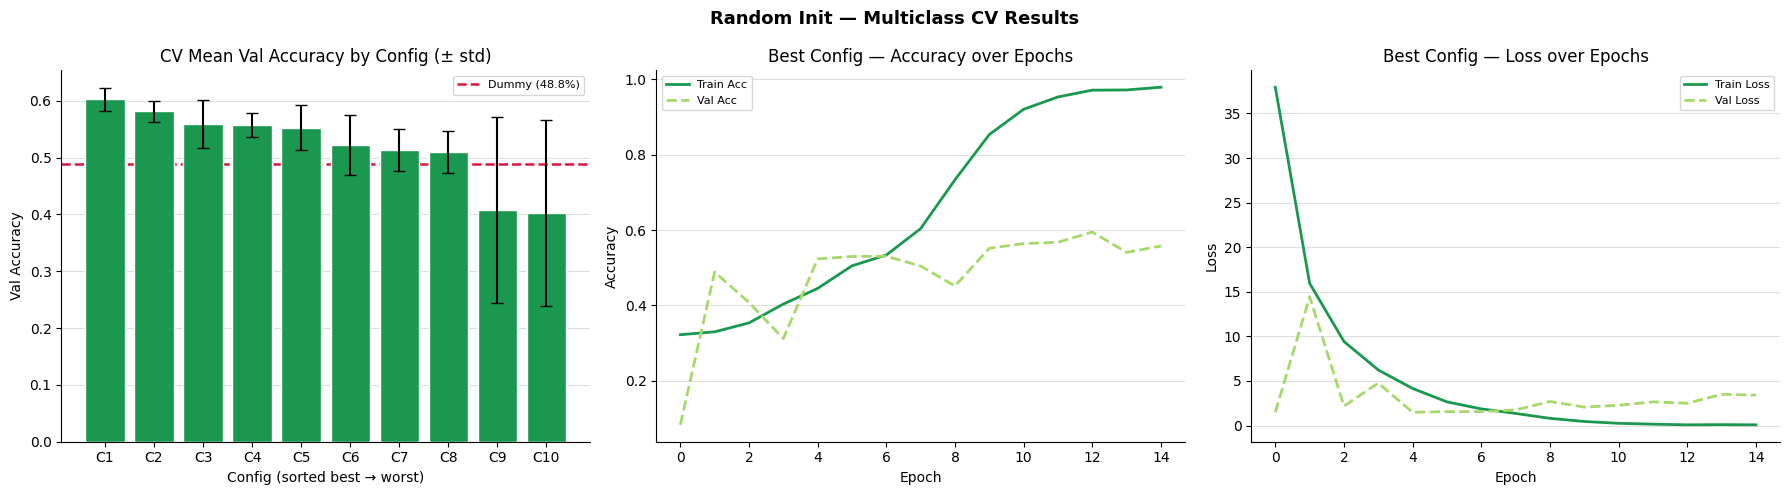

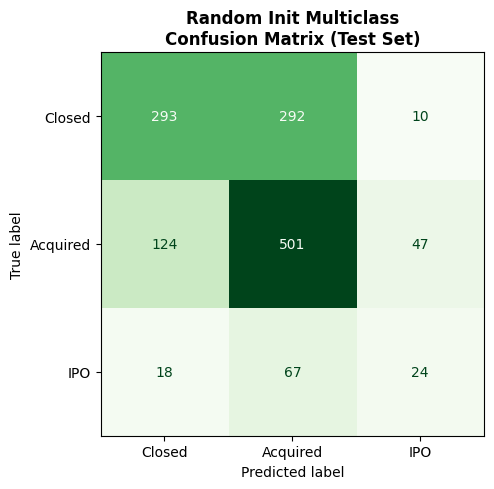

              precision    recall  f1-score   support

      Closed       0.67      0.49      0.57       595
    Acquired       0.58      0.75      0.65       672
         IPO       0.30      0.22      0.25       109

    accuracy                           0.59      1376
   macro avg       0.52      0.49      0.49      1376
weighted avg       0.60      0.59      0.59      1376



In [ ]:
#This cell is to check a specific embeddings results.
#Just input the appropriate key into the plot_results function.
plot_results('Random Init')


--- Random Init ---


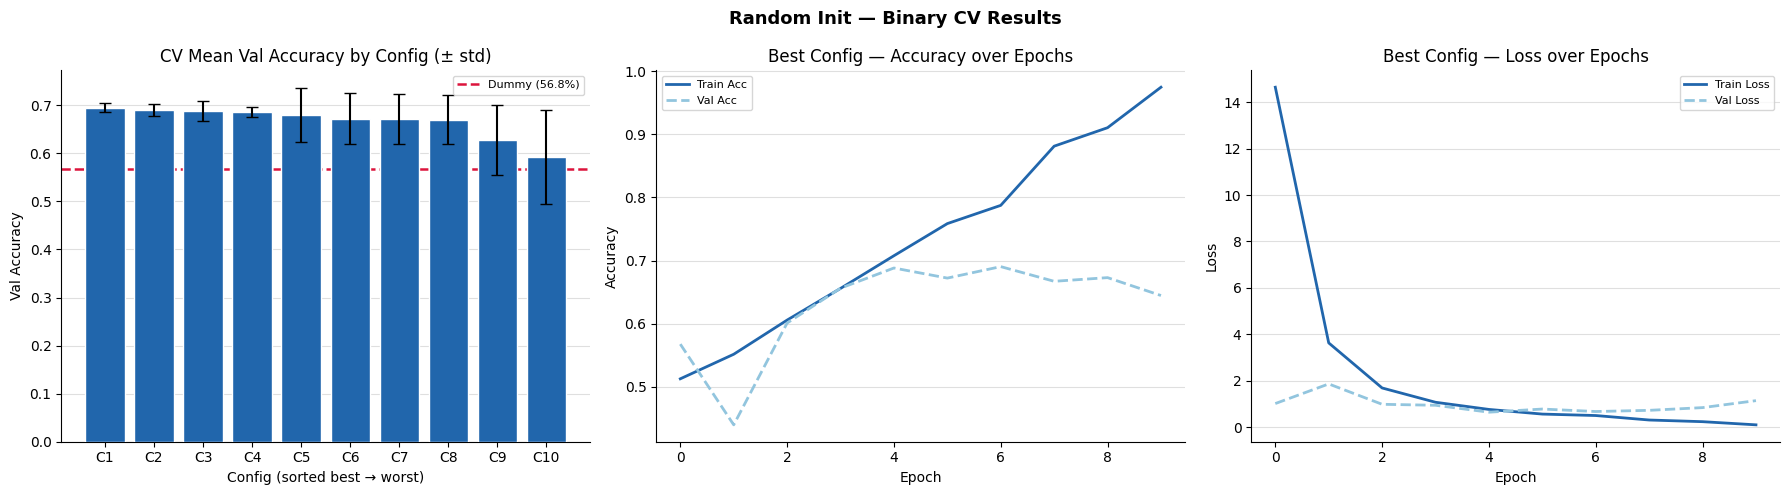

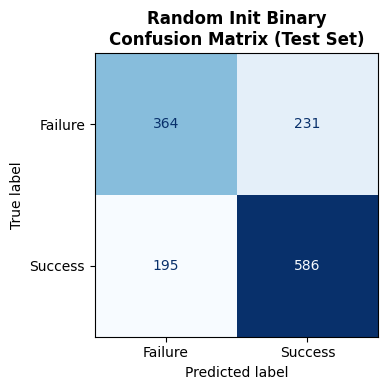

              precision    recall  f1-score   support

     Failure       0.65      0.61      0.63       595
     Success       0.72      0.75      0.73       781

    accuracy                           0.69      1376
   macro avg       0.68      0.68      0.68      1376
weighted avg       0.69      0.69      0.69      1376



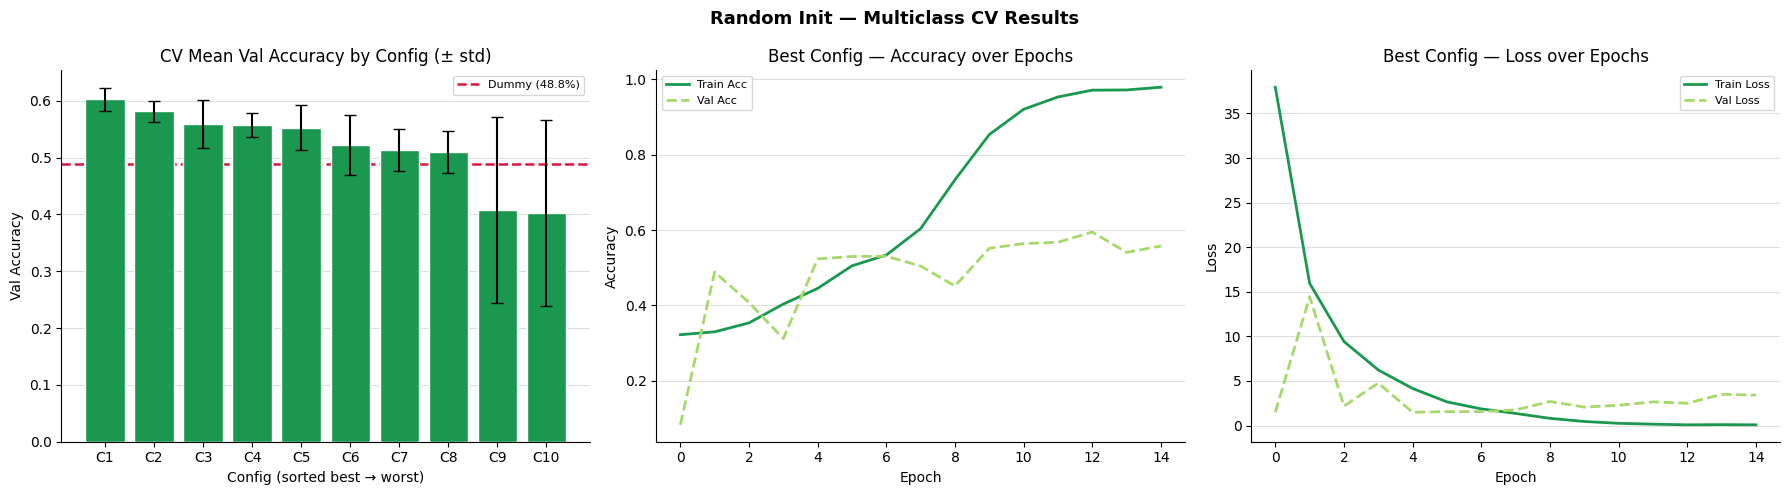

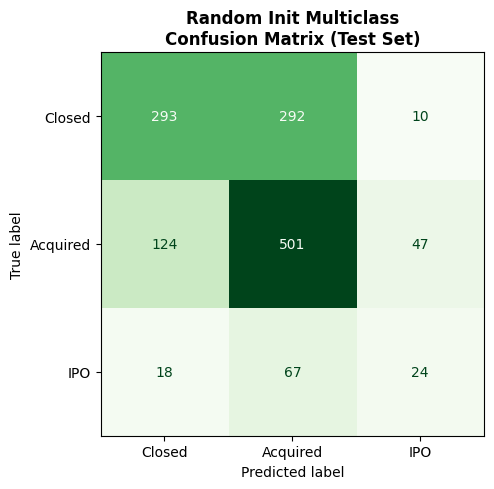

              precision    recall  f1-score   support

      Closed       0.67      0.49      0.57       595
    Acquired       0.58      0.75      0.65       672
         IPO       0.30      0.22      0.25       109

    accuracy                           0.59      1376
   macro avg       0.52      0.49      0.49      1376
weighted avg       0.60      0.59      0.59      1376


--- Word2Vec ---


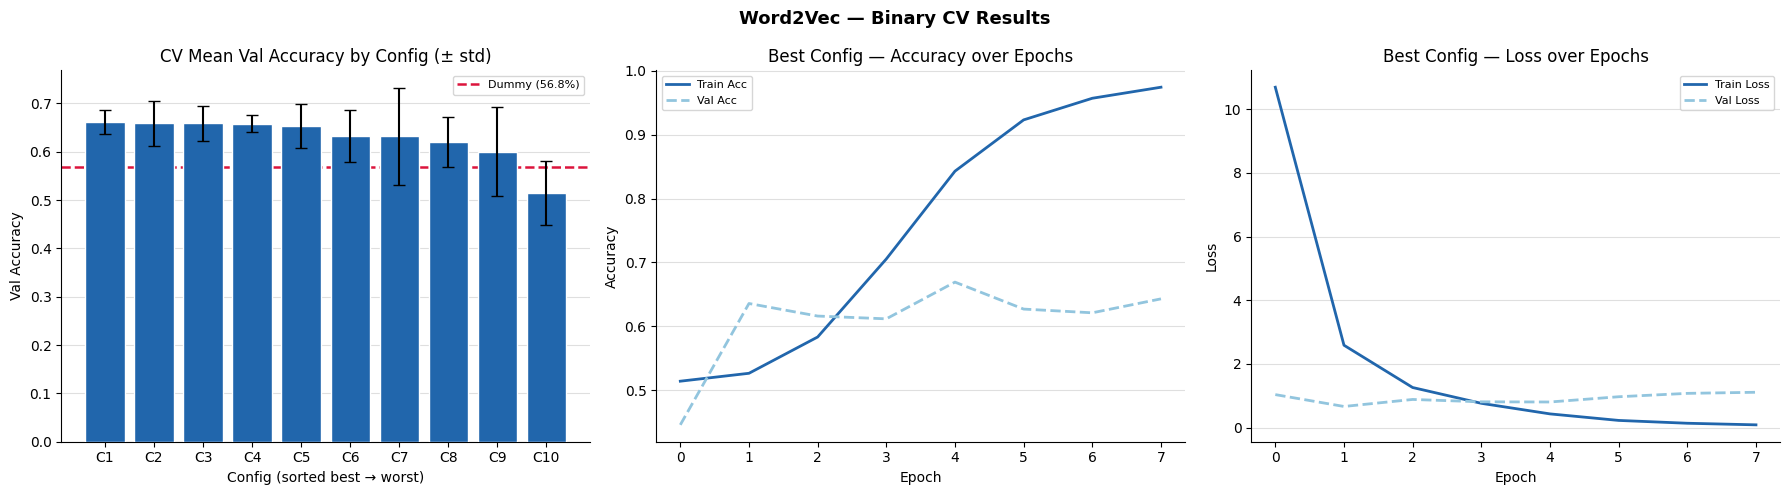

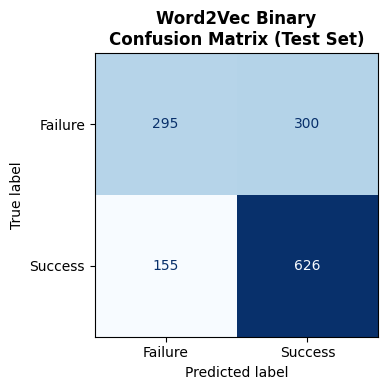

              precision    recall  f1-score   support

     Failure       0.66      0.50      0.56       595
     Success       0.68      0.80      0.73       781

    accuracy                           0.67      1376
   macro avg       0.67      0.65      0.65      1376
weighted avg       0.67      0.67      0.66      1376



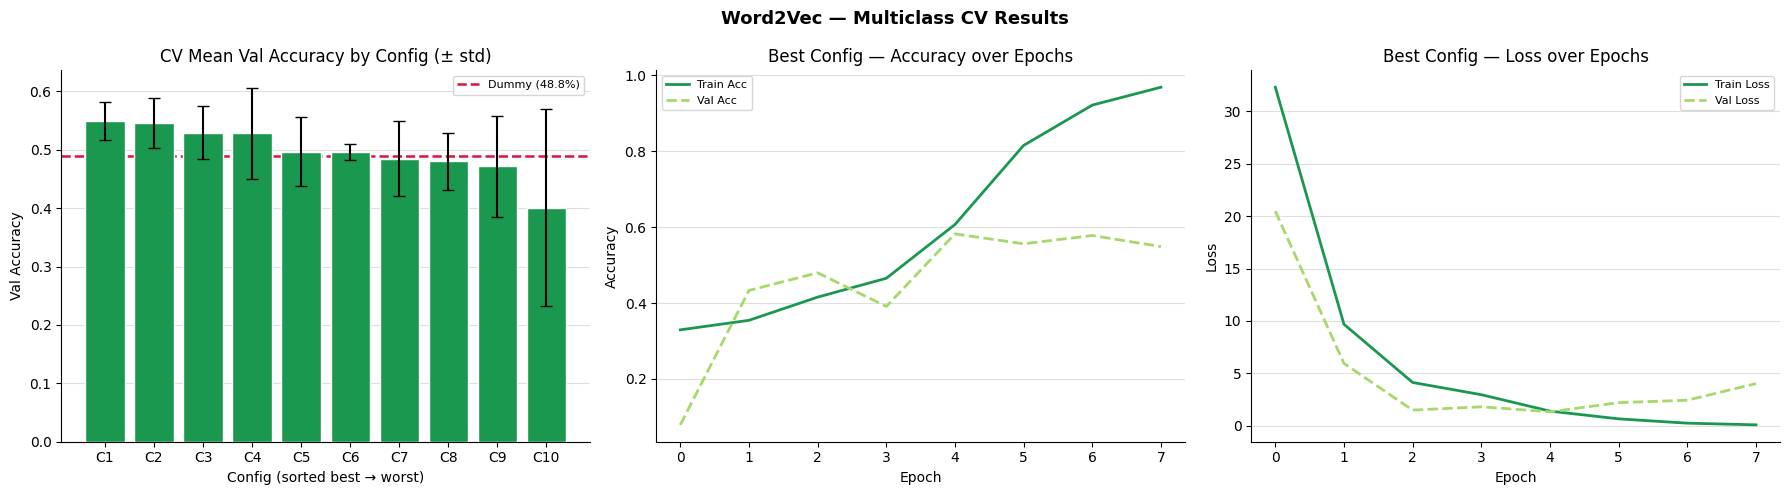

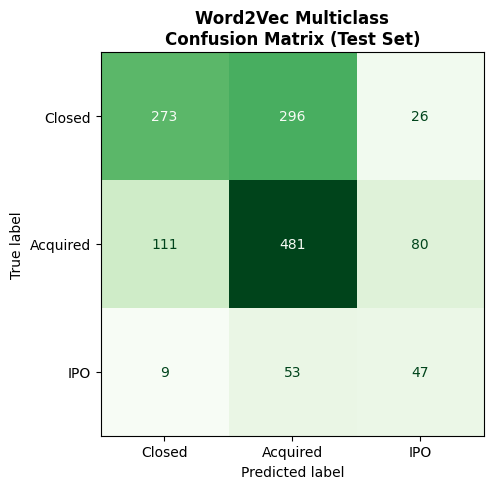

              precision    recall  f1-score   support

      Closed       0.69      0.46      0.55       595
    Acquired       0.58      0.72      0.64       672
         IPO       0.31      0.43      0.36       109

    accuracy                           0.58      1376
   macro avg       0.53      0.54      0.52      1376
weighted avg       0.61      0.58      0.58      1376


--- RoBERTa ---


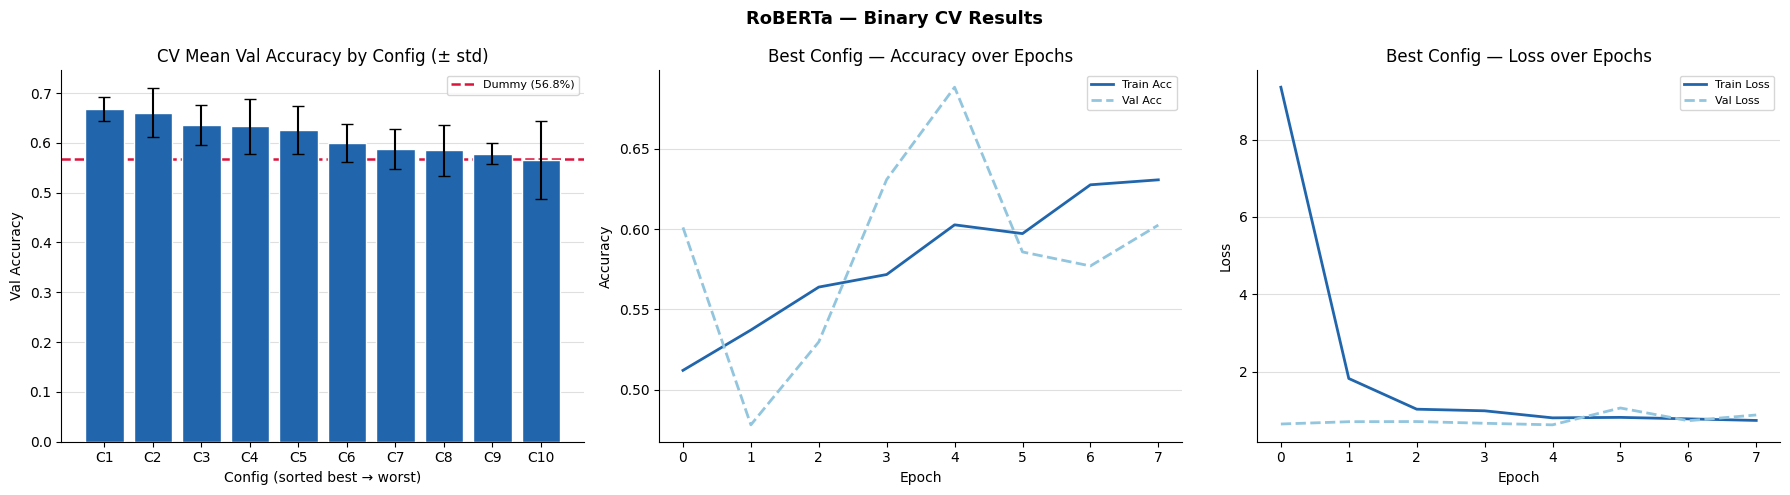

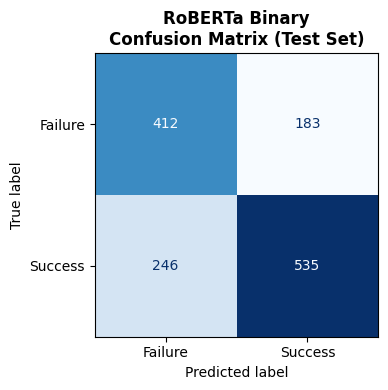

              precision    recall  f1-score   support

     Failure       0.63      0.69      0.66       595
     Success       0.75      0.69      0.71       781

    accuracy                           0.69      1376
   macro avg       0.69      0.69      0.69      1376
weighted avg       0.69      0.69      0.69      1376



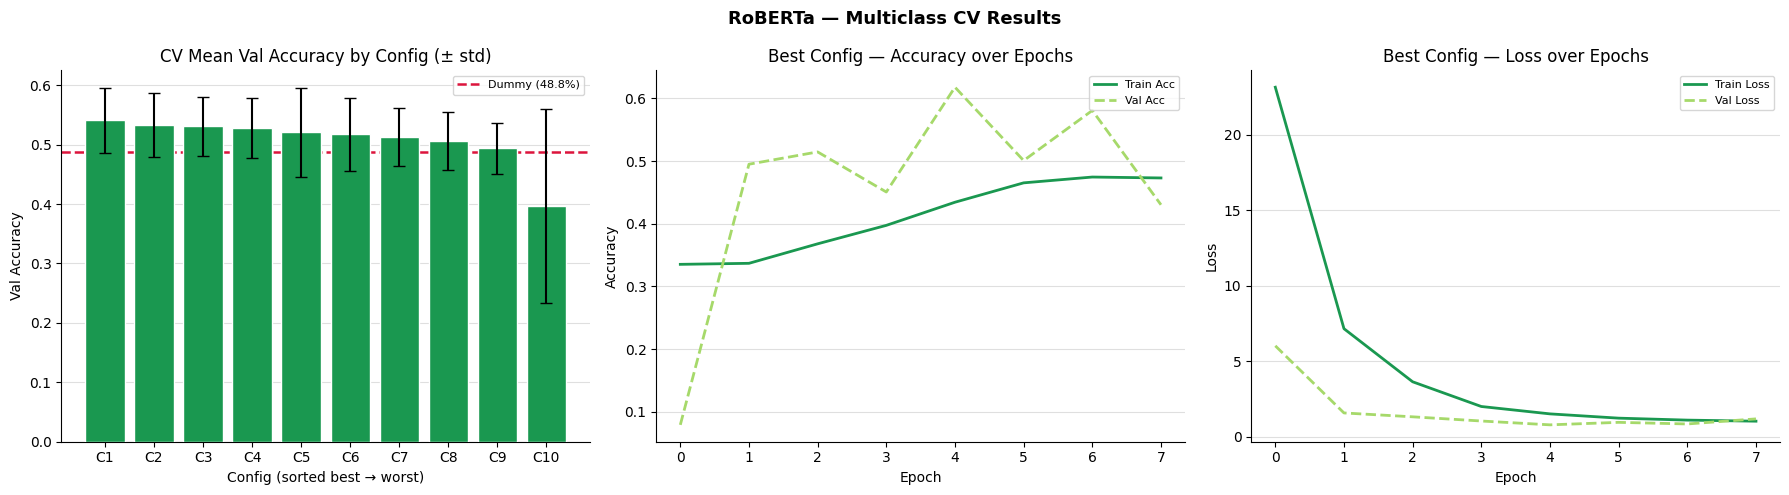

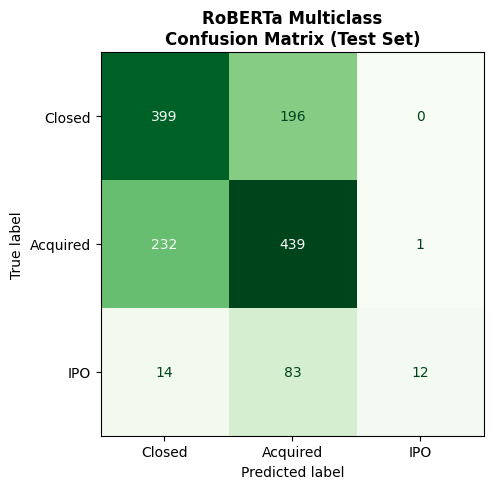

              precision    recall  f1-score   support

      Closed       0.62      0.67      0.64       595
    Acquired       0.61      0.65      0.63       672
         IPO       0.92      0.11      0.20       109

    accuracy                           0.62      1376
   macro avg       0.72      0.48      0.49      1376
weighted avg       0.64      0.62      0.60      1376


--- FinBERT ---


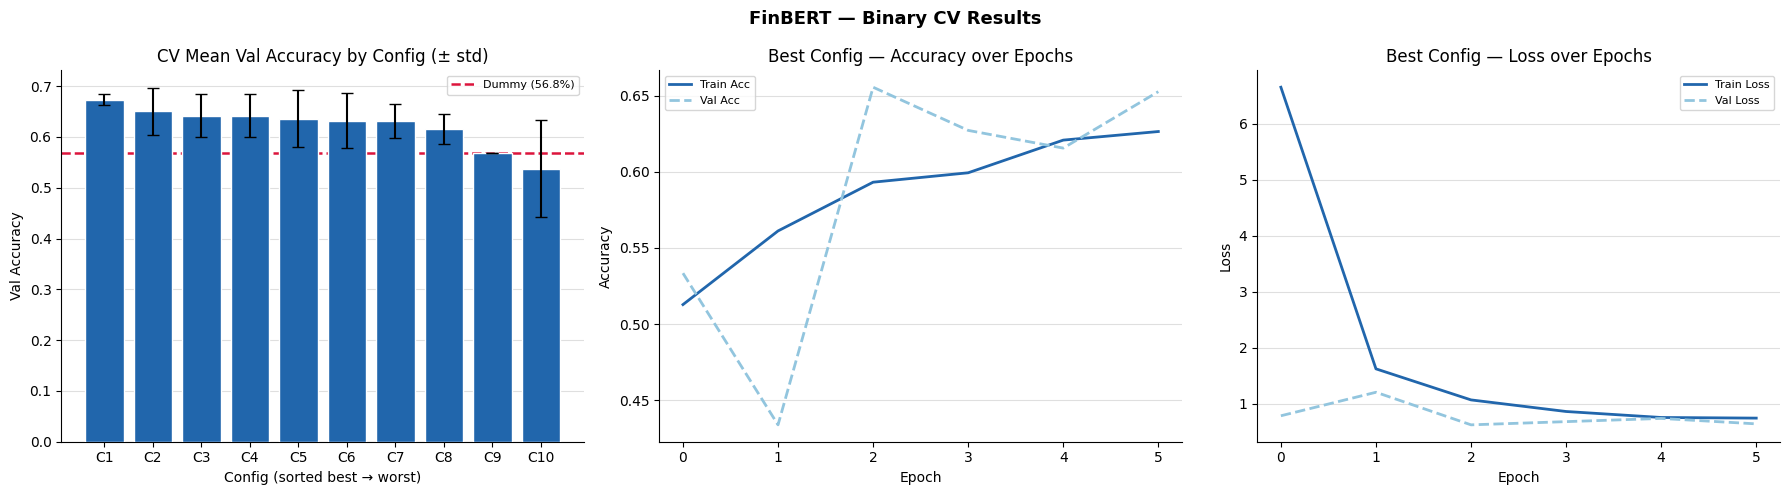

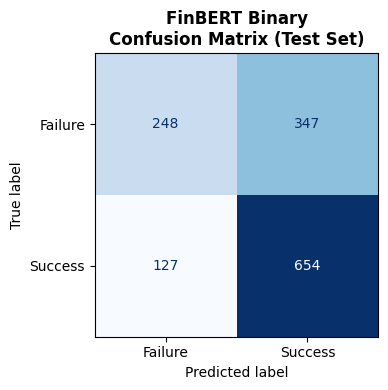

              precision    recall  f1-score   support

     Failure       0.66      0.42      0.51       595
     Success       0.65      0.84      0.73       781

    accuracy                           0.66      1376
   macro avg       0.66      0.63      0.62      1376
weighted avg       0.66      0.66      0.64      1376



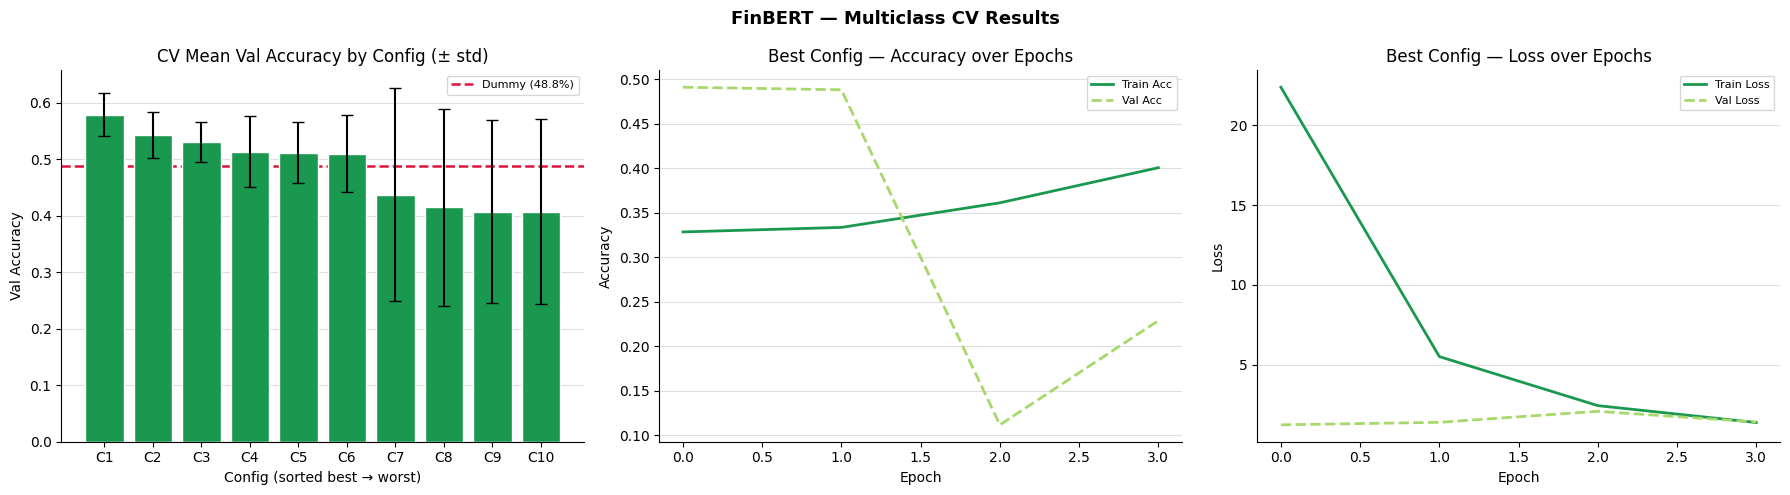

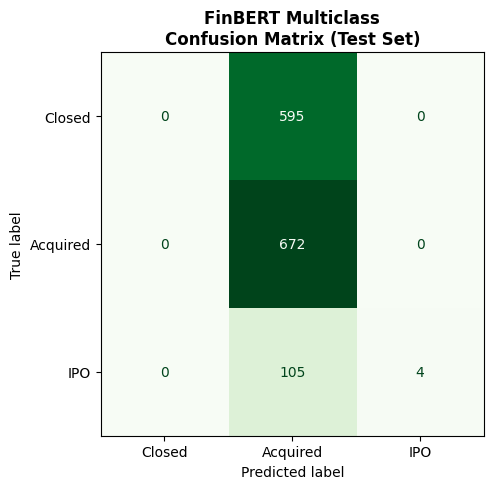

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



              precision    recall  f1-score   support

      Closed       0.00      0.00      0.00       595
    Acquired       0.49      1.00      0.66       672
         IPO       1.00      0.04      0.07       109

    accuracy                           0.49      1376
   macro avg       0.50      0.35      0.24      1376
weighted avg       0.32      0.49      0.33      1376


--- SEC-BERT ---


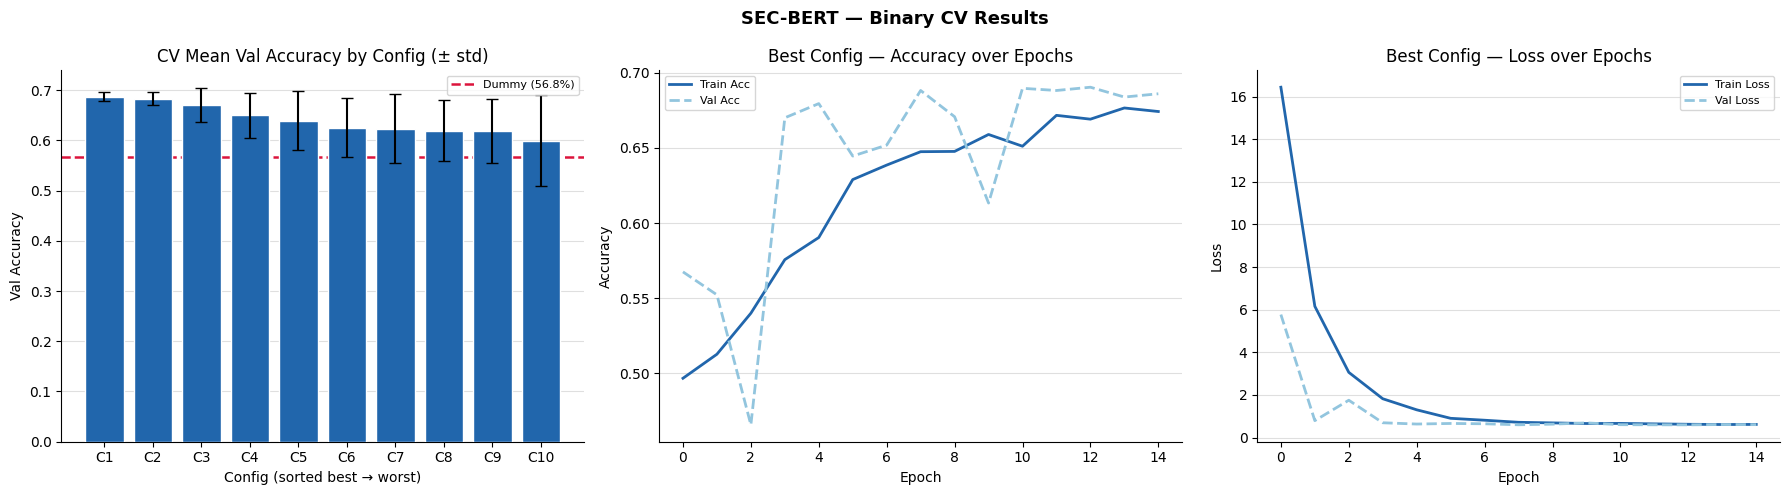

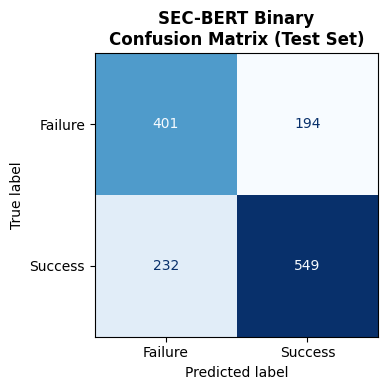

              precision    recall  f1-score   support

     Failure       0.63      0.67      0.65       595
     Success       0.74      0.70      0.72       781

    accuracy                           0.69      1376
   macro avg       0.69      0.69      0.69      1376
weighted avg       0.69      0.69      0.69      1376



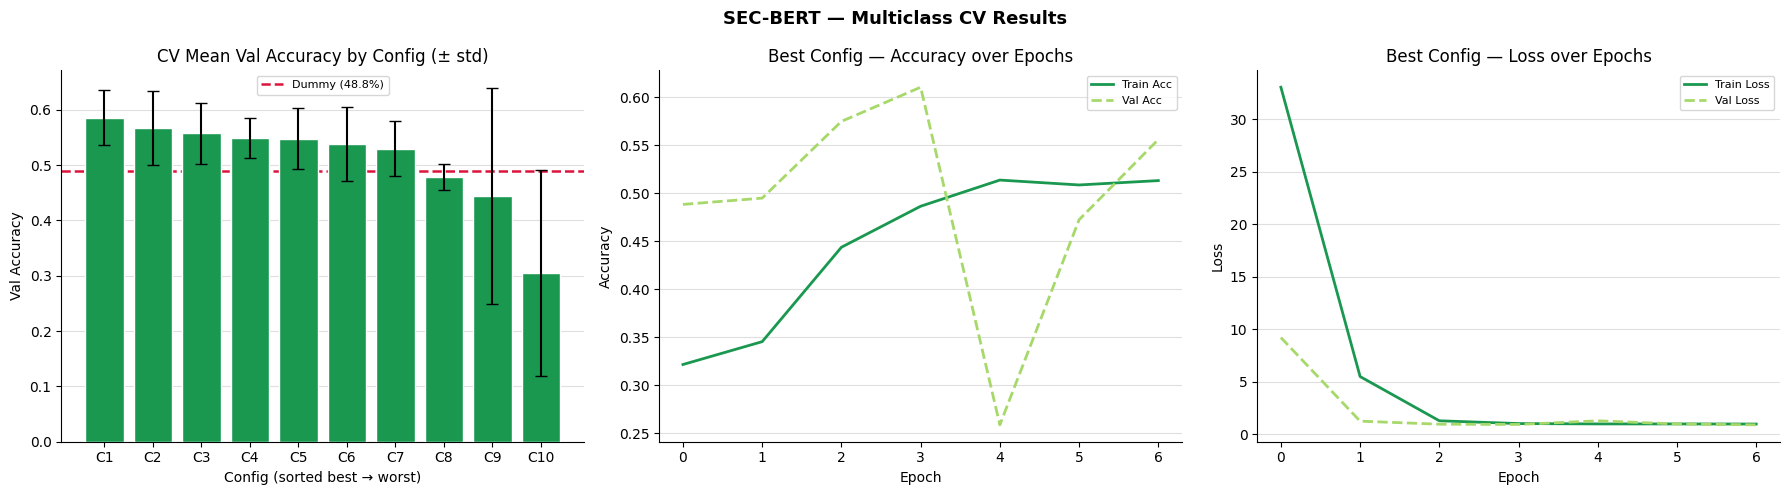

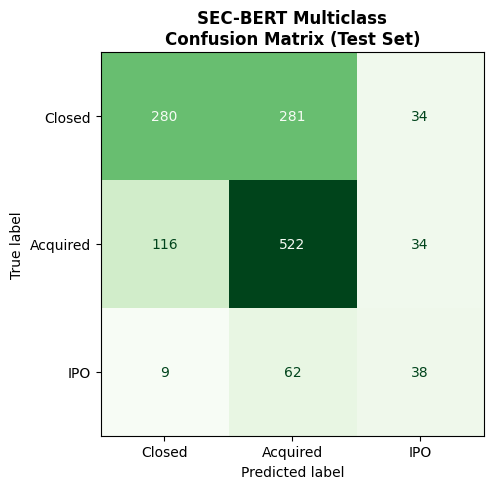

              precision    recall  f1-score   support

      Closed       0.69      0.47      0.56       595
    Acquired       0.60      0.78      0.68       672
         IPO       0.36      0.35      0.35       109

    accuracy                           0.61      1376
   macro avg       0.55      0.53      0.53      1376
weighted avg       0.62      0.61      0.60      1376


--- FinancialBERT ---


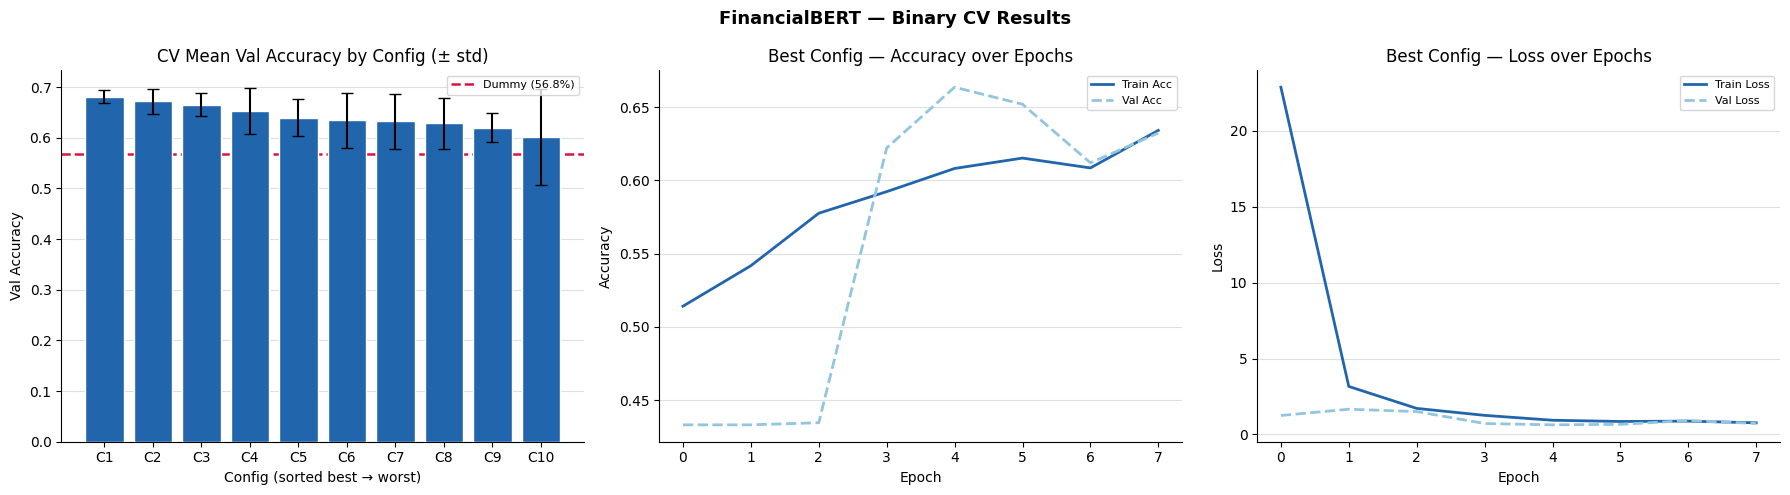

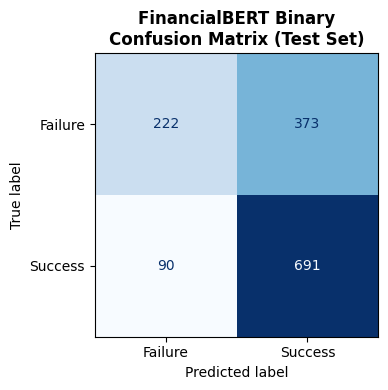

              precision    recall  f1-score   support

     Failure       0.71      0.37      0.49       595
     Success       0.65      0.88      0.75       781

    accuracy                           0.66      1376
   macro avg       0.68      0.63      0.62      1376
weighted avg       0.68      0.66      0.64      1376



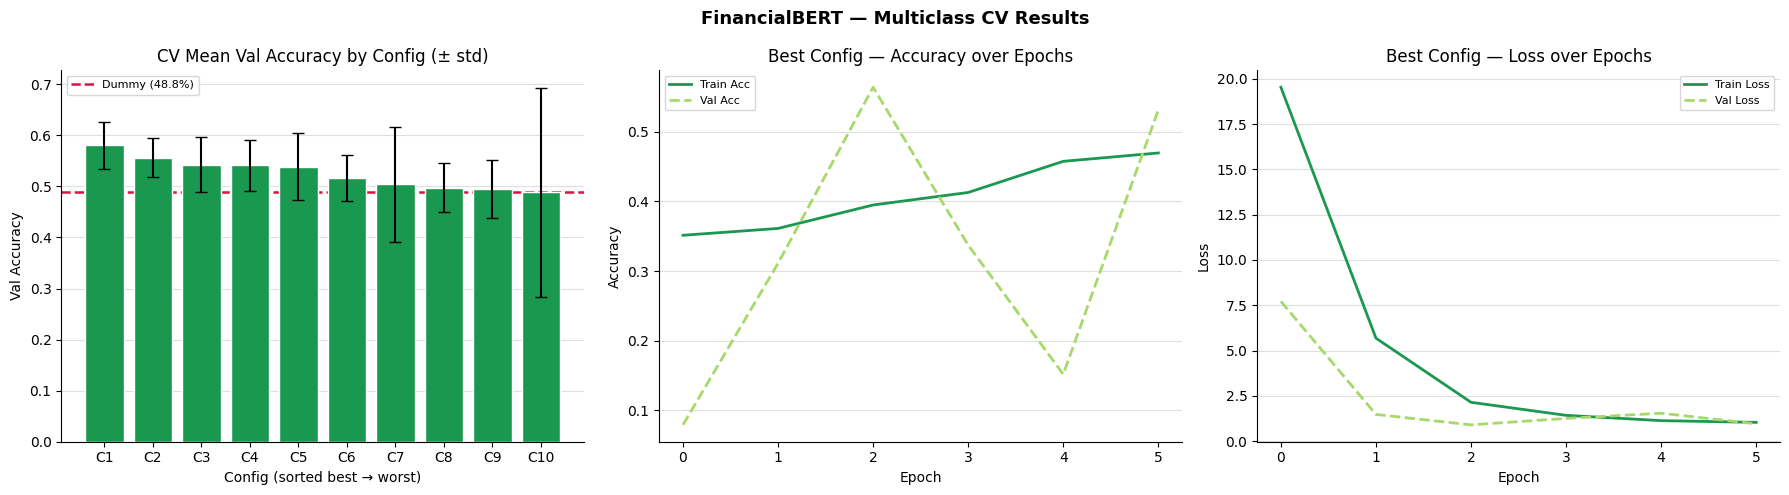

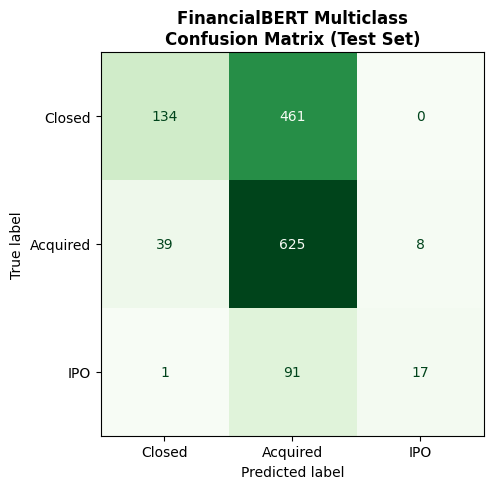

              precision    recall  f1-score   support

      Closed       0.77      0.23      0.35       595
    Acquired       0.53      0.93      0.68       672
         IPO       0.68      0.16      0.25       109

    accuracy                           0.56      1376
   macro avg       0.66      0.44      0.43      1376
weighted avg       0.65      0.56      0.50      1376



In [ ]:
#Plot charts for all models that have run.
for model_name in ALL_RESULTS:
    print(f'\n--- {model_name} ---')
    plot_results(model_name)

In [ ]:
#Print the summary table.
print_all_results()


  ALL_RESULTS SUMMARY
  Model                        Bin Acc   Bin Δ   Mul Acc   Mul Δ  Best Optimizer
  ------------------------------------------------------------------
  Random Init                   0.6904 +0.1228    0.5945 +0.1061  adamw
  Word2Vec                      0.6693 +0.1017    0.5821 +0.0937  adamw
  RoBERTa                       0.6882 +0.1206    0.6177 +0.1293  adamw
  FinBERT                       0.6555 +0.0879    0.4913 +0.0029  adamw
  SEC-BERT                      0.6904 +0.1228    0.6105 +0.1221  adamw
  FinancialBERT                 0.6635 +0.0959    0.5640 +0.0756  adamw
  ------------------------------------------------------------------
  Dummy Baseline                0.5676            0.4884


### Final Comparison Chart

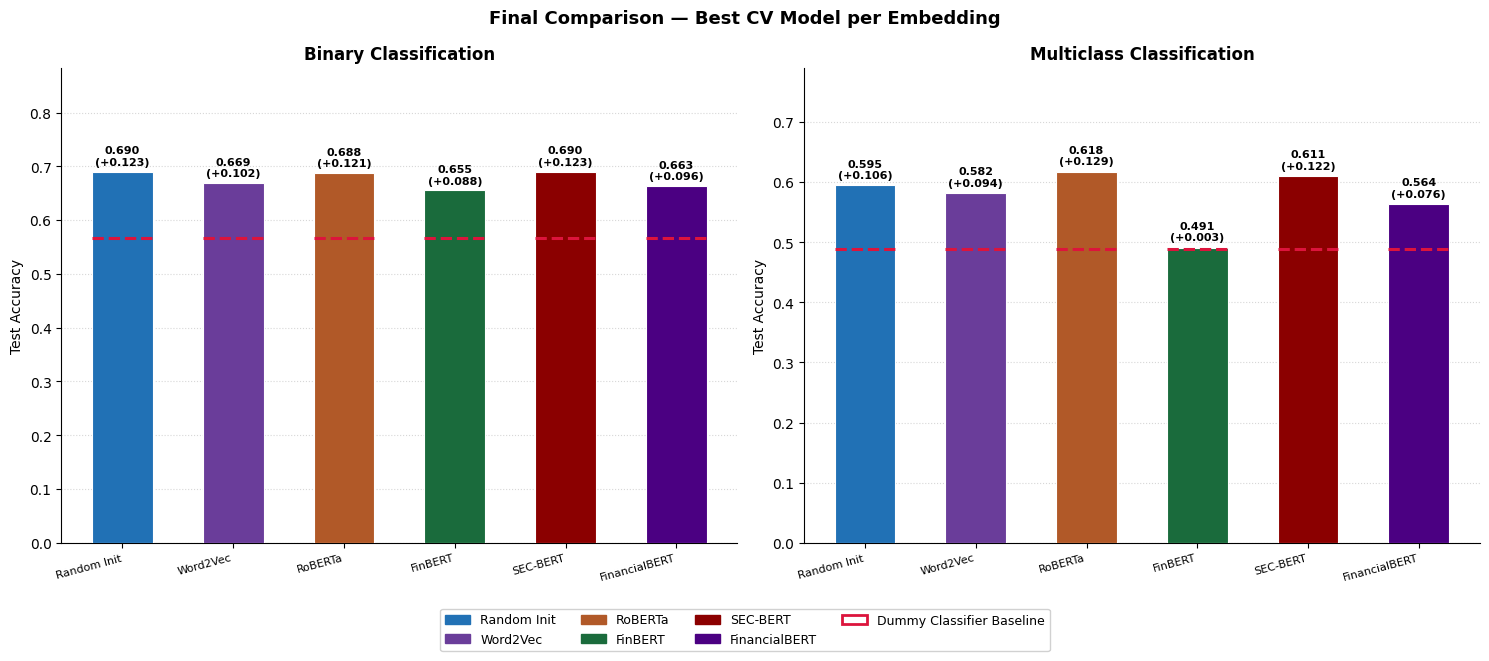


  ALL_RESULTS SUMMARY
  Model                        Bin Acc   Bin Δ   Mul Acc   Mul Δ  Best Optimizer
  ------------------------------------------------------------------
  Random Init                   0.6904 +0.1228    0.5945 +0.1061  adamw
  Word2Vec                      0.6693 +0.1017    0.5821 +0.0937  adamw
  RoBERTa                       0.6882 +0.1206    0.6177 +0.1293  adamw
  FinBERT                       0.6555 +0.0879    0.4913 +0.0029  adamw
  SEC-BERT                      0.6904 +0.1228    0.6105 +0.1221  adamw
  FinancialBERT                 0.6635 +0.0959    0.5640 +0.0756  adamw
  ------------------------------------------------------------------
  Dummy Baseline                0.5676            0.4884


In [ ]:
#Import a tool for creating colored legend boxes.
import matplotlib.patches as mpatches

#Grab the names of every model embeddings we have
#tried.
model_names = list(ALL_RESULTS.keys())

#Pull the binary and mutlcilass accuracies for
#each embedding we have tried.
binary_accs = [ALL_RESULTS[n]['binary']['test_acc']
               for n in model_names]
multi_accs  = [ALL_RESULTS[n]['multiclass']['test_acc']
               for n in model_names]

#Store the binary and multiclass dummies as float variables.
bin_dummy   = float(majority_class_proportion_cg)
mul_dummy   = float(majority_class_acc_cm)


#Define the color pallet so that
#it easier to distinguish between models.
palette = [
    '#2171B5',  # Random Init
    '#6A3D9A',  # Word2Vec
    '#B15928',  # RoBERTa
    '#1A6B3C',  # FinBERT
    '#8B0000',  # SEC-BERT
    '#4B0082',  # FinancialBERT
    '#FF7F00',  # spare
    '#1F78B4',  # spare
]

#Trim it to be the same number as
#the number of models.
colors = palette[:len(model_names)]


#Create a figure, with 2 subplots,
#one for binary and the other for
#multiclass.
fig, (ax_b, ax_m) = plt.subplots(
    1, 2,
    figsize=(max(12, len(model_names)*2.5), 6))


#Add a single title acrorss both of the subpplots.
fig.suptitle(
    'Final Comparison — Best CV Model per Embedding',
    fontsize=13, fontweight='bold')


#Function to draw each of the 2 subplots.
def draw_panel(ax, accs, dummy, labels, colors, title):

    #Set up evenly spaced bars and define their
    #width.
    x     = np.arange(len(labels))
    width = 0.55

    #Draw the actual colored bars per panel.
    bars  = ax.bar(x, accs, width, color=colors,
                  edgecolor='white', linewidth=0.8, zorder=3)

    #Draw the dummy line for each subplot
    #individually.
    for xpos in x:
        ax.plot([xpos-width/2, xpos+width/2],
                [dummy, dummy], color='crimson',
                linewidth=2.2, linestyle='--', zorder=4)

    #Add the accuracy score on top of each bar, along
    #with how much better or worse they performed
    #compared to the benchmark.
    for bar, acc in zip(bars, accs):
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.008,
                f'{acc:.3f}\n({acc-dummy:+.3f})',
                ha='center', va='bottom',
                fontsize=8, fontweight='bold')

    #Label the x-axis with the model names
    #and rotate slightly so that they do not
    #overlap.
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8,
                       rotation=15, ha='right')

    #Set the y-axis with label.
    ax.set_ylabel('Test Accuracy', fontsize=10)

    #Define the title for each subplot.
    ax.set_title(title, fontsize=12, fontweight='bold')


    #Set the y axis height to 28% above the talles bar,
    #making room for the text labels.
    ax.set_ylim(0, max(accs)*1.28)

    #Add subtle horizontal lines for a cleaner look.
    ax.yaxis.grid(True, linestyle=':', alpha=0.5, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[['top','right']].set_visible(False)

#Call the function twice, one for binary
#and the other for multiclass.
draw_panel(ax_b, binary_accs, bin_dummy,
           model_names, colors, 'Binary Classification')
draw_panel(ax_m, multi_accs,  mul_dummy,
           model_names, colors, 'Multiclass Classification')


#Create the colored legend boxes, plus another one
#for the dummy classifier.
patches = [mpatches.Patch(color=c, label=n)
           for c, n in zip(colors, model_names)]
patches.append(mpatches.Patch(
    color='crimson', fill=False, linewidth=2,
    label='Dummy Classifier Baseline'))

#Place the legends at the center of both subplots.
fig.legend(handles=patches, loc='lower center',
           ncol=min(4, len(model_names)+1),
           fontsize=9, bbox_to_anchor=(0.5,-0.10),
           framealpha=0.9)

#Tight layout so that they do not overlap
#and save the results.
plt.tight_layout()
plt.savefig('final_comparison.png',
            dpi=150, bbox_inches='tight')

#Show the graph and print all the results again.
plt.show()
print_all_results()